# TP3 Recuperatorio Grupal

**Modalidad:** grupos de 4 a 5 integrantes.

**Entrega:** notebook completo y ejecutable + corpus en `csv` o `jsonl`.

**Principio de trabajo:** un modelo puede acelerar tareas, pero no reemplaza una buena pregunta, un corpus bien construido ni el criterio humano. En analisis textual sigue valiendo la regla `garbage in, garbage out`.

### Integrantes:
* GUZMÁN, CYNTHIA
* MEALLA, DIEGO
* NAVAS, JOSE
* PENACCA, VICTORIA

## Introducción: El sentido del Análisis Computacional de Textos

Antes de ejecutar la primera línea de código, es fundamental comprender qué estamos buscando cuando aplicamos técnicas de Procesamiento de Lenguaje Natural (PLN) en las humanidades digitales y las ciencias sociales computacionales. Los algoritmos no "leen" ni "comprenden" los textos, sino que rastrean y cuantifican patrones lingüísticos. Nuestro trabajo como investigadores no es cederle la interpretación a la máquina, sino usar la computadora como una lente de aumento para volver visibles patrones discursivos.

Para que este enfoque funcione, hay tres dimensiones teórico-prácticas que debemos tener en cuenta:

### 1. El diseño del corpus: "Comparar lo comparable"

El paso analítico más importante no ocurre en el código, sino en la selección del corpus. Si comparamos textos que son inherentemente distintos, por ejemplo una novela romántica contra un manual de física, el algoritmo simplemente nos confirmará lo obvio. El verdadero poder del análisis computacional emerge cuando trabajamos sobre grandes volúmenes de textos que, en principio, parecen idénticos, comparten el mismo género, tratan sobre el mismo tema, ocurren en la misma fecha, pero difieren en una dimensión sutil, como su posición ideológica o su encuadre periodístico. El algoritmo nos permite medir matemáticamente cómo dos discursos construyen mundos diferentes a partir del mismo suceso.

### 2. La trampa del "Garbage In, Garbage Out"

Los modelos de PLN son literales. Si el corpus ingresa sucio, los resultados serán ruido. Un texto natural está lleno de "palabras vacías" (artículos, preposiciones) y verbos genéricos (ser, estar, hacer) que estadísticamente aplastan al vocabulario significativo. Del mismo modo, géneros como el periodismo incluyen vocabulario muy general del género ("nota", "gobierno", "ley") que no aporta valor analítico. El preprocesamiento de los datos, la eliminación de stopwords, la corrección de lemas, la limpieza de ruido estructural, no es una tarea técnica o automática; es una intervención interpretativa y humana crítica sin la cual el análisis resulta inútil.

### 3. Distinción algorítmica: De la frecuencia absoluta a la especificidad (TF-IDF)

Contar qué palabras se repiten más a menudo (frecuencia bruta) rara vez es revelador en grandes volúmenes de texto. La clave del análisis a escala está en encontrar el vocabulario distintivo. Técnicas estadísticas como el TF-IDF penalizan las palabras que todos usan por igual y exaltan aquellas que son exclusivas de un corpus frente a otro. Junto con el análisis de bigramas, pares de palabras que capturan locuciones o conceptos completos, estas métricas no reemplazan la lectura cualitativa: la potencian. Nos indican dónde mirar y qué palabras están funcionando como anclas ideológicas, para que luego nosotros, mediante una lectura atenta, podamos explicar el por qué.

## Qué tienen que entregar

- este notebook completo y ejecutable;
- un corpus con **12 textos**: **6 por medio**;
- un mismo tema en ambos medios;
- la columna `grupo_comparacion` con exactamente dos valores posibles;
- una comparacion entre stopwords de `spaCy` y `NLTK`;
- al menos **dos ajustes humanos** del pipeline: uno léxico y uno estructural;
- una comparacion entre `Bag of Words` y `TF-IDF`;
- una lectura de bigramas;
- al menos dos visualizaciones analíticas legibles;
- una vuelta a fragmentos concretos del corpus;
- una conclusion interpretativa y metodológica.

## Qué es un corpus

Un corpus no es una pila de textos. Un corpus es una coleccion **finita, explícita, comparable y documentada** de textos seleccionados para responder una pregunta.

Para este trabajo importa especialmente que el corpus:

- responda a una pregunta clara;
- use un criterio de inclusión visible;
- permita una comparación defendible entre dos grupos;
- conserve trazabilidad de origen;
- haga visibles sus límites.

## Columnas mínimas del corpus

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `url`
- `texto`
- `grupo_comparacion`

En la mayoria de los casos `grupo_comparacion` va a coincidir con los nombres de los dos medios elegidos.

In [1]:
# ── Librerías estándar de Python ──────────────────────────────────────────
from pathlib import Path       # Rutas de archivos: evita problemas entre Windows/Linux
from collections import Counter # Conteo de frecuencias: usado en análisis léxico

# ── Visualización ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt  # Gráficos base: barras, líneas, dispersión
import seaborn as sns             # Gráficos estadísticos sobre matplotlib

# ── Manejo de datos ───────────────────────────────────────────────────────
import pandas as pd               # Tablas (DataFrames): el formato central del corpus
from IPython.display import display  # Muestra tablas formateadas en el notebook

# ── Vectorización de texto ────────────────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# CountVectorizer → Bag of Words: cuenta cuántas veces aparece cada término
# TfidfVectorizer → TF-IDF: pondera términos según su rareza entre documentos

# ── Configuración global de gráficos ──────────────────────────────────────
# "ticks": estilo limpio sin grilla de fondo
# "colorblind": paleta accesible para personas con daltonismo
sns.set_theme(style="ticks", context="notebook", palette="colorblind")

# Ampliamos el ancho visible de las columnas textuales para no truncar títulos
pd.set_option("display.max_colwidth", 160)

print("Entorno cargado.")


Entorno cargado.


In [2]:
# ── Verificación de versiones (útil para reproducibilidad) ────────────────
import sklearn, spacy

versiones = {
    "pandas":    pd.__version__,
    "seaborn":   sns.__version__,
    "sklearn":   sklearn.__version__,
    "spacy":     spacy.__version__,
}

for lib, ver in versiones.items():
    print(f"  {lib:<12} {ver}")


  pandas       3.0.2
  seaborn      0.13.2
  sklearn      1.8.0
  spacy        3.8.13


## Hipótesis
### Pregunta de investigación:

¿Cómo construyen MIT y BBC el discurso sobre inteligencia artificial? ¿Desde qué lugar habla cada medio y qué visión de la IA le transmite a la persona que los lee?

### Hipótesis:

El discurso sobre inteligencia artificial está enfocado de manera diferente entre medios: Los artículos de MIT Technology Review presentan un discurso más técnico y especializado sobre la inteligencia artificial, centrado en modelos, datos e infraestructura tecnológica, mientras que los artículos de BBC tienden a utilizar un lenguaje más divulgativo y orientado a las aplicaciones y al impacto social de estas tecnologías. El primero transmite una visión más positiva del desarrollo implícito en el avance de la tecnología y el segundo una posición más crítica y preocupación por los impactos sociales.

## 0. Configuración

Guarden el corpus en la misma carpeta que este notebook. Si usan otro nombre o formato, cambien las variables de esta celda.

In [3]:
# ── Archivo de datos ──────────────────────────────────────────────────────
# El corpus debe estar en la misma carpeta que este notebook.
RUTA_CORPUS    = Path("corpus_tp3.csv") # Dónde busca el archivo de datos
FORMATO_CORPUS = "csv"  # opciones: "csv" o "jsonl". Cómo leer el archivo (csv o jsonl)

# ── Columnas del corpus que usa el análisis ───────────────────────────────
COLUMNA_TEXTO = "texto"             # Columna con el texto completo del artículo
COLUMNA_GRUPO = "grupo_comparacion" # Columna que separa los dos medios (MIT vs BBC)

# ── Modelo lingüístico de spaCy ───────────────────────────────────────────
# "md" incluye vectores de palabras (necesarios para similitud semántica).
# Instalar con: python -m spacy download es_core_news_md
MODELO_SPACY = "es_core_news_md" # Modelo lingüístico en español (mediano)

# ── Parámetros de visualización y extracción ──────────────────────────────
TOP_N             = 12  # Términos a mostrar en cada ranking
VENTANA_FRAGMENTO = 160 # Caracteres antes/después del término en lectura cercana

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Modelo spaCy esperado:    {MODELO_SPACY}")


Ruta esperada del corpus: corpus_tp3.csv
Modelo spaCy esperado:    es_core_news_md


In [4]:
# ── Parámetros adicionales para vectorización (sección 7) ─────────────────
TOP_N_BIGRAMAS = 10   # Bigramas a mostrar (suele ser menor que TOP_N)
MIN_DF         = 1    # Mínima frecuencia de documento para incluir un término
MAX_DF         = 0.95 # Máxima frecuencia: descarta términos en >95% de docs

# ── Parámetros de visualización ───────────────────────────────────────────
FIGURA_ANCHO = 13  # Ancho estándar de los gráficos en pulgadas
FIGURA_ALTO  = 5   # Alto estándar de los gráficos en pulgadas


## 1. Decisiones metodológicas

Agreguen una celda Markdown nueva y respondan, de manera breve, estas cuatro preguntas:

1. Qué comparan exactamente.
2. Por qué eligieron estos 12 textos y no otros.
3. Qué vuelve comparables a ambos medios.
4. Qué sesgos o límites iniciales ven en el corpus.

1. Qué comparamos exactamente.
    
    En este corpus se comparan dos conjuntos de textos periodísticos que tratan el mismo tema —la inteligencia artificial— pero que provienen de medios con perfiles editoriales diferentes. En particular, se analizan artículos publicados por MIT Technology Review y por BBC.
    La comparación busca observar cómo cada medio construye discursivamente el tema de la inteligencia artificial, es decir, qué tipo de lenguaje utiliza, qué conceptos aparecen con mayor frecuencia y qué aspectos del tema se enfatizan. 
2. Por qué eligieron estos 12 textos y no otros.

    Partimos del corpus que habían trabajado algunos miembros del equipo en su TP, reemplazamos varias notas porque eran demasiado cortas en uno de los medios, comparadas con las del otro medio y sumamos notas para alcanzar el total de 12 textos. También las reemplazamos porque ajustamos el criterio de tiempo de publicación y lo acotamos a los últimos 6 meses, y además elegimos algunas temáticas que nos parecieron las más significativas, como la solidez y uso de los datos, las distintas visiones sobre la IA, la vinculación de los modelos y la realidad, el uso de la IA, entre otras.
    Al tratarse de artículos periodísticos recientes sobre IA, los textos contienen vocabulario actual que incluyen nombres de empresas, tecnologías o aplicaciones. Esto los vuelve adecuados para aplicar técnicas básicas de PLN como tokenización, análisis de frecuencias, TF-IDF o análisis de temas, que son herramientas comunes en este tipo de trabajos.

3. Qué vuelve comparables a ambos medios.

    Lo que los vuelve comparables es que: comparten el mismo tema general, pertenecen al mismo género discursivo, se publican en contextos temporales similares, y están publicados en medios que cubren regularmente temas tecnológicos y que tienen alcance internacional.
    
4. Qué sesgos o límites iniciales ven en el corpus.

    El sesgo inicial es que nosotros elegimos las 12 notas, por lo que no podemos generalizar el análisis. Simplemente podemos dar un paneo específico de como el MIT y la BBC abordan la tematica de inteligencia artificial en los textos seleccionados y desde qué focos. 
    Otro sesgo es que las fechas no son exactamente iguales entre los dos medios, sino que fueron elegidas dentro de un periodo de tiempo determinado (6 meses), lo que puede influir en el vocabulario según los eventos de cada momento. También puede sesgar la comparación el que los dos medios parecieran tener alcances periodísticos distintos: uno especializado y uno generalista. 
    Y, aunque todos los textos tratan sobre inteligencia artificial, dentro de ese tema pueden aparecer subtemas diferentes, como: Desarrollo tecnológico, Impacto social, Regulación, Empresas tecnológicas... Si algunos subtemas aparecen más en un medio que en otro, esto puede afectar los resultados del análisis de frecuencia.
    En cuanto a los límites, el principal es que con 12 textos cualquier resultado estadístico hay que tomarlo con cuidado y no extrapolarlo más allá de este corpus puntual al ser bastante acotado.


## 2. Carga y validación del corpus

Vamos a trabajar en pasos separados. La idea es que se vea con claridad qué valida cada bloque.

In [5]:
# Este fragmento valida dos cosas antes de cargar el corpus:
# Que el archivo del corpus exista en la ruta indicada por RUTA_CORPUS.
# Que el formato declarado en FORMATO_CORPUS sea uno de los formatos aceptados: csv o jsonl.
COLUMNAS_REQUERIDAS = [
    "id",
    "fecha",
    "medio",
    "autor",
    "titulo",
    "url",
    COLUMNA_TEXTO,
    COLUMNA_GRUPO,
]

# Primero revisamos si el archivo del corpus existe antes de intentar leerlo.
# Esto evita errores posteriores más difíciles de interpretar.
archivo_existe = RUTA_CORPUS.exists()

if not archivo_existe:
    raise FileNotFoundError(
        f"No se encontro {RUTA_CORPUS}. Guardalo en esta carpeta o corregi RUTA_CORPUS."
    )

# Normalizamos el formato declarado para aceptar variantes como "CSV" o " csv ".
FORMATO_CORPUS = FORMATO_CORPUS.lower().strip()

# Despues revisamos si el formato declarado es valido.
# Validamos que el formato del corpus esté contemplado por el notebook.
formatos_validos = ["csv", "jsonl"]

if FORMATO_CORPUS not in formatos_validos:
    raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")

print("Archivo encontrado y formato declarado correctamente.")

# NOTA: Se verifica que el corpus exista y que su formato sea válido. 
# Esta validación inicial es importante porque el análisis computacional depende directamente de la calidad y disponibilidad de los datos. 
# Si el archivo no existe, está mal ubicado o tiene un formato incorrecto, cualquier resultado posterior será inválido o no reproducible.

# Adicional: Se agregan las siguientes líneas, como una forma de imprimir información básica del archivo encontrado:
print(f"Archivo encontrado: {RUTA_CORPUS}")
print(f"Formato declarado: {FORMATO_CORPUS}")
print(f"Tamaño del archivo: {RUTA_CORPUS.stat().st_size / 1024:.2f} KB")

Archivo encontrado y formato declarado correctamente.
Archivo encontrado: corpus_tp3.csv
Formato declarado: csv
Tamaño del archivo: 132.19 KB


In [6]:
# Esta celda solo carga el archivo. Todavia no valida su contenido.
if FORMATO_CORPUS == "csv":
    df = pd.read_csv(RUTA_CORPUS, sep=None, engine='python')
else:
    df = pd.read_json(RUTA_CORPUS, lines=True)

print(f"Archivo cargado: {len(df)} filas.")

Archivo cargado: 12 filas.


In [7]:
# Miramos una muestra del corpus tal como llegó del archivo.
# Se introdujo el valor de 12 para que apareciera toda la tabla del corpus.
display(df.head(12))

,﻿id,fecha,medio,autor,titulo,texto,grupo_comparacion,url
0,1,22/4/2026,mit technology review,MIT Technology Review Insights,La IA necesita un sólido tejido de datos para aportar valor empresarial,"La inteligencia artificial avanza rápidamente en el ámbito empresarial, pasando de la experimentación al uso cotidiano. Las organizaciones están desplegando...",mit,https://technologyreview.es/article/la-ia-necesita-un-solido-tejido-de-datos-para-aportar-valor-empresarial
1,2,13/4/2026,mit technology review,Will Douglas Heaven,Por qué nuestra opinión sobre la IA está tan dividida,"En una industria que no se detiene, el AI Index de Stanford, un compendio anual de resultados y tendencias clave, es una oportunidad para tomar perspectiva....",mit,https://technologyreview.es/article/por-que-la-opinion-sobre-la-ia-esta-tan-dividida
2,3,20/3/2026,mit technology review,Will Douglas Heaven,OpenAI está volcando todos sus esfuerzos en desarrollar un investigador completamente automatizado,OpenAI está reorientando sus esfuerzos de investigación y volcando sus recursos en un nuevo gran desafío. La firma de San Francisco se ha fijado el objetivo...,mit,https://technologyreview.es/article/openai-esta-volcando-todos-sus-esfuerzos-en-desarrollar-un-investigador-completamente-automatizado
3,4,10/3/2026,mit technology review,Will Douglas Heaven,Cómo Pokémon Go dota a los robots de reparto de una visión del mundo de precisión milimétrica,"Pokémon Go fue el primer gran éxito mundial de realidad aumentada. Lanzado en 2016 por Niantic, una empresa escindida de Google, el giro de RA en la mastodó...",mit,https://technologyreview.es/article/como-pokemon-go-dota-a-los-robots-de-reparto-de-una-vision-del-mundo-de-precision-milimetrica
4,5,13/2/2026,mit technology review,Redacción,Los 14 términos de IA que marcaron 2025,"1. Superinteligencia\nDesde que la gente empezó a entusiasmarse con la IA, ha ido proponiendo nombres para una forma futura y ultrapotente de esta tecnologí...",mit,https://technologyreview.es/article/104013
5,6,26/1/2026,mit technology review,Caiwei Chen,"Yann LeCun: ""Los LLM manipulan muy bien el lenguaje, pero la parte realmente difícil es entender el mundo real""","Yann LeCun es un ganador del Premio Turing y uno de los principales investigadores de inteligencia artificial, pero desde hace tiempo es una figura a la con...",mit,https://technologyreview.es/article/104229
6,7,30/4/2026,bbc.com,Melissa Hogenboom,Por qué los chatbots de IA pueden estar volviéndote más tonto,"Varios investigadores advierten que a medida que los grandes modelos de lenguaje asuman más tareas cognitivas, habrá un costo que pagar por esta externaliza...",bbc,https://www.bbc.com/mundo/articles/c5y9wnll56no
7,8,17/4/2026,bbc.com,Liv McMahon y Joe Tidy,"Mythos, el nuevo modelo de IA de Anthropic que preocupa a gobiernos y bancos por su gran potencia","En las últimas semanas, el mundo de la inteligencia artificial (IA) ha estado en ascuas tras las afirmaciones realizadas por la empresa líder Anthropic en r...",bbc,https://www.bbc.com/mundo/articles/cr71x5vgr9go
8,9,11/12/2025,bbc.com,Imran Rahman-Jones y Liv McMahon,"Quiénes son los ""arquitectos de la IA"", elegidos Persona del Año por la revista Time","La Persona del Año 2025 de la revista Time no es solo una.\nEn cambio, la publicación ha reconocido a ""los arquitectos"" de la inteligencia artificial (IA) c...",bbc,https://www.bbc.com/mundo/articles/c39p7g92v0po
9,10,24/11/2025,bbc.com,Faisal Islam,La contradicción en el corazón de la burbuja de la IA (y el temor por los efectos económicos de un posible estallido),"Sundar Pichai, el hermético CEO de Google, me invita a un recorrido por Googleplex, su sede en California.\nA lo largo del sendero que recorre todo el edifi...",bbc,https://www.bbc.com/mundo/articles/cn8v80mg9x1o


In [8]:
# Nos encontramos con un problema por un caracter oculto en la primera columna. Lo resolvimos corriendo este código. Elimina espacios en blanco y caracteres ocultos (BOM) de los nombres de las columnas
df.columns = df.columns.str.strip().str.replace('﻿', '') # El segundo es el caracter BOM oculto

In [9]:
#Comprobamos que los nombres de las columnas sean correctos y no tengan caracteres ocultos.
# Esto es importante porque un espacio oculto puede hacer que pandas no encuentre una columna.
print(df.columns.tolist())

# repr() muestra los nombres de columna de forma más literal.
# Permite detectar espacios, saltos de línea u otros caracteres invisibles.
print([repr(col) for col in df.columns])

# Eliminamos espacios al inicio y al final de los nombres de columnas.
# Por ejemplo, "texto " pasa a ser "texto".
df.columns = df.columns.str.strip()

# Se revisaron los nombres de las columnas para asegurar que el corpus pueda ser procesado correctamente. 
# Esta verificación evita errores técnicos producidos por espacios o caracteres ocultos en los encabezados del archivo. 
# La revisión de columnas forma parte de la etapa de validación del corpus, necesaria antes de aplicar técnicas de PLN.

# Esta etapa es importante porque si una columna no se reconoce, puede fallar todo el pipeline posterior:
df[COLUMNA_TEXTO]
df[COLUMNA_GRUPO]


['id', 'fecha', 'medio', 'autor', 'titulo', 'texto', 'grupo_comparacion', 'url']
["'id'", "'fecha'", "'medio'", "'autor'", "'titulo'", "'texto'", "'grupo_comparacion'", "'url'"]


0     mit
1     mit
2     mit
3     mit
4     mit
5     mit
6     bbc
7     bbc
8     bbc
9     bbc
10    bbc
11    bbc
Name: grupo_comparacion, dtype: str

In [10]:
# Ahora revisamos si estan todas las columnas obligatorias.
faltantes = []

for columna in COLUMNAS_REQUERIDAS:
    if columna not in df.columns:
        faltantes.append(columna)

if faltantes:
    mensaje = ", ".join(faltantes)
    raise ValueError("Faltan columnas obligatorias: " + mensaje)

print("Columnas obligatorias presentes.")

Columnas obligatorias presentes.


In [11]:
# Revisamos la cantidad total de textos.
cantidad_textos = len(df)

if cantidad_textos != 12:
    raise ValueError("El corpus debe tener exactamente 12 textos.")

print("Cantidad total de textos correcta: 12.")

Cantidad total de textos correcta: 12.


In [12]:
# Limpiamos la columna de grupos antes de contar.
# 'fillna' reemplaza valores vacios.
# 'astype(str)' convierte la columna a texto.
# 'str.strip()' quita espacios al principio y al final.
grupos_limpios = df[COLUMNA_GRUPO]
grupos_limpios = grupos_limpios.fillna("")
grupos_limpios = grupos_limpios.astype(str)
grupos_limpios = grupos_limpios.str.strip()

df[COLUMNA_GRUPO] = grupos_limpios

print("Columna de grupos limpiada.")

Columna de grupos limpiada.


In [13]:
# 'value_counts' cuenta cuantas veces aparece cada valor.
conteos_grupo = df[COLUMNA_GRUPO].value_counts()

grupos_unicos = []
for grupo in conteos_grupo.index.tolist():
    if grupo != "":
        grupos_unicos.append(grupo)

if len(grupos_unicos) != 2:
    raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")

conteos_ordenados = sorted(conteos_grupo.tolist())

if conteos_ordenados != [6, 6]:
    raise ValueError("Cada grupo debe tener exactamente 6 textos.")

print("Cantidad de grupos correcta.")
print("Textos por grupo:")
display(conteos_grupo)

Cantidad de grupos correcta.
Textos por grupo:


grupo_comparacion
mit    6
bbc    6
Name: count, dtype: int64

In [14]:
# Normalizamos algunas columnas para evitar problemas de espacios o valores vacios.
columnas_textuales = ["id", "medio", "autor", "titulo", "url", COLUMNA_TEXTO, COLUMNA_GRUPO]

for columna in columnas_textuales:
    df[columna] = df[columna].fillna("")
    df[columna] = df[columna].astype(str)
    df[columna] = df[columna].str.strip()

# Convertimos la fecha a un formato temporal estandar.
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

print("Columnas normalizadas.")

Columnas normalizadas.


C:\Users\vpena\AppData\Local\Temp\ipykernel_67452\757518005.py:10: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")


In [15]:
# Este patrón busca secuencias de letras de largo 2 o más.
# Nos sirve para una cuenta aproximada de palabras.
patron_palabras = r"\b[^\W\d_]{2,}\b"

coincidencias_por_texto = df[COLUMNA_TEXTO].str.findall(patron_palabras)
cantidades_palabras = coincidencias_por_texto.str.len()

df["num_palabras"] = cantidades_palabras

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:")
display(pd.Series(grupos_unicos))

columnas_mostrar = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]
display(df[columnas_mostrar])

Documentos cargados: 12
Grupos detectados:


0    mit
1    bbc
dtype: str

,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,1,2026-04-22,mit technology review,MIT Technology Review Insights,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,1397
1,2,2026-04-13,mit technology review,Will Douglas Heaven,Por qué nuestra opinión sobre la IA está tan dividida,mit,821
2,3,2026-03-20,mit technology review,Will Douglas Heaven,OpenAI está volcando todos sus esfuerzos en desarrollar un investigador completamente automatizado,mit,2412
3,4,2026-03-10,mit technology review,Will Douglas Heaven,Cómo Pokémon Go dota a los robots de reparto de una visión del mundo de precisión milimétrica,mit,1546
4,5,2026-02-13,mit technology review,Redacción,Los 14 términos de IA que marcaron 2025,mit,2253
5,6,2026-01-26,mit technology review,Caiwei Chen,"Yann LeCun: ""Los LLM manipulan muy bien el lenguaje, pero la parte realmente difícil es entender el mundo real""",mit,2561
6,7,2026-04-30,bbc.com,Melissa Hogenboom,Por qué los chatbots de IA pueden estar volviéndote más tonto,bbc,1821
7,8,2026-04-17,bbc.com,Liv McMahon y Joe Tidy,"Mythos, el nuevo modelo de IA de Anthropic que preocupa a gobiernos y bancos por su gran potencia",bbc,979
8,9,2025-12-11,bbc.com,Imran Rahman-Jones y Liv McMahon,"Quiénes son los ""arquitectos de la IA"", elegidos Persona del Año por la revista Time",bbc,846
9,10,2025-11-24,bbc.com,Faisal Islam,La contradicción en el corazón de la burbuja de la IA (y el temor por los efectos económicos de un posible estallido),bbc,2297


## 3. Auditoría del corpus

Antes de interpretar, conviene hacer una auditoría básica del recorte. En un corpus chico, los desbalances importan mucho.

,metrica,valor
0,documentos,12.0
1,palabras aproximadas,19839.0
2,promedio por texto,1653.2
3,texto mas breve,821.0
4,texto mas extenso,2561.0


,grupo_comparacion,documentos,palabras_totales,promedio_palabras,texto_mas_breve,texto_mas_extenso
0,bbc,6,8849,1474.8,846,2297
1,mit,6,10990,1831.7,821,2561


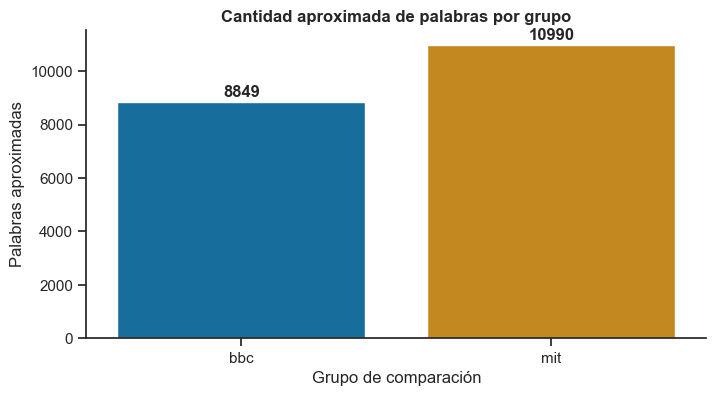

In [16]:
# Armamos una tabla breve con metricas generales del corpus.
# Este fragmento crea una tabla resumen con métricas generales del corpus:
# cantidad total de documentos / cantidad aproximada de palabras / promedio de palabras por texto.
# Es una primera descripción cuantitativa del corpus. Todavía no analiza el contenido discursivo, pero te dice el tamaño del material que estás estudiando.
metricas = ["documentos", "palabras aproximadas", "promedio por texto", "texto mas breve", "texto mas extenso"] # Crea una lista con los nombres de las métricas y una lista vacía donde se guardarán los valores.
valores = []

valores.append(len(df)) # Agrega la cantidad de filas del DataFrame.
valores.append(int(df["num_palabras"].sum())) # Suma la columna num_palabras.
valores.append(round(float(df["num_palabras"].mean()), 1)) # Calcula el promedio de palabras por texto y lo redondea a un decimal.
valores.append(int(df["num_palabras"].min())) # Nos indica la cantidad de palabras más breve por textos.
valores.append(int(df["num_palabras"].max())) # # Nos indica la cantidad de palabras más extenso por textos.


resumen_corpus = pd.DataFrame({"metrica": metricas, "valor": valores}) # Construye una tabla con dos columnas: metrica y valor.
display(resumen_corpus) # Muestra la tabla en el notebook.

# NOTA: El corpus está compuesto por 12 documentos. La cantidad total de palabras permite dimensionar el volumen textual analizado, mientras que el promedio de palabras por texto ayuda a evaluar si los documentos tienen una extensión razonablemente
# NOTA: El promedio de palabras por texto, nos indica que no se esta trabajando con textos muy breves, sino con artículos relativamente extensos.

# Para un mejor entendimiento de la información, se agrega una tabla por grupo:
resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean"),
        texto_mas_breve=("num_palabras", "min"),
        texto_mas_extenso=("num_palabras", "max")
    )
    .reset_index()
)

resumen_por_grupo["promedio_palabras"] = resumen_por_grupo["promedio_palabras"].round(1)

display(resumen_por_grupo)

# Para consolidar la información de una manera gráfica, se agrego esta grafica de barras con palabras totales por grupo.
import matplotlib.pyplot as plt
import seaborn as sns

resumen_por_grupo = (
    df.groupby(COLUMNA_GRUPO)
    .agg(
        documentos=("id", "count"),
        palabras_totales=("num_palabras", "sum"),
        promedio_palabras=("num_palabras", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=resumen_por_grupo,
    x=COLUMNA_GRUPO,
    y="palabras_totales",
    hue=COLUMNA_GRUPO,
    palette="colorblind",
    legend=False
)

plt.title("Cantidad aproximada de palabras por grupo", fontweight="bold")
plt.xlabel("Grupo de comparación")
plt.ylabel("Palabras aproximadas")

for i, fila in resumen_por_grupo.iterrows():
    plt.text(
        i,
        fila["palabras_totales"] + 200,
        int(fila["palabras_totales"]),
        ha="center",
        fontweight="bold"
    )

sns.despine()
plt.show()


In [17]:
# 'groupby' agrupa filas segun una columna.
# En este caso agrupamos por medio para comparar las dos series.
agrupado = df.groupby(COLUMNA_GRUPO)

# 'agg' sirve para resumir cada grupo con una o varias operaciones.
resumen_por_grupo = agrupado.agg(
    documentos=("id", "count"),
    palabras_totales=("num_palabras", "sum"),
    promedio_palabras=("num_palabras", "mean"),
)

# 'reset_index' devuelve el índice a una columna común.
resumen_por_grupo = resumen_por_grupo.reset_index()

# 'sort_values' ordena las filas.
resumen_por_grupo = resumen_por_grupo.sort_values(COLUMNA_GRUPO)

display(resumen_por_grupo.round(1))
# NOTA: Ambos grupos tienen la misma cantidad de documentos, lo cual cumple con la consigna del TP3. Sin embargo, el grupo MIT tiene una mayor cantidad total y promedio de palabras. 
# Por este motivo, las comparaciones basadas en frecuencia absoluta deben interpretarse con cautela, ya que MIT podría producir más ocurrencias simplemente por tener mayor volumen textual.

,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,bbc,6,8849,1474.8
1,mit,6,10990,1831.7


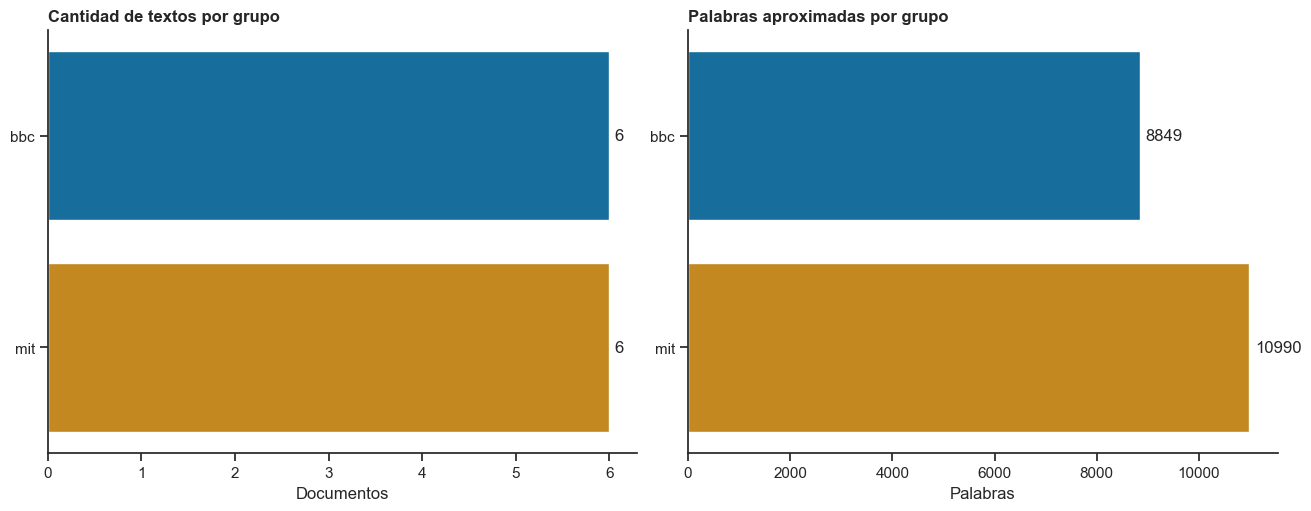

In [18]:
# Este fragmento genera dos gráficos comparativos del corpus:
# Cantidad de textos por grupo
# Cantidad aproximada de palabras por grupo
# Es una visualización de auditoría. Sirve para verificar si los grupos son equilibrados antes de avanzar al análisis lingüístico.

# Grafico 1: cantidad de textos por grupo.
# Grafico 2: cantidad aproximada de palabras por grupo.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True) # Crea una figura con dos gráficos en una misma fila.
# 1, 2: una fila, dos columnas.
# figsize=(13, 5): tamaño de la figura.
# constrained_layout=True: ajusta espacios automáticamente.

# Primer grafico: cantidad de documentos por grupo.
# Sirve para verificar si se cumple la consigna de 6 textos por grupo.
sns.barplot( # Primer gráfico: cantidad de documentos por grupo.
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    legend=False,
    ax=axes[0],
)
# Usa barras horizontales porque:
# eje X: cantidad de documentos;
# eje Y: grupo.


axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold") # Define título y etiquetas.
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")

for contenedor in axes[0].containers: # Agrega el valor numérico al final de cada barra.
    axes[0].bar_label(contenedor, fmt="%.0f", padding=4)

# Segundo grafico: cantidad aproximada de palabras por grupo.
# Sirve para detectar si un grupo tiene mayor volumen textual que otro.
sns.barplot( 
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    legend=False,
    ax=axes[1],
)

axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")

for contenedor in axes[1].containers:
    axes[1].bar_label(contenedor, fmt="%.0f", padding=4)

# Quitamos bordes superiores y derechos para una visualizacion mas limpia.
sns.despine() # Limpia bordes visuales y muestra la figura.
plt.show()

# 


Agreguen una celda Markdown nueva y anoten si ven desbalances de longitud, autoría, fechas o recorte.

### Analisis de Desbalances en el Corpus (MIT vs. BBC)

La diferencia de longitud de palabras entre los dos corpus, arrojan que los artículos del MIT son, en promedio, un 24% más largos que los de la BBC (1.832 vs. 1.475 palabras), por lo que los consideramos comparables. Pero debe tenerse en cuenta y no limitar el análisis a la frecuencia de los términos.

Los autores son variados, aunque hay algunas repeticiones dentro de cada medio. En el caso del MIT, un autor concentra el 50% de los artículos, por lo que los resultados del análisis podrían estar capturando el estilo personal de un individuo en lugar de la línea editorial del medio.

Las fechas responden al alcance propuesto: noviembre 2025 a abril 2026, aunque el rango de los artículos de MIT es de sólo 3 meses a diferencia de los 6 de la BBC. Por la rápida evolución del campo temático, podría llegar a afectar el resultado. 

## 4. Inspección con spaCy (`es_core_news_md`)

En esta parte no basta con ejecutar. Miren cómo el modelo tokeniza, lematiza, etiqueta y reconoce entidades en su corpus.

**Vocabulario de esta sección**

- **pipeline**: secuencia de operaciones que el modelo aplica al texto;
- **token**: unidad de texto separada por el modelo;
- **lema**: forma base de una palabra;
- **POS**: categoría gramatical general;
- **dependencia**: relación sintáctica entre palabras;
- **entidad**: nombre propio, organización, lugar u otra expresión relevante;
- **rasgo morfológico**: información como número, género o persona.

Modelo cargado: es_core_news_md
Pipeline activo:


0            tok2vec
1      morphologizer
2             parser
3    attribute_ruler
4         lemmatizer
5                ner
dtype: str

,componente,funcion
0,tok2vec,Representacion inicial del texto
1,morphologizer,Analisis morfologico y categoria gramatical
2,parser,Analisis de dependencias sintacticas
3,attribute_ruler,Reglas para ajustar atributos linguisticos
4,lemmatizer,Obtencion de lemas o formas base
5,ner,Reconocimiento de entidades nombradas


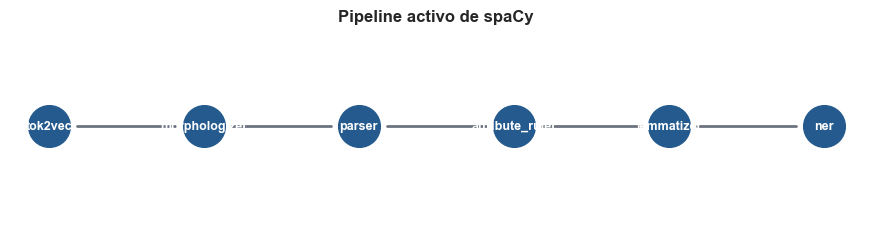

In [19]:
# Este fragmento carga el modelo de spaCy que vas a usar para procesar el corpus.

# Cargamos spaCy y el modelo de español definido en MODELO_SPACY.
# Este modelo permite tokenizar, lematizar, etiquetar gramaticalmente y detectar entidades.
try:
    import spacy
    from spacy.matcher import Matcher
    nlp = spacy.load(MODELO_SPACY)
except Exception as error: # Si spaCy o el modelo no estan disponibles, detenemos la ejecucion con un mensaje claro.
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalen el modelo con: python -m spacy download es_core_news_md"
    ) from error

# Ajustamos algunas stopwords que pueden resultar utiles en corpus en espanol.
# # Ajustamos manualmente algunas stopwords.
# Esto es parte del criterio humano del preprocesamiento: no todas las listas base son perfectas.
nlp.vocab["él"].is_stop = True
nlp.vocab["ella"].is_stop = True

# Mostramos el modelo cargado y los componentes activos del pipeline.
# Esto ayuda a saber que tareas lingüísticas podrá realizar spaCy.
print(f"Modelo cargado: {MODELO_SPACY}")
print("Pipeline activo:")
display(pd.Series(nlp.pipe_names))

# Se utilizó spaCy con un modelo de español para realizar el procesamiento lingüístico del corpus. 
# El pipeline permite obtener tokens, lemas, categorías gramaticales, dependencias sintácticas y entidades nombradas. 
# Estos elementos son necesarios para transformar los textos en unidades analizables y preparar el corpus para las etapas posteriores de vectorización y comparación.
# Además, se realizaron pequeños ajustes manuales sobre la lista de stopwords del modelo.
# Esto muestra que el preprocesamiento no es una tarea completamente automática, sino una decisión metodológica que debe adaptarse al corpus.

# Adicional se muestra una tabla con los componentes del pipeline y para qué sirven.
componentes_pipeline = pd.DataFrame({
    "componente": nlp.pipe_names,
    "funcion": [
        "Representacion inicial del texto" if nombre == "tok2vec" else
        "Analisis morfologico y categoria gramatical" if nombre == "morphologizer" else
        "Analisis de dependencias sintacticas" if nombre == "parser" else
        "Reglas para ajustar atributos linguisticos" if nombre == "attribute_ruler" else
        "Obtencion de lemas o formas base" if nombre == "lemmatizer" else
        "Reconocimiento de entidades nombradas" if nombre == "ner" else
        "Otro componente del pipeline"
        for nombre in nlp.pipe_names
    ]
})

display(componentes_pipeline)

# De igual manera, se hace una visualización simple del pipeline como diagrama horizontal.
import matplotlib.pyplot as plt

componentes = nlp.pipe_names

plt.figure(figsize=(11, 2.5))

for i, componente in enumerate(componentes):
    plt.scatter(i, 0, s=900, color="#245a8d")
    plt.text(
        i,
        0,
        componente,
        color="white",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

    if i < len(componentes) - 1:
        plt.plot([i + 0.18, i + 0.82], [0, 0], color="#6b7280", linewidth=2)

plt.title("Pipeline activo de spaCy", fontweight="bold")
plt.axis("off")
plt.show()

# El diagrama muestra la secuencia de componentes que spaCy aplica al texto. 
# Cada componente agrega una capa de información lingüística. Primero se genera una representación del texto, luego se analizan rasgos gramaticales y sintácticos, se obtienen lemas y finalmente se detectan entidades nombradas. 
# Esta secuencia permite pasar del texto crudo a una representación lingüística estructurada.

Documentos procesados con spaCy: 12
Documentos procesados con spaCy: 12


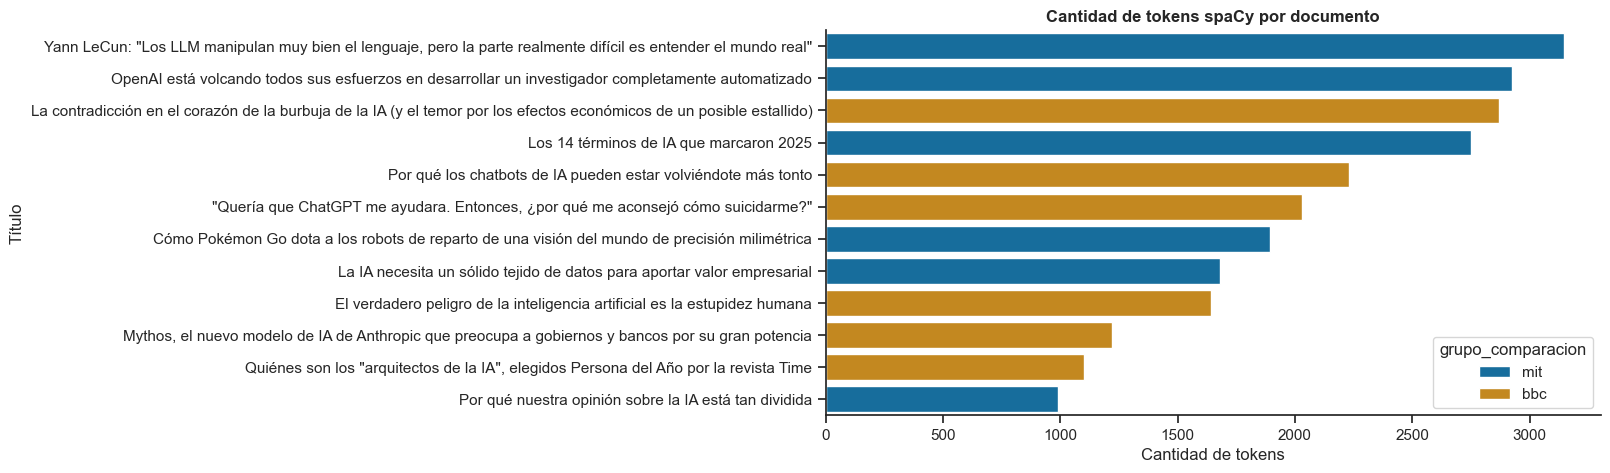

In [20]:
# 'pipe' procesa muchos textos de una vez.
# Lo usamos porque todo el corpus pasa por el mismo pipeline.
# Este fragmento procesa todos los textos del corpus con spaCy. 
# Convierte cada texto crudo en un objeto Doc, que contiene información lingüística estructurada: tokens; lemas; categorías gramaticales; dependencias; entidades; oraciones; stopwords; puntuación; rasgos morfológicos.
# Después de esta celda, ya podés hacer análisis lingüístico sobre todo el corpus.

# Extraemos los textos del corpus como una lista.
# Cada elemento de la lista corresponde a un documento/articulo.
textos_corpus = df[COLUMNA_TEXTO].tolist()

# Procesamos todos los textos con nlp.pipe().
# Esta opcion es mas eficiente que aplicar nlp(texto) documento por documento.
# El resultado es una lista de objetos Doc con informacion lingüistica estructurada.
docs_base = list(nlp.pipe(textos_corpus))

# Verificamos cuantos documentos fueron procesados.
# En este TP3 esperamos que coincida con la cantidad de filas del DataFrame.
print(f"Documentos procesados con spaCy: {len(docs_base)}")
textos_corpus = df[COLUMNA_TEXTO].tolist()
docs_base = list(nlp.pipe(textos_corpus))

print(f"Documentos procesados con spaCy: {len(docs_base)}")

# En esta etapa, los textos del corpus fueron procesados con el pipeline de spaCy. 
# Esto permite transformar el texto crudo en una estructura lingüística rica, donde cada documento contiene tokens, lemas, categorías gramaticales, dependencias sintácticas y entidades nombradas. 
# A partir de este procesamiento se pueden realizar análisis más específicos sobre vocabulario, actores, acciones y patrones gramaticales.

# Después de procesar con spaCy, ya podés hacer un gráfico útil: cantidad de tokens por documento.
# Esto te permite comparar la extensión según spaCy, no solo según split().
df["num_tokens_spacy"] = [len(doc) for doc in docs_base]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df.sort_values("num_tokens_spacy", ascending=False),
    x="num_tokens_spacy",
    y="titulo",
    hue=COLUMNA_GRUPO,
    palette="colorblind"
)

plt.title("Cantidad de tokens spaCy por documento", fontweight="bold")
plt.xlabel("Cantidad de tokens")
plt.ylabel("Título")

sns.despine()
plt.show()

# El gráfico muestra la cantidad de tokens identificados por spaCy en cada documento. 
# Esto permite observar diferencias de extensión entre textos y detectar si algún artículo puede tener mayor peso en los análisis posteriores por ser más largo. 
# La cantidad de tokens puede diferir de la cantidad de palabras aproximadas porque spaCy separa puntuación, signos y algunas expresiones de manera específica.


,token,lemma,pos,tag,dep,ent,morph
0,La,el,DET,DET,det,-,Definite=Def|Gender=Fem|Number=Sing|PronType=Art
1,inteligencia,inteligencia,NOUN,NOUN,nsubj,-,Gender=Fem|Number=Sing
2,artificial,artificial,ADJ,ADJ,amod,-,Number=Sing
3,avanza,avanzar,VERB,VERB,ROOT,-,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin
4,rápidamente,rápidamente,ADV,ADV,advmod,-,-
5,en,en,ADP,ADP,case,-,-
6,el,el,DET,DET,det,-,Definite=Def|Gender=Masc|Number=Sing|PronType=Art
7,ámbito,ámbito,NOUN,NOUN,obl,-,Gender=Masc|Number=Sing
8,empresarial,empresarial,ADJ,ADJ,amod,-,Number=Sing
9,",",",",PUNCT,PUNCT,punct,-,PunctType=Comm


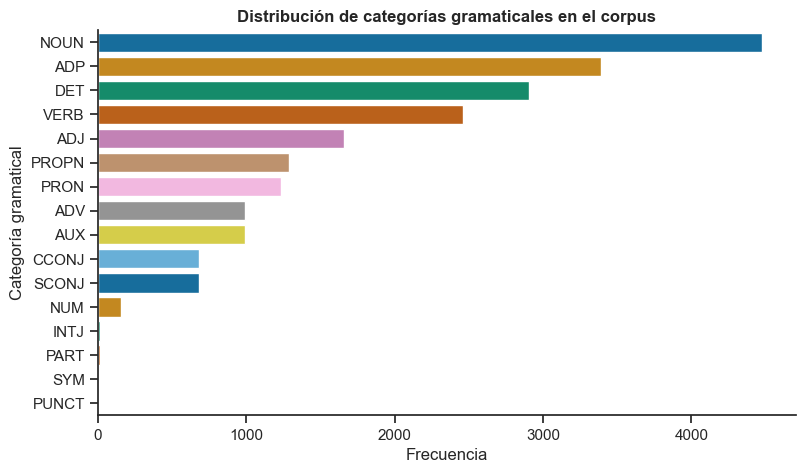

In [21]:
# Este fragmento inspecciona cómo spaCy analiza un fragmento del corpus.
# Toma los primeros 350 caracteres del primer texto y genera una tabla con información lingüística token por token:
# token original; lema; categoría gramatical; etiqueta morfosintáctica; dependencia sintáctica; entidad; rasgos morfológicos.
# Es una celda de auditoría del pipeline. Sirve para no confiar ciegamente en el modelo.
def normalizar_lemma(token): # Define una función para obtener el lema en minúscula y sin espacios.
    # 'lemma_' es la forma base de una palabra segun el modelo.
    lema = token.lemma_.strip().lower() # Define una función para obtener el lema en minúscula y sin espacios.

    # A veces spaCy devuelve un lema vacio o '-PRON-'.
    # En esos casos usamos la forma original en minuscula.
    if not lema or lema == "-pron-": # Si spaCy devuelve un lema vacío o -PRON-, usa el texto original del token. Esto evita que queden valores poco útiles.
        lema = token.text.lower()

    return lema

texto_muestra = df.loc[0, COLUMNA_TEXTO] # Toma el primer texto del corpus, corta sus primeros 350 caracteres y lo procesa con spaCy.
fragmento = texto_muestra[:350]
doc_fragmento = nlp(fragmento)

registros_tokens = []

for indice, token in enumerate(doc_fragmento): # Recorre solo los primeros 25 tokens para que la tabla no sea demasiado larga.
    if indice >= 25:
        break

    if token.is_space: # Ignora espacios.
        continue

    # 'pos_' es la categoria gramatical general.
    # 'tag_' es una etiqueta mas especifica.
    # 'dep_' muestra la relacion sintactica.
    # 'morph' guarda rasgos como numero, genero o persona.
    registro_token = { # Guarda la información lingüística de cada token en un diccionario.
        "token": token.text,
        "lemma": normalizar_lemma(token),
        "pos": token.pos_,
        "tag": token.tag_,
        "dep": token.dep_,
        "ent": token.ent_type_ if token.ent_type_ else "-",
        "morph": str(token.morph) if str(token.morph) else "-",
    }
    registros_tokens.append(registro_token)

tabla_tokens = pd.DataFrame(registros_tokens) # Convierte la lista de registros en una tabla.
display(tabla_tokens)

# La inspección manual de tokens permite evaluar la calidad del procesamiento lingüístico antes de aplicar conteos o vectorización. 
# Esta etapa es importante porque errores en la tokenización o lematización pueden trasladarse a las métricas posteriores. 
# En particular, se revisan lemas, categorías gramaticales, dependencias y entidades para decidir si será necesario realizar ajustes manuales.

# Para esta sección, el gráfico más útil es la distribución de categorías gramaticales POS en el fragmento o en todo el corpus
from collections import Counter

conteo_pos = Counter()

for doc in docs_base:
    for token in doc:
        if token.is_space or token.is_punct:
            continue
        conteo_pos[token.pos_] += 1

tabla_pos = pd.DataFrame(
    conteo_pos.most_common(),
    columns=["pos", "frecuencia"]
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=tabla_pos,
    x="frecuencia",
    y="pos",
    hue="pos",
    palette="colorblind",
    legend=False
)

plt.title("Distribución de categorías gramaticales en el corpus", fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("Categoría gramatical")

sns.despine()
plt.show()

# En este gráfico, la distribución de categorías gramaticales permite observar qué tipos de unidades predominan en el corpus. 
# Una alta frecuencia de sustantivos puede indicar concentración temática en objetos, conceptos o actores; una mayor presencia de verbos puede orientar el análisis hacia acciones y procesos; 
# los nombres propios permiten explorar actores relevantes mediante entidades nombradas.

Total tokens: 20768

Top 10 palabras más frecuentes:
de                   -> 1383
que                  -> 777
la                   -> 695
en                   -> 593
y                    -> 453
a                    -> 424
el                   -> 391
los                  -> 368
un                   -> 281
una                  -> 223
Las 10 palabras mas frecuentes representan el 26.9% de los tokens alfabeticos.


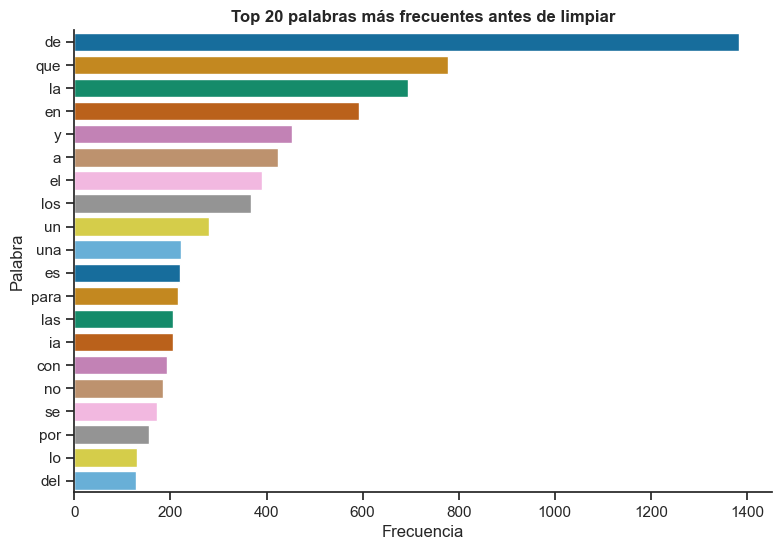

In [22]:
# Este fragmento hace un primer conteo de palabras del corpus usando los tokens procesados por spaCy.
# Cuenta las palabras más frecuentes, conservando solo tokens alfabéticos y pasando todo a minúscula.
# Es una exploración inicial del vocabulario, antes de eliminar stopwords o lematizar.

from collections import Counter

# Pasar todo a minúscula y conservar solo tokens que contengan letras

# Creamos una lista de tokens por documento.
# Usamos token.text.lower() para unificar palabras con mayusculas y minusculas.
# Usamos token.is_alpha para conservar solo palabras y descartar puntuacion, numeros o simbolos.
tokens_a = [
    [
        token.text.lower()
        for token in doc
        if token.is_alpha
    ]
    for doc in docs_base
]

# Aplanamos la lista 
# Asi pasamos de una estructura por documento a una lista unica de palabras del corpus.
todos_tokens_a = [token for doc in tokens_a for token in doc]

print
print(f"Total tokens: {len(todos_tokens_a)}")

# Counter cuenta cuantas veces aparece cada palabra.
# Este primer conteo todavia incluye stopwords, por eso sirve como diagnostico inicial.
freq_a = Counter(todos_tokens_a)

print("\nTop 10 palabras más frecuentes:")
for palabra, cuenta in freq_a.most_common(10):
    print(f"{palabra:20} -> {cuenta}")

    # NOTA: Este conteo muestra qué palabras dominan el corpus antes de aplicar limpieza.
    # El primer conteo de frecuencia muestra que las palabras más repetidas corresponden principalmente a artículos, preposiciones y conectores. 
    # Estas palabras son necesarias para la estructura del español, pero aportan poco para diferenciar los enfoques discursivos de cada medio. 
    # Por eso, en las etapas siguientes se aplicará filtrado de stopwords y lematización.
    # Este resultado evidencia que la frecuencia bruta, sin preprocesamiento, no es suficiente para el análisis discursivo.

# Para calcular qué porcentaje del corpus ocupan las 10 palabras más frecuentes
total_tokens = len(todos_tokens_a)
top_10_total = sum(cuenta for palabra, cuenta in freq_a.most_common(10))
porcentaje_top_10 = top_10_total / total_tokens * 100

print(f"Las 10 palabras mas frecuentes representan el {porcentaje_top_10:.1f}% de los tokens alfabeticos.")

# Permite graficar el top 20 de palabras más frecuentes antes de limpiar.
top_frecuencias_a = pd.DataFrame(
    freq_a.most_common(20),
    columns=["palabra", "frecuencia"]
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_frecuencias_a,
    x="frecuencia",
    y="palabra",
    hue="palabra",
    palette="colorblind",
    legend=False
)

plt.title("Top 20 palabras más frecuentes antes de limpiar", fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")

sns.despine()
plt.show()

# El gráfico muestra que, antes del preprocesamiento, las palabras más frecuentes son mayoritariamente términos funcionales del idioma. 
# Esto confirma la necesidad de aplicar stopwords para reducir ruido y permitir que emerjan términos con mayor valor analítico.

In [23]:
# 'pipe' procesa muchos textos de una vez.
# Lo usamos porque todo el corpus pasa por el mismo pipeline.
textos_corpus = df[COLUMNA_TEXTO].tolist()
docs_base = list(nlp.pipe(textos_corpus))

print(f"Documentos procesados con spaCy: {len(docs_base)}")

Documentos procesados con spaCy: 12


Top 10 palabras:
modelo -> 94
empresa -> 81
sistema -> 78
dato -> 76
mundo -> 70
openai -> 54
año -> 53
persona -> 49
afirmar -> 48
utilizar -> 47


,termino,frecuencia
0,modelo,94
1,empresa,81
2,sistema,78
3,dato,76
4,mundo,70
5,openai,54
6,año,53
7,persona,49
8,afirmar,48
9,utilizar,47


Tokens antes de limpiar: 20768
Tokens despues de limpiar: 8982
Reduccion aproximada: 56.8%


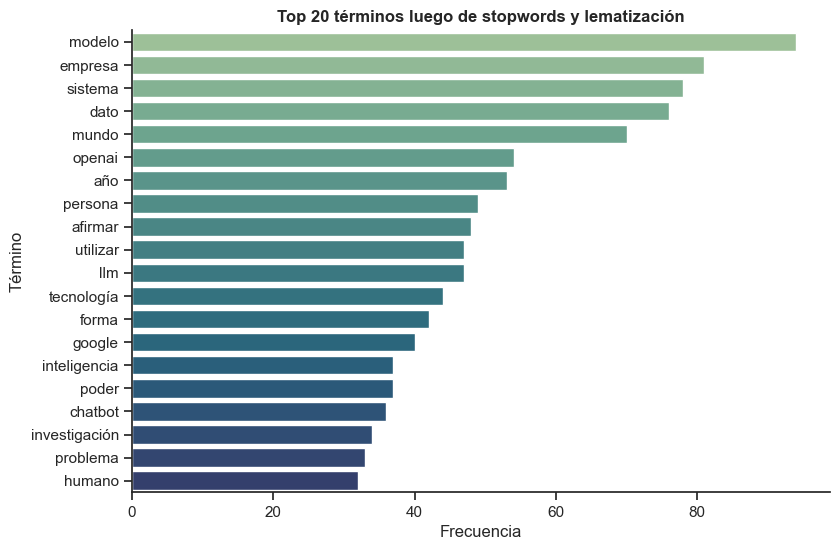

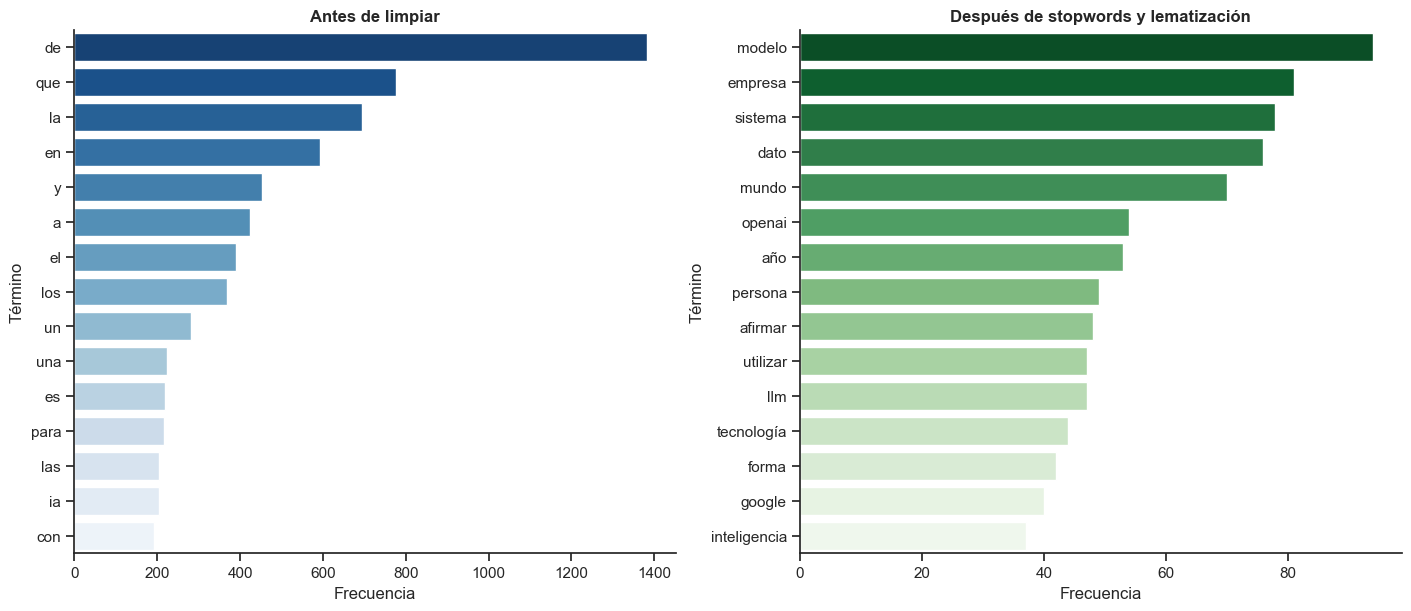

In [24]:

# Este fragmento repite el conteo de palabras, pero ahora con dos mejoras importantes:
# 1. elimina stopwords;
# 2. usa lemas en lugar de formas originales.
# Es decir, ya no cuenta simplemente palabras como aparecen en el texto, sino formas más limpias y analíticamente útiles.
from collections import Counter

# Aplicamos stopwords para eliminar articulos a todo el corpus
# Aplicamos stopwords y lematizacion para obtener vocabulario mas informativo.
# Aplicamos un primer preprocesamiento lingüístico:
# 1. conservamos solo tokens alfabéticos;
# 2. eliminamos stopwords;
# 3. usamos lemas para agrupar variantes de una misma palabra.
tokens_limpios = [
    [
        token.lemma_.lower()
        # normalizar_lemma(token) # Tambien se podría utilizar esta función, para trabajar con los lemas.
        for token in doc
        if token.is_alpha and not token.is_stop
        and len(normalizar_lemma(token)) > 2 # Se agrega un filtro de longitud para evitar restos poco informativos:
    ]
    for doc in docs_base
]

# Aplanamos la lista de listas para contar los lemas de todo el corpus.
todos_tokens = [token for doc in tokens_limpios for token in doc]

# Contamos la frecuencia absoluta de cada lema.
freq = Counter(todos_tokens)

# Mostramos los terminos mas frecuentes luego de la limpieza.
print("Top 10 palabras:")
for palabra, cuenta in freq.most_common(10):
    print(palabra, "->", cuenta)

# Luego de eliminar stopwords y aplicar lematización, aparecen términos más vinculados al contenido temático del corpus. 
# Esto permite pasar de una frecuencia dominada por palabras funcionales del idioma a una frecuencia más representativa de los conceptos centrales tratados en los textos.
# La diferencia entre el conteo inicial y el conteo limpio muestra el impacto del preprocesamiento. Sin limpieza, predominan artículos y conectores; 
# después de aplicar stopwords y lemas, emergen términos relacionados con inteligencia artificial, empresas, modelos, riesgos y actores tecnológicos.
# Este conteo sigue siendo global. Todavía no diferencia entre MIT y BBC.

# Se creó un DataFrame con el top de frecuencias:
top_frecuencias_limpias = pd.DataFrame(
    freq.most_common(20),
    columns=["termino", "frecuencia"]
)

display(top_frecuencias_limpias)

# Para explicar el efecto de las stopwords, se agregaron estas lineas para calcular cuántos tokens se eliminaron con el preprocesamiento:
tokens_antes = sum(len(doc) for doc in tokens_a)
tokens_despues = len(todos_tokens)

reduccion = (1 - tokens_despues / tokens_antes) * 100

print(f"Tokens antes de limpiar: {tokens_antes}")
print(f"Tokens despues de limpiar: {tokens_despues}")
print(f"Reduccion aproximada: {reduccion:.1f}%")

# Gráfico del top 20 después de limpiar:
top_frecuencias_limpias = pd.DataFrame(
    freq.most_common(20),
    columns=["termino", "frecuencia"]
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_frecuencias_limpias,
    x="frecuencia",
    y="termino",
    hue="termino",
    palette="crest",
    legend=False
)

plt.title("Top 20 términos luego de stopwords y lematización", fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("Término")

sns.despine()
plt.show()

# El gráfico muestra los términos más frecuentes después del preprocesamiento. A diferencia del conteo inicial, aquí aparecen palabras con mayor valor temático. 
# Esto permite identificar los conceptos dominantes del corpus completo, aunque todavía no permite distinguir qué términos caracterizan a cada grupo.

# Gráfico Comparativo Antes/Después. Como ya se tiene freq_a del paso anterior, se podrá comparar antes y después:
top_antes = pd.DataFrame(
    freq_a.most_common(15),
    columns=["termino", "frecuencia"]
)

top_despues = pd.DataFrame(
    freq.most_common(15),
    columns=["termino", "frecuencia"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

sns.barplot(
    data=top_antes,
    x="frecuencia",
    y="termino",
    hue="termino",
    palette="Blues_r",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Antes de limpiar", fontweight="bold")
axes[0].set_xlabel("Frecuencia")
axes[0].set_ylabel("Término")

sns.barplot(
    data=top_despues,
    x="frecuencia",
    y="termino",
    hue="termino",
    palette="Greens_r",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Después de stopwords y lematización", fontweight="bold")
axes[1].set_xlabel("Frecuencia")
axes[1].set_ylabel("Término")

sns.despine()
plt.show()

# La comparación antes/después permite observar cómo el preprocesamiento transforma la lectura del corpus. 
# En la versión original predominan palabras funcionales del español, mientras que después de eliminar stopwords y lematizar aparecen términos más vinculados al tema investigado. 
# Esto justifica metodológicamente la limpieza previa a la vectorización y al análisis comparativo.


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


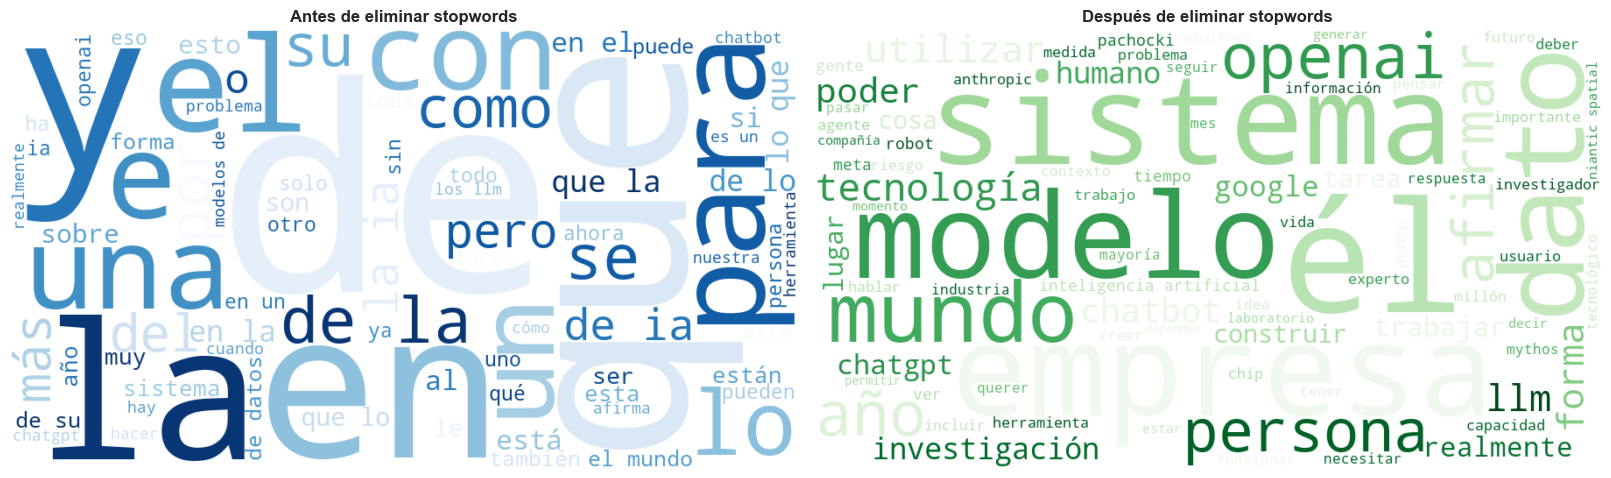

In [25]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Texto antes de eliminar stopwords.
# Usamos todos los tokens alfabeticos del corpus.
texto_antes = " ".join(todos_tokens_a)

# Texto despues de eliminar stopwords.
# Usamos los tokens limpios ya generados.
texto_despues = " ".join(todos_tokens)

wordcloud_antes = WordCloud(
    width=900,
    height=500,
    background_color="white",
    colormap="Blues",
    max_words=80
).generate(texto_antes)

wordcloud_despues = WordCloud(
    width=900,
    height=500,
    background_color="white",
    colormap="Greens",
    max_words=80
).generate(texto_despues)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

axes[0].imshow(wordcloud_antes, interpolation="bilinear")
axes[0].set_title("Antes de eliminar stopwords", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(wordcloud_despues, interpolation="bilinear")
axes[1].set_title("Después de eliminar stopwords", fontweight="bold")
axes[1].axis("off")

plt.show()


,token,lemma,pos,tag,dep,ent,morph
0,inteligencia,inteligencia,NOUN,NOUN,nsubj,-,Gender=Fem|Number=Sing
1,artificial,artificial,ADJ,ADJ,amod,-,Number=Sing
2,avanza,avanzar,VERB,VERB,ROOT,-,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin
3,rápidamente,rápidamente,ADV,ADV,advmod,-,-
4,ámbito,ámbito,NOUN,NOUN,obl,-,Gender=Masc|Number=Sing
5,empresarial,empresarial,ADJ,ADJ,amod,-,Number=Sing
6,pasando,pasar,VERB,VERB,advcl,-,VerbForm=Ger
7,experimentación,experimentación,NOUN,NOUN,obj,-,Gender=Fem|Number=Sing
8,cotidiano,cotidiano,ADJ,ADJ,amod,-,Gender=Masc|Number=Sing
9,organizaciones,organización,NOUN,NOUN,nsubj,MISC,Gender=Fem|Number=Plur


,token,lemma,pos,tag,dep,ent,morph,categoria_analitica
0,inteligencia,inteligencia,NOUN,NOUN,nsubj,-,Gender=Fem|Number=Sing,concepto
1,artificial,artificial,ADJ,ADJ,amod,-,Number=Sing,atributo/valoracion
2,avanza,avanzar,VERB,VERB,ROOT,-,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin,accion
3,rápidamente,rápidamente,ADV,ADV,advmod,-,-,otra
4,ámbito,ámbito,NOUN,NOUN,obl,-,Gender=Masc|Number=Sing,concepto
5,empresarial,empresarial,ADJ,ADJ,amod,-,Number=Sing,atributo/valoracion
6,pasando,pasar,VERB,VERB,advcl,-,VerbForm=Ger,accion
7,experimentación,experimentación,NOUN,NOUN,obj,-,Gender=Fem|Number=Sing,concepto
8,cotidiano,cotidiano,ADJ,ADJ,amod,-,Gender=Masc|Number=Sing,atributo/valoracion
9,organizaciones,organización,NOUN,NOUN,nsubj,MISC,Gender=Fem|Number=Plur,concepto


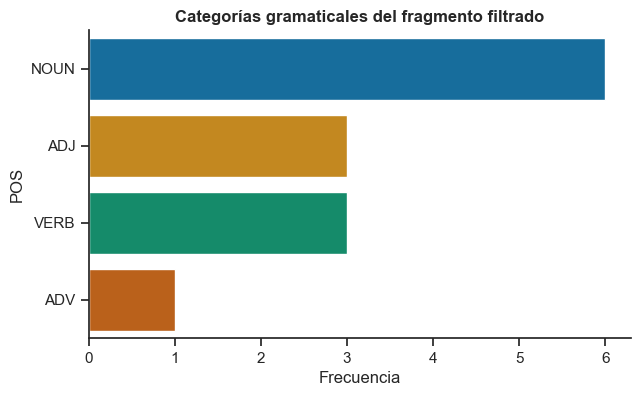

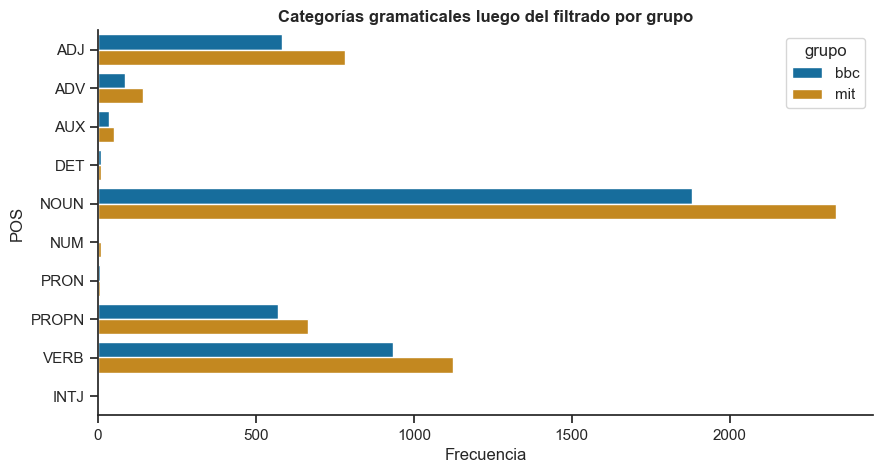

In [26]:
# Este fragmento vuelve a inspeccionar tokens de un fragmento, pero ahora muestra solo tokens “útiles” para el análisis:
# 1. elimina espacios;
# 2. elimina puntuación;
# 3. conserva solo palabras alfabéticas;
# 4. elimina stopwords;
# 5. muestra lemas, POS, dependencias, entidades y morfología.
# Es decir, ya no audita el texto completo token por token, sino la versión lingüísticamente filtrada que después se usará para conteos y vectorización.

def normalizar_lemma(token): # Obtiene el lema en minúscula.
    # 'lemma_' es la forma base de una palabra segun el modelo.
    lema = token.lemma_.strip().lower()

    # A veces spaCy devuelve un lema vacio o '-PRON-'.
    # En esos casos usamos la forma original en minuscula.
    if not lema or lema == "-pron-":
        lema = token.text.lower()

    return lema


# Tomamos un texto de ejemplo
texto_muestra = df.loc[0, COLUMNA_TEXTO] # Toma un fragmento del primer texto y lo procesa con spaCy.
fragmento = texto_muestra[:350]
doc_fragmento = nlp(fragmento)

registros_tokens = []

for indice, token in enumerate(doc_fragmento): # Recorre los primeros 25 tokens del fragmento.
    if indice >= 25:
        break

    # ❌ ignoramos espacios, puntuación y stopwords
    if token.is_space or not token.is_alpha or token.is_stop: # Filtra elementos poco útiles: espacios; puntuación o símbolos; stopwords.
        continue

    registro_token = { # Guarda atributos lingüísticos del token.
        "token": token.text,
        "lemma": normalizar_lemma(token),
        "pos": token.pos_,
        "tag": token.tag_,
        "dep": token.dep_,
        "ent": token.ent_type_ if token.ent_type_ else "-",
        "morph": str(token.morph) if str(token.morph) else "-",
    }

    registros_tokens.append(registro_token)

tabla_tokens = pd.DataFrame(registros_tokens) # Muestra la tabla.
display(tabla_tokens)

# Esta inspección permite observar el efecto del preprocesamiento sobre un fragmento concreto del corpus. 
# Al eliminar stopwords, puntuación y elementos no alfabéticos, quedan unidades con mayor carga semántica. 
# La tabla permite revisar si esos tokens conservados son adecuados para el análisis posterior y si los lemas generados por spaCy resultan interpretables.

# La primera inspección sirve para auditar el pipeline completo; esta segunda inspección permite evaluar específicamente el resultado de las decisiones de limpieza.

# Agregar una columna que indique si el token es nombre propio, sustantivo, verbo o adjetivo, porque esas categorías suelen ser las más útiles para análisis discursivo.
tabla_tokens["categoria_analitica"] = tabla_tokens["pos"].map({
    "PROPN": "actor/nombre propio",
    "NOUN": "concepto",
    "VERB": "accion",
    "ADJ": "atributo/valoracion"
}).fillna("otra")

display(tabla_tokens) # Esto ayuda mucho a interpretar.

# Para graficar las categorías gramaticales de los tokens filtrados en el fragmento:
conteo_pos_fragmento = (
    tabla_tokens["pos"]
    .value_counts()
    .reset_index()
)

conteo_pos_fragmento.columns = ["pos", "frecuencia"]

plt.figure(figsize=(7, 4))

sns.barplot(
    data=conteo_pos_fragmento,
    x="frecuencia",
    y="pos",
    hue="pos",
    palette="colorblind",
    legend=False
)

plt.title("Categorías gramaticales del fragmento filtrado", fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("POS")

sns.despine()
plt.show()

# El gráfico muestra qué tipos de palabras predominan después del filtrado. Si predominan sustantivos y nombres propios, el fragmento conserva principalmente conceptos y actores. 
# Si aparecen muchos verbos, puede orientar el análisis hacia acciones o procesos. Si aparecen adjetivos, puede ser útil revisar valoraciones o modos de caracterizar la inteligencia artificial.

# Para visualizarlo por grupos
registros_pos_limpios = []

for grupo, doc in zip(df[COLUMNA_GRUPO], docs_base):
    for token in doc:
        if token.is_space or not token.is_alpha or token.is_stop:
            continue

        registros_pos_limpios.append({
            "grupo": grupo,
            "pos": token.pos_,
            "lemma": normalizar_lemma(token)
        })

tabla_pos_limpios = pd.DataFrame(registros_pos_limpios)

conteo_pos_limpios = (
    tabla_pos_limpios
    .groupby(["grupo", "pos"])
    .size()
    .reset_index(name="frecuencia")
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=conteo_pos_limpios,
    x="frecuencia",
    y="pos",
    hue="grupo",
    palette="colorblind"
)

plt.title("Categorías gramaticales luego del filtrado por grupo", fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("POS")

sns.despine()
plt.show()

# Este gráfico permite analizar las diferencias entre medios después de la limpieza.

VERBOS Y SUS LEMAS:

avanza          -> avanzar
pasando         -> pasar
desplegando     -> desplegar
utilizado       -> utilizar
integra         -> integrar
descubriendo    -> descubrir
dependen        -> depender
introduce       -> introducir
acceder         -> acceder
comprender      -> comprender
sustenta        -> sustentar
generar         -> generar
tomar           -> tomar
afirma          -> afirmar
produciendo     -> producir
mueve           -> mover
ejercer         -> ejercer
genera          -> generar
ayuda           -> ayudar
perjudica       -> perjudicar
aportar         -> aportar
necesitan       -> necesitar
afirma          -> afirmar
permite         -> permitir
escalar         -> escalar
coordinar       -> coordinar
asegurar        -> asegurar
refleje         -> reflejar
tomar           -> tomar
replanteándose  -> replantear él
trasladar       -> trasladar
buscan          -> buscar
conectar        -> conectar
preservando     -> preservar
describe        -> describir
impul

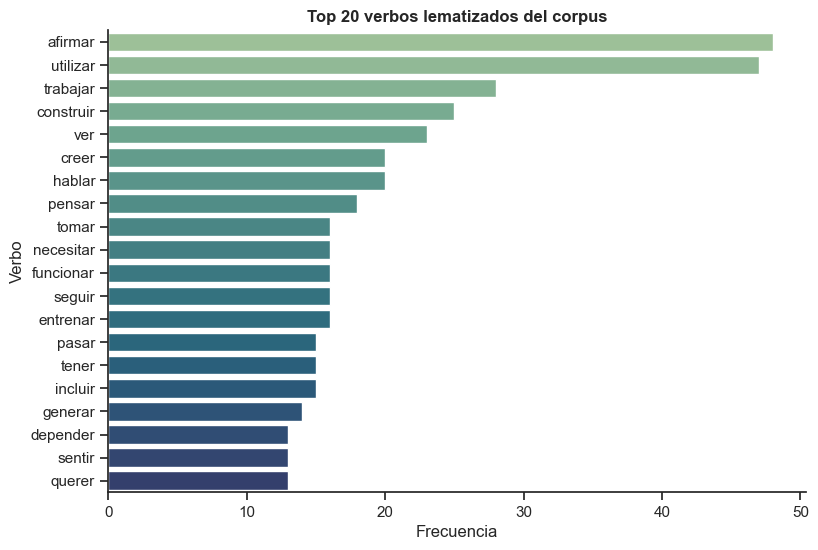

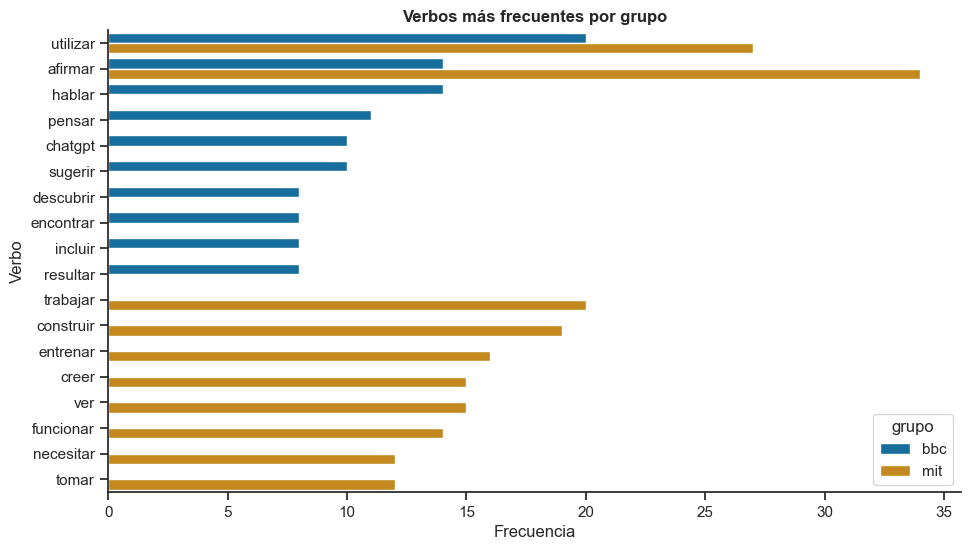

In [27]:
# Este fragmento imprime todos los verbos detectados por spaCy y sus lemas.
# Sirve para revisar cómo el modelo está lematizando acciones del corpus.
# En análisis discursivo, los verbos son importantes porque muestran acciones, procesos y relaciones.
print("VERBOS Y SUS LEMAS:\n") # Imprime un título.

for doc in docs_base: # Recorre cada documento procesado por spaCy.
    for token in doc: # Recorre cada token del documento.
        # Filtramos solo verbos reales (no stopwords ni símbolos)
        # Si queremos excluir verbos muy generales, podemos agregar: and not token.is_stop.
        if token.pos_ == "VERB" and token.is_alpha  and not token.is_stop:  # Conserva solo tokens que: 1. spaCy clasificó como verbo (VERB). 2. son alfabéticos (is_alpha).
            print(f"{token.text:15} -> {token.lemma_}") # Imprime la forma original y el lema. El formato {token.text:15} reserva 15 espacios para alinear visualmente la salida.


# La revisión de verbos permite observar qué tipos de acciones aparecen asociadas al tema de la inteligencia artificial. 
# Los verbos funcionan como indicadores de procesos: desarrollo tecnológico, uso empresarial, advertencias, riesgos, regulación o impacto social. 
# Sin embargo, la impresión completa de verbos debe complementarse con conteos y lectura contextual para evitar interpretaciones aisladas.

# Para graficar los verbos más frecuentes, utilizamos.
verbos = []

for doc in docs_base:
    for token in doc:
        if token.pos_ == "VERB" and token.is_alpha and not token.is_stop:
            verbos.append(normalizar_lemma(token))

frecuencia_verbos = Counter(verbos)

top_verbos = pd.DataFrame(
    frecuencia_verbos.most_common(20),
    columns=["verbo", "frecuencia"]
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_verbos,
    x="frecuencia",
    y="verbo",
    hue="verbo",
    palette="crest",
    legend=False
)

plt.title("Top 20 verbos lematizados del corpus", fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("Verbo")

sns.despine()
plt.show()

# El gráfico permite identificar las acciones más frecuentes del corpus. Estos verbos orientan la interpretación hacia los procesos más mencionados en los textos. 
# Por ejemplo, verbos vinculados con creación o desarrollo pueden indicar un enfoque tecnológico, mientras que verbos vinculados con advertencia, daño o preocupación pueden señalar un encuadre de riesgo.

# Para una mejor visualización, se hace una comparación de verbos entre MIT y BBC.
registros_verbos = []

for grupo, doc in zip(df[COLUMNA_GRUPO], docs_base):
    for token in doc:
        if token.pos_ == "VERB" and token.is_alpha and not token.is_stop:
            registros_verbos.append({
                "grupo": grupo,
                "verbo": normalizar_lemma(token)
            })

tabla_verbos = pd.DataFrame(registros_verbos)

top_verbos_grupo = (
    tabla_verbos
    .groupby(["grupo", "verbo"])
    .size()
    .reset_index(name="frecuencia")
    .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    .groupby("grupo")
    .head(10)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_verbos_grupo,
    x="frecuencia",
    y="verbo",
    hue="grupo",
    palette="colorblind"
)

plt.title("Verbos más frecuentes por grupo", fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("Verbo")

sns.despine()
plt.show()

# La comparación de verbos por grupo permite observar diferencias en las acciones asociadas a la inteligencia artificial. 
# Si un grupo concentra verbos como “desarrollar”, “crear” o “entrenar”, puede estar enfatizando la dimensión técnica o productiva. 
# Si otro grupo muestra verbos como “preocupar”, “afectar” o “advertir”, puede estar construyendo un enfoque más centrado en consecuencias sociales o riesgos.


In [28]:
# Esta funcion arma una tabla de frecuencias para una familia de etiquetas.
# Esta función construye una tabla de frecuencias para etiquetas lingüísticas de spaCy. Sirve para contar, por ejemplo:
# 1. categorías gramaticales: pos_;
# 2. etiquetas morfosintácticas finas: tag_;
# 3. dependencias sintácticas: dep_;
# 4. tipos de entidad por token: ent_type_.
# Es una función reutilizable: en vez de escribir un conteo distinto para cada atributo, podés llamarla cambiando el parámetro atributo.

def tabla_etiquetas(docs, atributo, incluir_vacios=False): # Define una función que recibe: 1. docs: lista de documentos spaCy; 2. atributo: el atributo del token que querés contar; 3. incluir_vacios: si querés contar o no valores vacíos.
    contador = Counter() # Crea un contador vacío.

    for doc in docs: # Recorre todos los tokens de todos los documentos.
        for token in doc:
            if token.is_space: # Ignora espacios porque no aportan informacion lingüistica.
                continue

            valor = getattr(token, atributo) # Obtiene dinámicamente el atributo indicado. Por ejemplo, si atributo = "pos_", esto equivale a:

            if not valor and not incluir_vacios: # Si el valor está vacío y no queremos contar vacíos, lo salta.
                continue

            if not valor: # Si el valor está vacío pero sí queremos incluir vacíos, lo reemplaza por "-".
                valor = "-"

            contador[valor] += 1 # Suma una ocurrencia de esa etiqueta.

    filas = []

    for etiqueta, frecuencia in contador.most_common(): # Ordena las etiquetas de mayor a menor frecuencia.
        descripcion = "-"

        if etiqueta != "-":
            explicacion = spacy.explain(etiqueta) # Busca una explicación legible de la etiqueta.
            if explicacion:
                descripcion = explicacion

        fila = { #nFinalmente arma una tabla:
            "etiqueta": etiqueta,
            "descripcion": descripcion,
            "frecuencia": frecuencia,
        }
        filas.append(fila)

    return pd.DataFrame(filas)

In [29]:
# Extiende tabla_etiquetas para separar resultados por grupo de comparacion.
def tabla_etiquetas_por_grupo(df, docs, atributo, incluir_vacios=False):
    resultados = []
    grupos = df[COLUMNA_GRUPO].unique()

    for grupo in grupos:
        indices = df.index[df[COLUMNA_GRUPO] == grupo].tolist()
        docs_grupo = [docs[i] for i in indices]
        tabla = tabla_etiquetas(docs_grupo, atributo, incluir_vacios)
        tabla["grupo"] = grupo
        resultados.append(tabla)

    return pd.concat(resultados, ignore_index=True)

In [30]:
tabla_pos = tabla_etiquetas(docs_base, "pos_")

print("POS detectadas")
display(tabla_pos.head(15))

# La distribución de categorías gramaticales permite observar qué tipos de palabras predominan en el corpus. 
# Una presencia alta de sustantivos puede indicar centralidad de conceptos, objetos o temas; una presencia alta de nombres propios puede orientar el análisis hacia actores; 
# una presencia relevante de verbos permite estudiar acciones y procesos.

POS detectadas


,etiqueta,descripcion,frecuencia
0,NOUN,noun,4482
1,ADP,adposition,3387
2,PUNCT,punctuation,2973
3,DET,determiner,2903
4,VERB,verb,2463
5,ADJ,adjective,1660
6,PROPN,proper noun,1290
7,PRON,pronoun,1236
8,ADV,adverb,994
9,AUX,auxiliary,992


TAG detectadas


,etiqueta,descripcion,frecuencia
0,NOUN,noun,4482
1,ADP,adposition,3387
2,PUNCT,punctuation,2973
3,DET,determiner,2903
4,VERB,verb,2463
5,ADJ,adjective,1660
6,PROPN,proper noun,1290
7,PRON,pronoun,1236
8,ADV,adverb,994
9,AUX,auxiliary,992


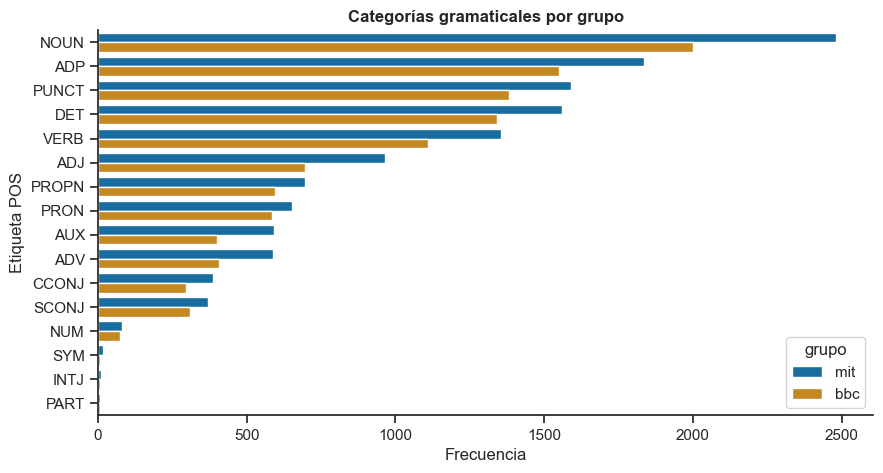

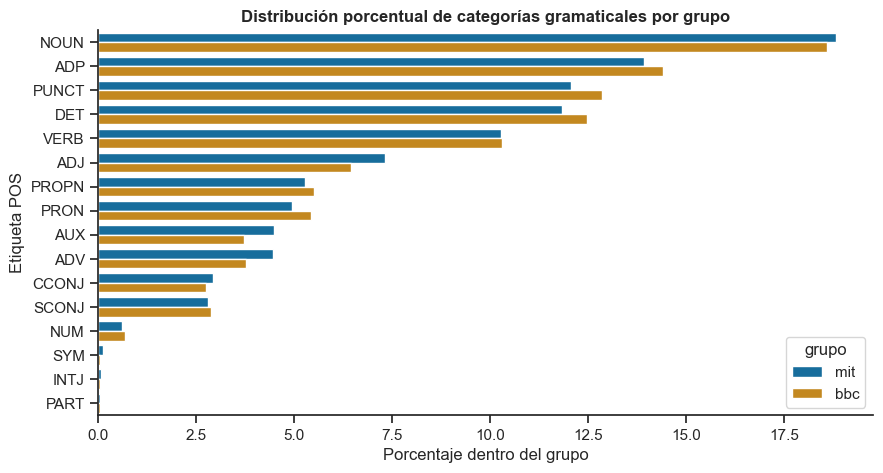

In [31]:
tabla_tag = tabla_etiquetas(docs_base, "tag_")

print("TAG detectadas")
display(tabla_tag.head(15))

# Se agrega un Gráfico Comparativo Por Grupo
tabla_pos_grupo = tabla_etiquetas_por_grupo(df, docs_base, "pos_")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=tabla_pos_grupo,
    x="frecuencia",
    y="etiqueta",
    hue="grupo",
    palette="colorblind"
)

plt.title("Categorías gramaticales por grupo", fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("Etiqueta POS")

sns.despine()
plt.show()

# La comparación de categorías gramaticales por grupo permite observar si los textos presentan diferencias de composición lingüística. 
# Por ejemplo, una mayor frecuencia de nombres propios puede sugerir más referencias a actores concretos, mientras que una mayor presencia de sustantivos comunes puede indicar un enfoque más conceptual. 
# Estas diferencias deben interpretarse junto con los términos concretos y fragmentos del corpus.

# Se realiza un calculo de porcentajes por grupo para evitar que el grupo con más palabras tenga siempre más etiquetas.
tabla_pos_grupo["total_grupo"] = tabla_pos_grupo.groupby("grupo")["frecuencia"].transform("sum")
tabla_pos_grupo["porcentaje"] = tabla_pos_grupo["frecuencia"] / tabla_pos_grupo["total_grupo"] * 100

plt.figure(figsize=(10, 5))

sns.barplot(
    data=tabla_pos_grupo,
    x="porcentaje",
    y="etiqueta",
    hue="grupo",
    palette="colorblind"
)

plt.title("Distribución porcentual de categorías gramaticales por grupo", fontweight="bold")
plt.xlabel("Porcentaje dentro del grupo")
plt.ylabel("Etiqueta POS")

sns.despine()
plt.show()

# Este gráfico es más justo que la frecuencia absoluta cuando los grupos tienen distinta cantidad de palabras.


Dependencias detectadas


c:\Users\vpena\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:pv' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
c:\Users\vpena\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:pass' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
c:\Users\vpena\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:impers' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant 

,etiqueta,descripcion,frecuencia
0,det,determiner,3007
1,punct,punctuation,2970
2,case,case marking,2816
3,nmod,modifier of nominal,1541
4,obj,object,1519
5,nsubj,nominal subject,1405
6,amod,adjectival modifier,1297
7,advmod,adverbial modifier,1121
8,mark,marker,1071
9,ROOT,root,975


,etiqueta,descripcion,frecuencia,porcentaje
0,det,determiner,3007,12.56
1,punct,punctuation,2970,12.40
2,case,case marking,2816,11.76
3,nmod,modifier of nominal,1541,6.43
4,obj,object,1519,6.34
5,nsubj,nominal subject,1405,5.87
6,amod,adjectival modifier,1297,5.42
7,advmod,adverbial modifier,1121,4.68
8,mark,marker,1071,4.47
9,ROOT,root,975,4.07


c:\Users\vpena\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:pv' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
c:\Users\vpena\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:pass' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
c:\Users\vpena\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:impers' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant 

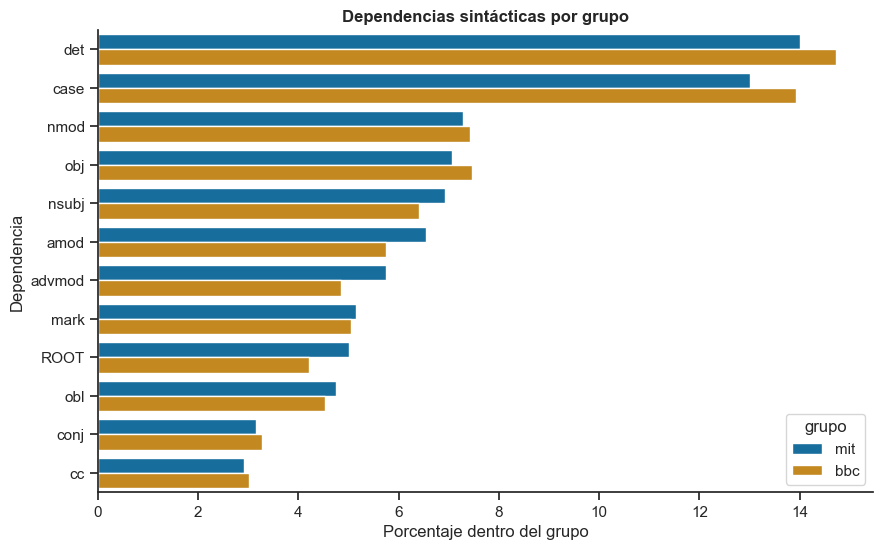

In [32]:
# Este fragmento usa la función tabla_etiquetas() para contar las dependencias sintácticas detectadas por spaCy.
# Las dependencias sintácticas describen la función que cumple cada palabra dentro de la oración.
# Por ejemplo: sujeto; objeto; modificador; raíz verbal; complemento; puntuación; determinante.
# Las dependencias sintácticas describen la función que cumple cada palabra dentro de la oración.
# Esta sección sirve para observar la estructura gramatical general del corpus.
tabla_dep = tabla_etiquetas(docs_base, "dep_") # Llama la función que definiste anteriormente. docs_base, los documentos procesados por spaCy y "dep_" el atributo de dependencia sintáctica de cada token. Esto cuenta cuántas veces aparece cada tipo de dependencia.

print("Dependencias detectadas") # Imprime un título.
display(tabla_dep.head(15)) # Muestra las primeras 15 dependencias más frecuentes.

# Es útil agregar porcentajes:
tabla_dep["porcentaje"] = tabla_dep["frecuencia"] / tabla_dep["frecuencia"].sum() * 100
display(tabla_dep.head(15).round(2))

# La tabla de dependencias muestra las funciones sintácticas más frecuentes en el corpus. Este análisis permite observar la estructura gramatical general de los textos y complementar la lectura léxica. 
# Aunque las dependencias no ofrecen por sí solas una interpretación discursiva directa, ayudan a identificar si predominan sujetos, objetos, modificadores o estructuras descriptivas.

# Agregamos un gráfico de las dependencias más frecuentes por grupos:
tabla_dep_grupo = tabla_etiquetas_por_grupo(df, docs_base, "dep_")

# Quitamos puntuacion si aparece.
tabla_dep_grupo = tabla_dep_grupo[tabla_dep_grupo["etiqueta"] != "punct"]

# Calculamos porcentaje dentro de cada grupo.
tabla_dep_grupo["total_grupo"] = tabla_dep_grupo.groupby("grupo")["frecuencia"].transform("sum")
tabla_dep_grupo["porcentaje"] = tabla_dep_grupo["frecuencia"] / tabla_dep_grupo["total_grupo"] * 100

# Nos quedamos con las dependencias mas frecuentes globalmente.
deps_top = (
    tabla_dep_grupo
    .groupby("etiqueta")["frecuencia"]
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .index
)

tabla_dep_top = tabla_dep_grupo[tabla_dep_grupo["etiqueta"].isin(deps_top)]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=tabla_dep_top,
    x="porcentaje",
    y="etiqueta",
    hue="grupo",
    palette="colorblind"
)

plt.title("Dependencias sintácticas por grupo", fontweight="bold")
plt.xlabel("Porcentaje dentro del grupo")
plt.ylabel("Dependencia")

sns.despine()
plt.show()

# La comparación porcentual evita que el grupo con mayor cantidad de palabras domine el resultado. 
# Si las proporciones son similares, puede interpretarse que ambos grupos tienen estructuras sintácticas generales parecidas. 
# Si una dependencia aparece proporcionalmente más en un grupo, conviene revisar ejemplos concretos para evaluar si esa diferencia tiene valor interpretativo.


Entidades detectadas


,etiqueta,descripcion,frecuencia
0,MISC,"Miscellaneous entities, e.g. events, nationalities, products or works of art",1179
1,ORG,"Companies, agencies, institutions, etc.",309
2,PER,Named person or family.,293
3,LOC,"Non-GPE locations, mountain ranges, bodies of water",203


,grupo,etiqueta,descripcion,frecuencia
1,bbc,MISC,"Miscellaneous entities, e.g. events, nationalities, products or works of art",162
2,bbc,ORG,"Companies, agencies, institutions, etc.",130
3,bbc,PER,Named person or family.,108
0,bbc,LOC,"Non-GPE locations, mountain ranges, bodies of water",70
5,mit,MISC,"Miscellaneous entities, e.g. events, nationalities, products or works of art",331
6,mit,ORG,"Companies, agencies, institutions, etc.",120
7,mit,PER,Named person or family.,101
4,mit,LOC,"Non-GPE locations, mountain ranges, bodies of water",80


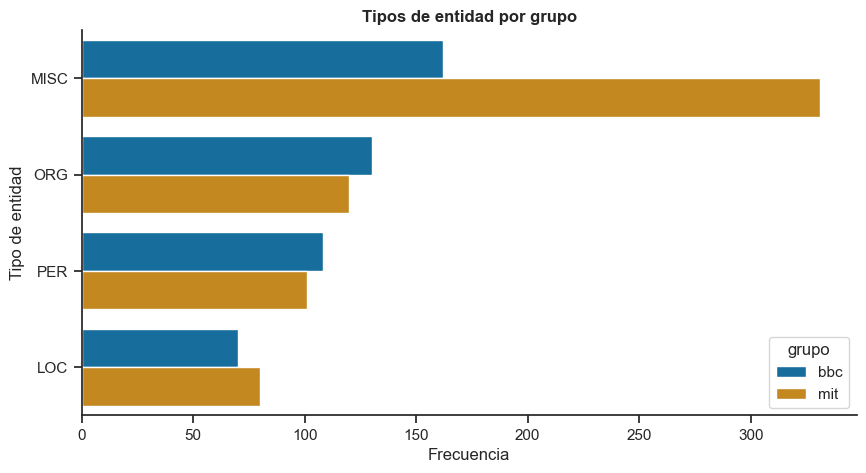

In [33]:
# Este fragmento cuenta los tipos de entidades nombradas detectadas por spaCy usando el atributo: ent_type_ 
# Sirve para ver qué clases de entidades aparecen en el corpus, por ejemplo: personas; organizaciones; lugares; fechas; misceláneas.
# En el contexto del TP, nos ayuda a identificar qué actores o referencias aparecen en los textos sobre inteligencia artificial.
tabla_ent = tabla_etiquetas(docs_base, "ent_type_") # Usa la función tabla_etiquetas() para recorrer todos los tokens del corpus y contar el atributo ent_type_.

print("Entidades detectadas") # Muestra un título.
display(tabla_ent.head(15)) # Muestra los 15 tipos de entidad más frecuentes. Este código cuenta entidades a nivel de token, no a nivel de entidad completa.

# El análisis de entidades permite identificar qué tipos de actores o referencias aparecen en el corpus. En textos sobre inteligencia artificial pueden aparecer organizaciones tecnológicas, personas expertas, instituciones, países, fechas o productos. 
# Esta información ayuda a pasar de un análisis puramente léxico a una lectura de actores y referencias discursivas.

# Para el TP, lo más útil es contar entidades por grupo.
registros_entidades = []

for fila, doc in zip(df.itertuples(), docs_base):
    grupo = getattr(fila, COLUMNA_GRUPO)

    for ent in doc.ents:
        registros_entidades.append({
            "grupo": grupo,
            "texto_entidad": ent.text.strip(),
            "etiqueta": ent.label_,
            "descripcion": spacy.explain(ent.label_) or "-"
        })

df_entidades = pd.DataFrame(registros_entidades)

tabla_tipos_entidad = (
    df_entidades
    .groupby(["grupo", "etiqueta", "descripcion"])
    .size()
    .reset_index(name="frecuencia")
    .sort_values(["grupo", "frecuencia"], ascending=[True, False])
)

display(tabla_tipos_entidad)

# Esto te permite comparar si MIT y BBC mencionan distintos tipos de entidades.

# Gráfico de tipos de entidad por grupo:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=tabla_tipos_entidad,
    x="frecuencia",
    y="etiqueta",
    hue="grupo",
    palette="colorblind"
)

plt.title("Tipos de entidad por grupo", fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("Tipo de entidad")

sns.despine()
plt.show()

# NOTA: El gráfico compara los tipos de entidades nombradas detectadas en cada grupo. Si un grupo presenta más organizaciones, puede estar construyendo el tema desde actores institucionales o empresariales. 
# Si otro grupo presenta más personas, puede estar apoyándose más en testimonios, expertos o casos individuales.



Rasgos morfologicos detectados


,morph,frecuencia
0,-,6861
1,Gender=Masc|Number=Sing,1511
2,Gender=Fem|Number=Sing,1456
3,PunctType=Comm,1186
4,Gender=Masc|Number=Plur,974
5,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin,941
6,PunctType=Peri,939
7,Gender=Fem|Number=Plur,716
8,Definite=Def|Gender=Fem|Number=Sing|PronType=Art,685
9,VerbForm=Inf,656


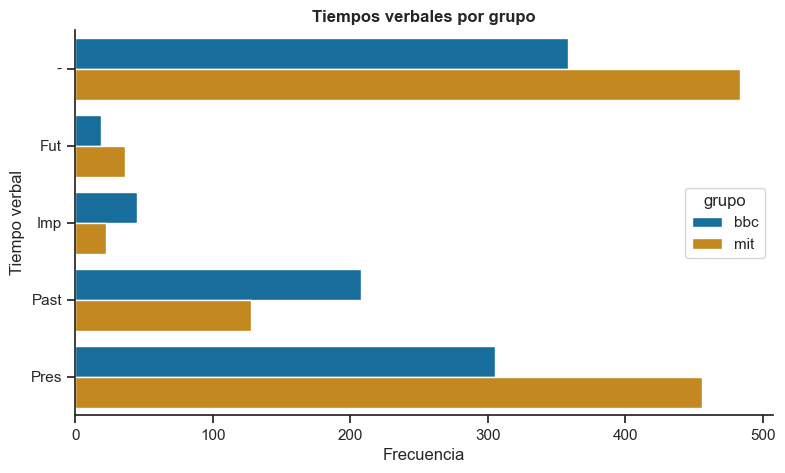

In [34]:
# Este fragmento cuenta los rasgos morfológicos detectados por spaCy en el corpus.

#Los rasgos morfológicos describen información gramatical más fina, como: número: singular o plural; género: masculino o femenino; persona verbal; 
# tiempo verbal; modo verbal; forma verbal; grado; tipo de pronombre o determinante.
# Esta sección sirve para observar características gramaticales generales del corpus.
def tabla_morph(docs): # Define una función y crea un contador.
    contador = Counter()

    for doc in docs: # Recorre todos los documentos y todos los tokens.
        for token in doc:
            if token.is_space: # Ignora espacios.
                continue

            rasgos = str(token.morph) # Convierte los rasgos morfológicos del token a texto.

            if not rasgos: # Si el token no tiene rasgos, lo registra como "-".
                rasgos = "-"

            contador[rasgos] += 1 # Cuenta cada combinación de rasgos.

    filas = []

    for rasgos, frecuencia in contador.most_common(): # Convierte el contador en una lista de filas ordenadas por frecuencia.
        filas.append({"morph": rasgos, "frecuencia": frecuencia})

    return pd.DataFrame(filas) # Devuelve una tabla.

tabla_morf = tabla_morph(docs_base) # Genera y muestra las 15 combinaciones morfológicas más frecuentes.

print("Rasgos morfologicos detectados")
display(tabla_morf.head(15))

# La tabla de rasgos morfológicos muestra las combinaciones gramaticales más frecuentes detectadas por spaCy. 
# Estos rasgos permiten observar propiedades como género, número, persona o tiempo verbal. 
# Aunque este análisis no ofrece por sí solo una interpretación temática, ayuda a comprender cómo está compuesto lingüísticamente el corpus.

# La presencia frecuente de rasgos de género y número se relaciona con la abundancia de sustantivos, adjetivos y determinantes en el corpus.
# Los rasgos verbales permiten observar tiempos y modos predominantes. Una presencia fuerte del presente puede asociarse a textos explicativos o periodísticos que describen fenómenos actuales.

# Agregamos un gráfico de los tiempos verbales por grupo:
registros_tiempos = []

for grupo, doc in zip(df[COLUMNA_GRUPO], docs_base):
    for token in doc:
        if token.pos_ == "VERB" and token.is_alpha and not token.is_stop:
            tiempo = token.morph.get("Tense")

            registros_tiempos.append({
                "grupo": grupo,
                "tiempo": tiempo[0] if tiempo else "-"
            })

tabla_tiempos = pd.DataFrame(registros_tiempos)

conteo_tiempos = (
    tabla_tiempos
    .groupby(["grupo", "tiempo"])
    .size()
    .reset_index(name="frecuencia")
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=conteo_tiempos,
    x="frecuencia",
    y="tiempo",
    hue="grupo",
    palette="colorblind"
)

plt.title("Tiempos verbales por grupo", fontweight="bold")
plt.xlabel("Frecuencia")
plt.ylabel("Tiempo verbal")

sns.despine()
plt.show()

# La distribución de tiempos verbales permite observar si los textos se orientan más a describir hechos actuales, procesos pasados o proyecciones. 
# En un corpus periodístico sobre IA, una presencia elevada del presente puede indicar explicación de fenómenos vigentes, mientras que formas futuras o condicionales pueden asociarse con predicciones, 
# advertencias o escenarios posibles.


Agreguen una celda Markdown nueva y registren al menos **dos límites o errores** que observen en el pipeline de `spaCy` sobre su corpus.

## Límites observados en el pipeline de spaCy

### Límite 1 — Filtrado de stopwords incompleto

**Observación:** Luego de aplicar la lista de stopwords de spaCy (`es_core_news_md`), 
siguen apareciendo en las frecuencias altas palabras de función gramatical como 
determinantes (*el*, *la*, *los*, *un*) y preposiciones (*de*, *en*, *a*). 
Estas palabras no aportan contenido temático al análisis.

**Causa técnica:** La lista de stopwords de spaCy cubre un conjunto fijo de formas 
léxicas, pero no todas las variantes morfológicas ni todas las palabras de baja 
carga semántica en contextos periodísticos específicos. Además, el filtrado se 
aplica sobre tokens lematizados, y si el lema no coincide exactamente con la 
entrada de la lista, la palabra no se descarta.

**Impacto en el análisis:** Las frecuencias resultantes en BoW y TF-IDF pueden 
estar distorsionadas, ya que palabras de función ocupa posiciones altas en los 
rankings que deberían corresponder a términos temáticamente relevantes como 
*inteligencia*, *modelo* o *datos*.

**Ajuste propuesto:** Complementar la lista de spaCy con stopwords adicionales 
específicas del dominio (artículos periodísticos en español sobre tecnología), 
o aplicar un filtro secundario por categoría gramatical POS: excluir todos los 
tokens cuyo `pos_` sea `DET`, `ADP`, `PUNCT` o `AUX`.


_ _ _ 


### Límite 2 — Clasificación imprecisa de entidades nombradas (NER)

**Observación:** Una proporción elevada de las entidades detectadas por el modelo 
son etiquetadas como `MISC` (misceláneas), categoría que agrupa todo lo que el 
modelo no logra clasificar con precisión como persona (`PER`), organización (`ORG`) 
o lugar (`LOC`).

**Causa técnica:** El modelo `es_core_news_md` fue entrenado principalmente sobre 
texto periodístico general en español (noticias europeas). El corpus analizado 
contiene términos del dominio tecnológico —nombres de modelos de IA, empresas 
emergentes y acrónimos en inglés— que no están representados en los datos de 
entrenamiento del modelo. Ante entidades desconocidas, el modelo recurre a la 
categoría residual `MISC`.

**Impacto en el análisis:** El análisis de entidades nombradas pierde resolución: 
no se puede distinguir cuántas entidades son organizaciones versus productos 
tecnológicos versus conceptos abstractos. Esto limita la comparación entre grupos 
(MIT vs BBC) en términos de actores y referencias nombradas.

**Ajuste propuesto:** Aplicar un `EntityRuler` con patrones definidos manualmente 
para las entidades recurrentes del corpus (por ejemplo: *OpenAI* → `ORG`, 
*ChatGPT* → `PRODUCT`, *Estados Unidos* → `LOC`). Esto permite corregir 
clasificaciones erróneas sin necesidad de re-entrenar el modelo.


En esta sección se realiza un ajuste en el enfoque del análisis, pasando de etiquetas a entidades concretas. En lugar de observar categorías gramaticales, se analizan personas, organizaciones y lugares presentes en el corpus, lo que permite interpretar mejor el contenido real de los textos.

In [35]:
# Este fragmento extrae las entidades nombradas completas detectadas por spaCy y las guarda en un DataFrame.
# Es una mejora importante respecto a contar token.ent_type_, porque acá ya no contás tokens individuales, sino entidades completas como: OpenAI; ChatGPT; MIT Technology Review; Yann LeCun; Estados Unidos
# Esto permite analizar qué actores, instituciones, personas, lugares o modelos aparecen en el corpus.

registros_entidades = [] # Crea una lista vacía para guardar entidades.

for doc_id, titulo, grupo, doc in zip(df["id"], df["titulo"], df[COLUMNA_GRUPO], docs_base):
    for ent in doc.ents: # Recorre las entidades detectadas en cada documento.
        fila = { # Crea una fila con información de la entidad:
            "id": doc_id,
            "titulo": titulo,
            "grupo": grupo,
            "texto_entidad": ent.text,
            "etiqueta": ent.label_,
        }
        registros_entidades.append(fila) # Guarda la fila.

df_entidades = pd.DataFrame(registros_entidades) # Convierte la lista en una tabla.

if df_entidades.empty: # Si no hay entidades, avisa. Si hay, muestra las primeras 20.
    print("No se detectaron entidades en el corpus.")
else:
    print("Muestra de entidades detectadas")
    display(df_entidades.head(20))

# La extracción de entidades nombradas permite identificar actores y referencias relevantes dentro del corpus. 
# A diferencia del conteo de palabras, este análisis permite observar quiénes aparecen como protagonistas del discurso: empresas tecnológicas, investigadores, instituciones, países, productos o personas mencionadas en los artículos.



Muestra de entidades detectadas


,id,titulo,grupo,texto_entidad,etiqueta
0,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Las organizaciones están desplegando copilotos,MISC
1,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Para finales de 2025,MISC
2,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,La IA,MISC
3,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Irfan Khan,PER
4,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,SAP Data & Analytics,ORG
5,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,La velocidad sin juicio,MISC
6,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,De hecho,MISC
7,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Khan,MISC
8,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,El tejido de datos adecuado,MISC
9,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Este cambio está impulsando un interés creciente en el data fabric,MISC


In [36]:
display(df_entidades.groupby("grupo").head(20))

# La muestra por grupo permite auditar manualmente el reconocimiento de entidades. Esta revisión es necesaria porque los modelos NER pueden cometer errores de segmentación o clasificación, 
# especialmente con nombres de empresas, modelos tecnológicos o expresiones recientes vinculadas a inteligencia artificial.

,id,titulo,grupo,texto_entidad,etiqueta
0,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Las organizaciones están desplegando copilotos,MISC
1,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Para finales de 2025,MISC
2,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,La IA,MISC
3,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Irfan Khan,PER
4,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,SAP Data & Analytics,ORG
5,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,La velocidad sin juicio,MISC
6,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,De hecho,MISC
7,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Khan,MISC
8,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,El tejido de datos adecuado,MISC
9,1,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,Este cambio está impulsando un interés creciente en el data fabric,MISC


In [37]:
#  crear una tabla de frecuencia de entidades concretas por grupo. Esto permite interpretar visibilidad de actores.
if df_entidades.empty:
    tabla_tipos_entidad = pd.DataFrame(
        columns=["grupo", "etiqueta", "frecuencia"]
    )
else:
    tabla_tipos_entidad = (
        df_entidades
        .groupby(["grupo", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )

print("Tipos de entidad por grupo")
display(tabla_tipos_entidad)

Tipos de entidad por grupo


,grupo,etiqueta,frecuencia
1,bbc,MISC,162
2,bbc,ORG,130
3,bbc,PER,108
0,bbc,LOC,70
5,mit,MISC,331
6,mit,ORG,120
7,mit,PER,101
4,mit,LOC,80


Al comparar los tipos de entidades por grupo, se observa que en MIT predomina fuertemente la categoría MISC, lo que indica que el modelo no logra clasificar correctamente muchas entidades. En cambio, en BBC hay una distribución más equilibrada, con mayor presencia de organizaciones y personas. Esto sugiere que el modelo funciona mejor en los textos de BBC y presenta más limitaciones en los de MIT.

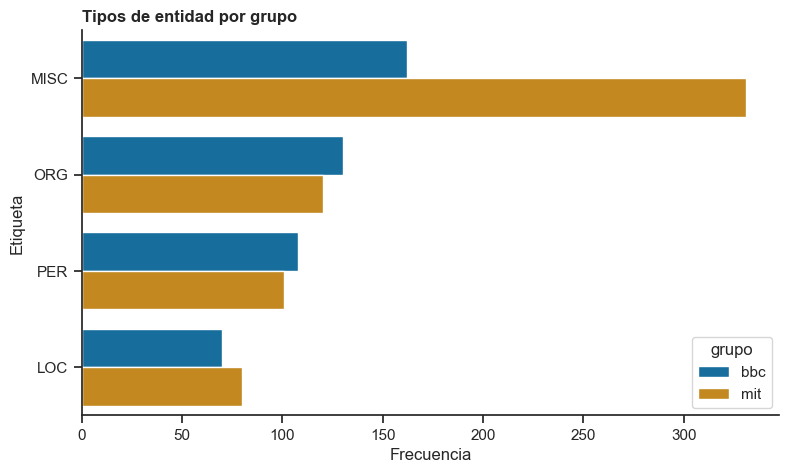

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

if tabla_tipos_entidad.empty:
    print("No hay entidades para graficar.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))

    sns.barplot(
        data=tabla_tipos_entidad,
        x="frecuencia",
        y="etiqueta",
        hue="grupo",
        ax=ax
    )

    ax.set_title("Tipos de entidad por grupo", loc="left", fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("Etiqueta")

    sns.despine()
    plt.show()

In [39]:
if df_entidades.empty:
    tabla_entidades_concretas = pd.DataFrame(
        columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"]
    )
    top_entidades_concretas = tabla_entidades_concretas.copy()

else:
    # Contamos entidades por grupo
    tabla_entidades_concretas = (
        df_entidades
        .groupby(["grupo", "texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values(["grupo", "frecuencia"], ascending=[True, False])
    )

    # Nos quedamos con el TOP 10 por grupo (BBC vs MIT)
    top_entidades_concretas = (
        tabla_entidades_concretas
        .groupby("grupo")
        .head(10)
    )

print("Entidades concretas por grupo")
display(top_entidades_concretas)

Entidades concretas por grupo


,grupo,texto_entidad,etiqueta,frecuencia
37,bbc,ChatGPT,MISC,28
87,bbc,Google,ORG,24
99,bbc,IA,MISC,24
157,bbc,OpenAI,ORG,17
100,bbc,IA,ORG,14
213,bbc,Viktoria,PER,12
26,bbc,BBC,ORG,11
145,bbc,Mythos,MISC,10
117,bbc,Kosmyna,PER,9
20,bbc,Anthropic,PER,8


Al observar las entidades más frecuentes, se ve que el modelo reconoce correctamente muchas organizaciones y personas, como Google, OpenAI o BBC. Sin embargo, aparecen varios errores de clasificación: por ejemplo, “ChatGPT” y “Google DeepMind” son etiquetados como MISC en lugar de ORG, y “Meta” incluso aparece como LOC. Además, términos como “IA” se clasifican de forma inconsistente en distintas categorías. Esto muestra que el modelo tiene dificultades para clasificar correctamente entidades tecnológicas actuales.

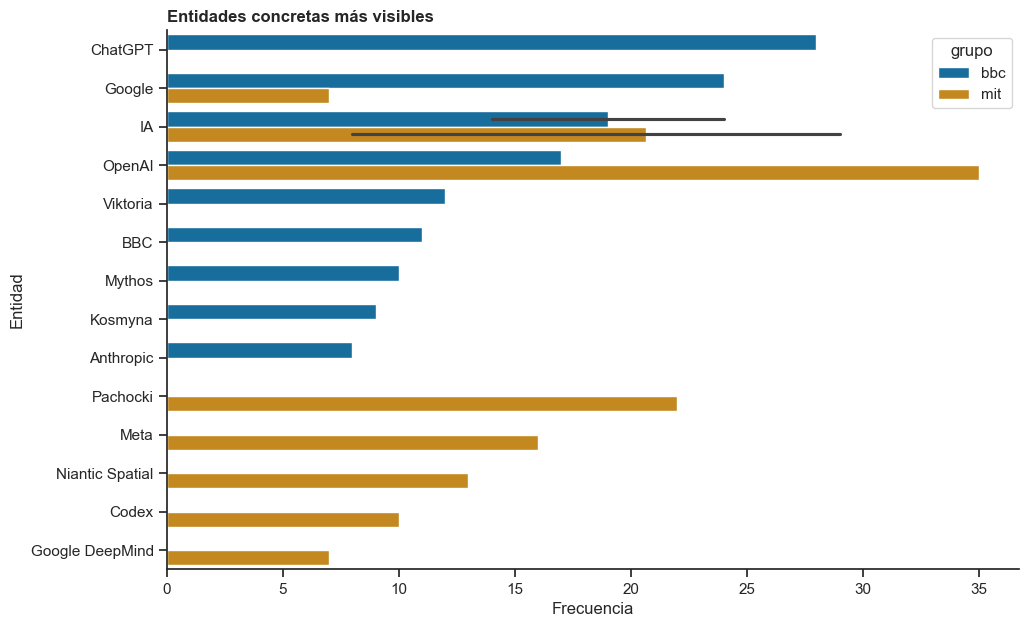

In [40]:
# Este código en Python sirve para visualizar en un gráfico de barras las entidades concretas más frecuentes en el corpus, 
# separándolas según el grupo de comparación (por ejemplo, textos de MIT Technology Review vs textos de BBC).
import matplotlib.pyplot as plt
import seaborn as sns

if top_entidades_concretas.empty:
    print("No hay entidades concretas para graficar.")
else:
    fig, ax = plt.subplots(figsize=(11, 7))

    sns.barplot(
        data=top_entidades_concretas,
        x="frecuencia",
        y="texto_entidad",
        hue="grupo",
        ax=ax
    )

    ax.set_title("Entidades concretas más visibles", loc="left", fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("Entidad")

    sns.despine()
    plt.show()

In [41]:
# Este fragmento de código se usa dentro de un análisis de Procesamiento de Lenguaje Natural (PLN) para separar las entidades detectadas en el corpus según su tipo, específicamente organizaciones y lugares.
if tabla_entidades_concretas.empty:
    entidades_org = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    entidades_loc = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])

else:
    # Filtramos organizaciones (ORG)
    entidades_org = tabla_entidades_concretas[
        tabla_entidades_concretas["etiqueta"] == "ORG"
    ]

    # Filtramos lugares (LOC)
    entidades_loc = tabla_entidades_concretas[
        tabla_entidades_concretas["etiqueta"] == "LOC"
    ]



In [42]:
# Este código se usa para mostrar las entidades detectadas en el corpus separadas por tipo de entidad y por grupo del corpus.
# En tu caso, los grupos corresponden a textos de BBC y MIT Technology Review. El objetivo del código es ver rápidamente qué organizaciones y lugares aparecen en cada medio.
print("Organizaciones BBC")
org_bbc = entidades_org[entidades_org["grupo"] == "bbc"]

if org_bbc.empty:
    print("No hay organizaciones en BBC")
else:
    display(org_bbc.head(10))


print("\nOrganizaciones MIT")
org_mit = entidades_org[entidades_org["grupo"] == "mit"]

if org_mit.empty:
    print("No hay organizaciones en MIT")
else:
    display(org_mit.head(10))


print("\nLugares BBC")
loc_bbc = entidades_loc[entidades_loc["grupo"] == "bbc"]

if loc_bbc.empty:
    print("No hay lugares en BBC")
else:
    display(loc_bbc.head(10))


print("\nLugares MIT")
loc_mit = entidades_loc[entidades_loc["grupo"] == "mit"]

if loc_mit.empty:
    print("No hay lugares en MIT")
else:
    display(loc_mit.head(10))

Organizaciones BBC


,grupo,texto_entidad,etiqueta,frecuencia
87,bbc,Google,ORG,24
157,bbc,OpenAI,ORG,17
100,bbc,IA,ORG,14
26,bbc,BBC,ORG,11
165,bbc,Pichai,ORG,7
154,bbc,Nvidia,ORG,6
196,bbc,Time,ORG,5
3,bbc,AI,ORG,4
21,bbc,Apple,ORG,4
139,bbc,Microsoft,ORG,4



Organizaciones MIT


,grupo,texto_entidad,etiqueta,frecuencia
471,mit,OpenAI,ORG,35
368,mit,IA,ORG,29
357,mit,Google,ORG,7
459,mit,Niantic,ORG,5
380,mit,JEPA,ORG,4
453,mit,Microsoft,ORG,3
233,mit,AMI,ORG,2
234,mit,AMI Labs,ORG,2
456,mit,NYU,ORG,2
479,mit,Pentágono,ORG,2



Lugares BBC


,grupo,texto_entidad,etiqueta,frecuencia
137,bbc,Meta,LOC,6
68,bbc,Estados Unidos,LOC,5
141,bbc,Ming,LOC,4
172,bbc,Reino Unido,LOC,4
184,bbc,Silicon Valley,LOC,4
98,bbc,IA,LOC,3
191,bbc,Svitlana,LOC,3
27,bbc,Banco de Inglaterra,LOC,2
34,bbc,Character,LOC,2
38,bbc,China,LOC,2



Lugares MIT


,grupo,texto_entidad,etiqueta,frecuencia
446,mit,Meta,LOC,16
366,mit,IA,LOC,8
478,mit,París,LOC,6
301,mit,EE UU,LOC,4
264,mit,China,LOC,3
344,mit,Francia,LOC,3
467,mit,Nueva York,LOC,3
523,mit,Silicon Valley,LOC,3
263,mit,Chicago,LOC,2
328,mit,Estados Unidos,LOC,2


In [43]:
# Este fragmento de código se usa dentro de un análisis de Procesamiento de Lenguaje Natural (PLN) para separar las entidades detectadas en el corpus como MISC
# Y poder modificarlo en un paso posterior si corresponde
if tabla_entidades_concretas.empty:
    entidades_misc = pd.DataFrame(columns=["grupo", "texto_entidad", "etiqueta", "frecuencia"])
    

else:
    # Filtramos MISC
    entidades_misc = tabla_entidades_concretas[
        tabla_entidades_concretas["etiqueta"] == "MISC"
    ]

print("Organizaciones BBC")
org_bbc = entidades_misc[entidades_misc["grupo"] == "bbc"]

if org_bbc.empty:
    print("No hay organizaciones en BBC")
else:
    display(org_bbc.head(10))


print("\nOrganizaciones MIT")
org_mit = entidades_misc[entidades_misc["grupo"] == "mit"]

if org_mit.empty:
    print("No hay organizaciones en MIT")
else:
    display(org_mit.head(10))

Organizaciones BBC


,grupo,texto_entidad,etiqueta,frecuencia
37,bbc,ChatGPT,MISC,28
99,bbc,IA,MISC,24
145,bbc,Mythos,MISC,10
46,bbc,Cynthia,MISC,4
225,bbc,internet,MISC,4
19,bbc,Anthropic,MISC,3
83,bbc,GPU,MISC,3
6,bbc,Acceso,MISC,2
14,bbc,Amazon,MISC,2
74,bbc,Facebook,MISC,2



Organizaciones MIT


,grupo,texto_entidad,etiqueta,frecuencia
367,mit,IA,MISC,25
460,mit,Niantic Spatial,MISC,13
272,mit,Codex,MISC,10
358,mit,Google DeepMind,MISC,7
240,mit,Ahora,MISC,6
338,mit,FAIR,MISC,6
461,mit,No,MISC,6
390,mit,La IA,MISC,5
425,mit,Los LLM,MISC,5
493,mit,Pokémon Go,MISC,5


Al analizar las organizaciones y lugares, se observa que en BBC predominan empresas tecnológicas y medios como Google, OpenAI o BBC, mientras que en MIT aparecen más instituciones académicas y términos técnicos como NYU o JEPA.

Sin embargo, también se detectan errores en el modelo. Por ejemplo, “Meta” es clasificado como lugar (LOC) cuando en realidad es una organización, y “IA” aparece tanto como organización como lugar. 

Esto nos muestra que aunque spaCy reconoce entidades relevantes, tiene dificultades para clasificarlas correctamente.

## 5. Stopwords: `spaCy` vs `NLTK`

Comparen ambos enfoques antes de decidir. No existe una lista universalmente correcta.

**Vocabulario de esta seccion**

- **stopword**: palabra muy frecuente que muchas veces aporta poco para diferenciar textos;
- **lista base**: conjunto inicial de stopwords que tomamos de una librería;
- **lista ajustada**: lista base modificada segun las necesidades del corpus.

Stopwords spaCy: 521
Stopwords NLTK: 313


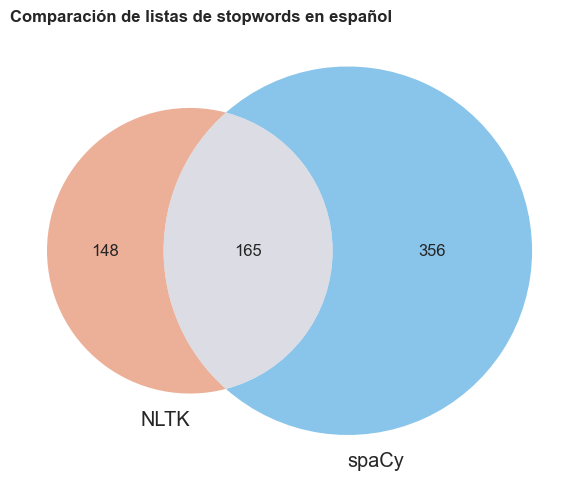

In [44]:
# Este fragmento construye dos listas de stopwords en español — palabras vacías que se filtran antes de analizar frecuencias, porque no aportan significado temático (de, la, que, en…).
# stopwords_nltk: lista de NLTK, más conservadora (~313 palabras)
# stopwords_spacy: lista del modelo cargado, más completa (~523 palabras) .add("él") en ambas: corrección manual porque "él" con tilde a veces escapa a los filtros automáticos 
# El objetivo es tener ambas disponibles para elegir cuál usar según la situación.

# # Carga la librería NLTK y su lista de stopwords en español.
import nltk
from nltk.corpus import stopwords
#!pip install matplotlib-venn

nltk.download("stopwords", quiet=True) # Descarga silenciosa: no imprime mensajes si ya están descargadas.

## Lista de stopwords de NLTK (~313 palabras).
# Es más conservadora: cubre las palabras funcionales más comunes.
stopwords_nltk = set(stopwords.words("spanish"))
stopwords_nltk.add("él")

# Lista de stopwords del modelo spaCy cargado (~523 palabras).
# Es más completa: incluye variantes morfológicas y formas verbales auxiliares.
stopwords_spacy = set(nlp.Defaults.stop_words)
stopwords_spacy.add("él")

print(f"Stopwords spaCy: {len(stopwords_spacy)}")
print(f"Stopwords NLTK: {len(stopwords_nltk)}")

# "La lista de stopwords de spaCy contiene aproximadamente 523 entradas frente a las 313 de NLTK, lo que representa una diferencia de ~210 palabras. 
# Esta diferencia se debe a que spaCy incluye variantes morfológicas (formas conjugadas, plurales) mientras que NLTK lista principalmente lemas base. 
# Para este análisis se utilizará la lista de spaCy por ser más exhaustiva, reduciendo así el riesgo de que palabras funcionales distorsionen los rankings de frecuencia."

# Uso de diagrama Diagrama de Venn de stopwords:
# pip install matplotlib-venn  (si no está instalado)
# Muestra visualmente qué palabras comparten y cuáles son exclusivas de cada lista.
from matplotlib_venn import venn2

fig, ax = plt.subplots(figsize=(7, 5))

venn2(
    subsets=[stopwords_nltk, stopwords_spacy],
    set_labels=("NLTK", "spaCy"),
    set_colors=("#e07b54", "#3b9edd"),
    alpha=0.6,
    ax=ax
)

ax.set_title("Comparación de listas de stopwords en español", fontweight="bold", loc="left")
plt.tight_layout()
plt.show()

# Si matplotlib-venn no está instalado, corrés pip install matplotlib-venn en la terminal con el venv activo. 
# El diagrama muestra tres zonas: exclusivo NLTK, exclusivo spaCy, y compartidas — dejando claro por qué spaCy filtra más agresivamente.

Stopwords spaCy: 523
Stopwords NLTK: 315
Palabras añadidas manualmente: 4
Detalle: {'ia', 'ella', 'él', 'ai'}


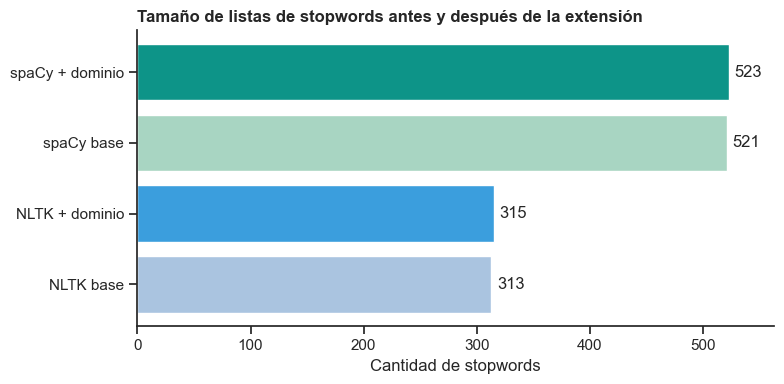

In [45]:
# Este fragmento actualiza las listas de stopwords agregando palabras específicas del corpus que, aunque no son stopwords gramaticales, se comportan como tales en este contexto:
# son tan frecuentes en ambos grupos que no ayudan a diferenciarlos.
# "él", "ella" → formas pronominales que escapan al filtro base
# "ia" → abreviatura de inteligencia artificial, aparece ~205 veces en todo el corpus — está en todos los artículos de ambos grupos casi por igual
# "ai" → equivalente en inglés, frecuente en un corpus sobre tecnología traducida
# El bucle aplica la extensión a ambas listas de una sola vez, lo cual es más limpio que llamar .add() individualmente.

import nltk
from nltk.corpus import stopwords

# Descarga silenciosa del corpus de stopwords de NLTK.
nltk.download("stopwords", quiet=True)#

# Listas base de stopwords en español.
stopwords_nltk = set(stopwords.words("spanish"))
stopwords_spacy = set(nlp.Defaults.stop_words)

# Stopwords extra adaptadas al corpus
# Extensión con términos específicos del corpus.
# "ia" / "ai" son omnipresentes en ambos grupos y no aportan poder discriminativo.
# "él" / "ella" son pronominales que escapan al filtro base por la tilde.
stopwords_extra = {"él", "ella", "ia", "ai"}

for palabra in stopwords_extra:
    stopwords_nltk.add(palabra)
    stopwords_spacy.add(palabra)

print(f"Stopwords spaCy: {len(stopwords_spacy)}")
print(f"Stopwords NLTK: {len(stopwords_nltk)}")

# Además de las listas base, se incorporaron stopwords específicas del dominio. La abreviatura 'ia' fue la más frecuente del corpus con ~205 ocurrencias 
# distribuidas de forma similar entre ambos grupos, lo que confirma que no tiene poder discriminativo entre MIT y BBC. 
# Al neutralizarla, los rankings de frecuencia y los vectores TF-IDF van a reflejar con mayor precisión el vocabulario diferencial de cada medio."

# Para observar el impacto antes/después: Determinamos cuántas palabras se agregaron con la extensión
print(f"Palabras añadidas manualmente: {len(stopwords_extra)}")
print(f"Detalle: {stopwords_extra}")

# Gráfica para visualizar el impacto de la extensión de stopwords
# Compara el tamaño de cada lista antes y después de la extensión de dominio.
categorias = ["NLTK base", "NLTK + dominio", "spaCy base", "spaCy + dominio"]
valores    = [
    len(set(stopwords.words("spanish"))),
    len(stopwords_nltk),
    len(nlp.Defaults.stop_words),
    len(stopwords_spacy)
]
colores = ["#aac4e0", "#3b9edd", "#a8d5c2", "#0d9488"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(categorias, valores, color=colores)
ax.bar_label(bars, padding=4)
ax.set_xlabel("Cantidad de stopwords")
ax.set_title("Tamaño de listas de stopwords antes y después de la extensión",
             fontweight="bold", loc="left")
ax.set_xlim(0, max(valores) + 40)
sns.despine()
plt.tight_layout()
plt.show()

# Este gráfico deja visible cuánto creció cada lista con la extensión de dominio y justifica visualmente la decisión metodológica.



In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
filtradas_nltk = stopwords_nltk
filtradas_spacy = stopwords_spacy

Ejemplos de palabras que aparecen solo en spaCy:


0             acuerdo
1            adelante
2              ademas
3              además
4              afirmó
5              agregó
6                 ahi
7               ahora
8                 ahí
9              alguna
10             alguno
11              algún
12               alli
13               allí
14          alrededor
15              ambos
16           anterior
17             apenas
18    aproximadamente
19              aquel
dtype: str

Ejemplos de palabras que aparecen solo en NLTK:


0          erais
1       estabais
2        estabas
3          estad
4         estada
5        estadas
6        estando
7      estaremos
8        estarán
9        estarás
10        estaré
11      estaréis
12       estaría
13     estaríais
14    estaríamos
15      estarían
16      estarías
17       estemos
18        estuve
19     estuviera
dtype: str

Total solo en spaCy: 356
Total solo en NLTK:  148
Compartidas:         167


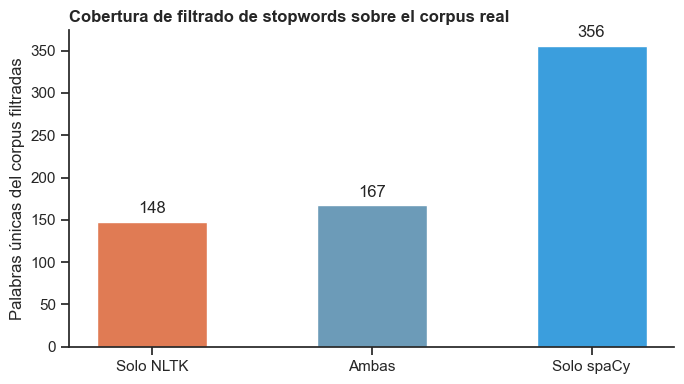

In [48]:
# Hace una comparación por diferencia de conjuntos entre las dos listas:
# * solo_spacy: palabras que spaCy filtra pero NLTK no — las "extra" que spaCy cubre
# * solo_nltk: palabras que NLTK filtra pero spaCy no — casos donde NLTK es más restrictivo
# Muestra solo las primeras 20 de cada grupo (muestra ordenada alfabéticamente) para inspección visual. Esto permite justificar qué lista usar en los análisis de frecuencias y vectorización.

# Comparamos algunas diferencias entre listas.
# Diferencia de conjuntos: qué palabras cubre cada lista que la otra no cubre.
solo_spacy = stopwords_spacy - stopwords_nltk # En spaCy pero no en NLTK
solo_nltk = stopwords_nltk - stopwords_spacy  # En NLTK pero no en spaCy

# Ordenamos y tomamos muestra de 20 para su visualización.
lista_solo_spacy = list(solo_spacy)
lista_solo_spacy = sorted(lista_solo_spacy)
muestra_solo_spacy = lista_solo_spacy[:20]

lista_solo_nltk = list(solo_nltk)
lista_solo_nltk = sorted(lista_solo_nltk)
muestra_solo_nltk = lista_solo_nltk[:20]

print("Ejemplos de palabras que aparecen solo en spaCy:")
display(pd.Series(muestra_solo_spacy))

print("Ejemplos de palabras que aparecen solo en NLTK:")
display(pd.Series(muestra_solo_nltk))

# La diferencia entre listas revela que spaCy cubre principalmente formas conjugadas y variantes morfológicas que NLTK no incluye (por ejemplo: formas verbales auxiliares, pronombres clíticos). NLTK, por su parte, 
# filtra algunas palabras de baja frecuencia que spaCy considera potencialmente relevantes. Dado que el corpus analizado contiene artículos periodísticos con vocabulario técnico, se optó por usar la lista de spaCy 
# como stopword principal: su mayor cobertura morfológica reduce mejor el ruido funcional sin necesidad de configuración adicional.

# Se agrega los totales para reforzar la información:
print(f"Total solo en spaCy: {len(solo_spacy)}")
print(f"Total solo en NLTK:  {len(solo_nltk)}")
print(f"Compartidas:         {len(stopwords_spacy & stopwords_nltk)}")

# Para una mejor comprensión, usamos un gráfico de barras comparativas de cobertura:

# Cuántas palabras únicas del corpus filtra cada lista y cuántas son exclusivas.
labels  = ["Solo NLTK", "Ambas", "Solo spaCy"]
valores = [
    len(filtradas_nltk - filtradas_spacy),
    len(filtradas_nltk & filtradas_spacy),
    len(filtradas_spacy - filtradas_nltk)
]
colores = ["#e07b54", "#6c9bb8", "#3b9edd"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, valores, color=colores, width=0.5)
ax.bar_label(bars, padding=4)
ax.set_ylabel("Palabras únicas del corpus filtradas")
ax.set_title("Cobertura de filtrado de stopwords sobre el corpus real",
             fontweight="bold", loc="left")
sns.despine()
plt.tight_layout()
plt.show()


In [49]:
# Esta función transforma un documento procesado con spaCy (doc) en una versión limpia y reducida del texto.
# Convierte el texto original en una secuencia de lemas útiles para análisis posterior, eliminando:
# puntuación;
# números;
# símbolos;
# stopwords;
# palabras vacías según una lista base.
# Es una función importante porque prepara el texto para conteos, Bag of Words, bigramas y TF-IDF
def texto_contenido_desde_doc(doc, stopwords_base):
    # Esta funcion arma una version reducida del texto.
    # Conserva solo palabras alfabeticas que no sean stopwords.
    tokens = []

    for token in doc:
        # Conservamos solo palabras alfabeticas.
        # Esto descarta puntuacion, numeros, simbolos y otros caracteres no lingüisticos.
        if not token.is_alpha:
            continue
        # Guardamos tanto la forma original como el lema.
        # Revisar ambas formas ayuda a eliminar stopwords aunque aparezcan flexionadas.   
        forma = token.text.lower() 
        lema = normalizar_lemma(token)

        # Si la forma original esta en la lista de stopwords, se descarta.
        if forma in stopwords_base:
            continue
        
         # Si el lema esta en la lista de stopwords, tambien se descarta.
        if lema in stopwords_base:
            continue
        
        # Conservamos el lema porque agrupa variantes de una misma palabra.
        tokens.append(lema)

    # Reconstruimos el texto limpio como una cadena separada por espacios.
    texto_limpio = " ".join(tokens)
    return texto_limpio

# Esta función construye una versión preprocesada del corpus. Conserva únicamente palabras alfabéticas, elimina stopwords y utiliza lemas para reducir variantes morfológicas. 
# Esta transformación permite que los análisis posteriores se concentren en términos con mayor valor semántico y no en formas superficiales o palabras funcionales.

In [50]:
textos_spacy_stop = []

for doc in docs_base:
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_spacy)
    textos_spacy_stop.append(texto_limpio)

df["texto_spacy_stop"] = textos_spacy_stop

display(df[["titulo", "texto_spacy_stop"]].head())

,titulo,texto_spacy_stop
0,La IA necesita un sólido tejido de datos para aportar valor empresarial,inteligencia artificial avanzar rápidamente ámbito empresarial pasar experimentación cotidiano organización desplegar copiloto agente sistema predictivo fin...
1,Por qué nuestra opinión sobre la IA está tan dividida,industria detener index stanford compendio anual resultado tendencia clave oportunidad tomar perspectiva maratón esprint cabo informe año publicado repleto ...
2,OpenAI está volcando todos sus esfuerzos en desarrollar un investigador completamente automatizado,openai reorientar esfuerzo investigación volcar recurso desafío firma san francisco fijar objetivo construir denominar investigador sistema totalmente autom...
3,Cómo Pokémon Go dota a los robots de reparto de una visión del mundo de precisión milimétrica,pokémon go éxito mundial realidad aumentado lanzado niantic empresa escindido google giro ra mastodóntico franquicia pokémon convertir rápidamente fenómeno ...
4,Los 14 términos de IA que marcaron 2025,superinteligencia gente empezar entusiasmar él proponer nombre forma futuro ultrapotente tecnología traer consecuencia utópica distópica humanidad superinte...


In [51]:
textos_nltk_stop = []

for doc in docs_base:
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_nltk)
    textos_nltk_stop.append(texto_limpio)

df["texto_nltk_stop"] = textos_nltk_stop

display(df[["titulo", "texto_nltk_stop"]].head())

,titulo,texto_nltk_stop
0,La IA necesita un sólido tejido de datos para aportar valor empresarial,inteligencia artificial avanzar rápidamente ámbito empresarial pasar experimentación uso cotidiano organización desplegar copiloto agente sistema predictivo...
1,Por qué nuestra opinión sobre la IA está tan dividida,industria detener index stanford compendio anual resultado tendencia clave oportunidad tomar perspectiva maratón esprint fin cabo informe año publicado hoy ...
2,OpenAI está volcando todos sus esfuerzos en desarrollar un investigador completamente automatizado,openai reorientar esfuerzo investigación volcar recurso nuevo gran desafío firma san francisco fijar objetivo construir denominar investigador sistema total...
3,Cómo Pokémon Go dota a los robots de reparto de una visión del mundo de precisión milimétrica,pokémon go primero gran éxito mundial realidad aumentado lanzado niantic empresa escindido google giro ra mastodóntico franquicia pokémon convertir rápidame...
4,Los 14 términos de IA que marcaron 2025,superinteligencia gente empezar entusiasmar él ir proponer nombre forma futuro ultrapotente tecnología poder traer consecuencia utópica distópica humanidad ...


In [52]:
def obtener_top_terminos_por_grupo(dataframe, columna_texto, top_n=10):
    # Esta funcion cuenta los terminos mas frecuentes dentro de cada grupo.
    filas = []

    grupos = dataframe.groupby(COLUMNA_GRUPO)

    for grupo, subconjunto in grupos:
        texto_total = " ".join(subconjunto[columna_texto])
        lista_terminos = texto_total.split()
        contador = Counter(lista_terminos)

        # 'most_common' devuelve pares (termino, frecuencia)
        # ordenados de mayor a menor.
        top = contador.most_common(top_n)

        for termino, frecuencia in top:
            fila = {
                "grupo": grupo,
                "termino": termino,
                "frecuencia": frecuencia,
            }
            filas.append(fila)

    tabla_top = pd.DataFrame(filas)
    return tabla_top

In [53]:
top_spacy_stop = obtener_top_terminos_por_grupo(df, "texto_spacy_stop", top_n=TOP_N)

print("Top con stopwords de spaCy")
display(top_spacy_stop)

Top con stopwords de spaCy


,grupo,termino,frecuencia
0,bbc,él,50
1,bbc,chatbot,29
2,bbc,chatgpt,28
3,bbc,google,26
4,bbc,año,26
5,bbc,empresa,26
6,bbc,inteligencia,24
7,bbc,persona,23
8,bbc,utilizar,21
9,bbc,forma,21


In [54]:
top_nltk_stop = obtener_top_terminos_por_grupo(df, "texto_nltk_stop", top_n=TOP_N)

print("Top con stopwords de NLTK")
display(top_nltk_stop)

Top con stopwords de NLTK


,grupo,termino,frecuencia
0,bbc,poder,78
1,bbc,él,51
2,bbc,decir,42
3,bbc,si,35
4,bbc,chatbot,29
5,bbc,ser,29
6,bbc,chatgpt,28
7,bbc,afirmar,27
8,bbc,google,26
9,bbc,año,26


In [55]:
palabras_a_sacar = {"él", "el", "la", "lo", "los", "las", "si", "sí"}

top_spacy_stop = top_spacy_stop[
    ~top_spacy_stop["termino"].isin(palabras_a_sacar)
]

top_nltk_stop = top_nltk_stop[
    ~top_nltk_stop["termino"].isin(palabras_a_sacar)
]

print("Top con stopwords de spaCy")
display(top_spacy_stop)
print("Top con stopwords de NLTK")
display(top_nltk_stop)

Top con stopwords de spaCy


,grupo,termino,frecuencia
1,bbc,chatbot,29
2,bbc,chatgpt,28
3,bbc,google,26
4,bbc,año,26
5,bbc,empresa,26
6,bbc,inteligencia,24
7,bbc,persona,23
8,bbc,utilizar,21
9,bbc,forma,21
10,bbc,artificial,21


Top con stopwords de NLTK


,grupo,termino,frecuencia
0,bbc,poder,78
2,bbc,decir,42
4,bbc,chatbot,29
5,bbc,ser,29
6,bbc,chatgpt,28
7,bbc,afirmar,27
8,bbc,google,26
9,bbc,año,26
10,bbc,empresa,26
11,bbc,inteligencia,24


Spacy tiene una lista de stopwords más amplia en general, en este corpus no se observan diferencias importantes con respecto a NLTK, ya que los resultados obtenidos son muy similares. Esto indica que ambas listas terminan filtrando palabras parecidas y que es necesario realizar ajustes manuales para mejorar el análisis.

In [56]:
doc_prueba = docs_base[0]
texto_original_prueba = df.loc[0, COLUMNA_TEXTO][:500]

texto_limpio_spacy = texto_contenido_desde_doc(doc_prueba, stopwords_spacy)
texto_limpio_nltk = texto_contenido_desde_doc(doc_prueba, stopwords_nltk)

print("TEXTO ORIGINAL:")
print(texto_original_prueba)

print("\nTEXTO LIMPIO CON spaCy:")
print(texto_limpio_spacy[:500])

print("\nTEXTO LIMPIO CON NLTK:")
print(texto_limpio_nltk[:500])


TEXTO ORIGINAL:
La inteligencia artificial avanza rápidamente en el ámbito empresarial, pasando de la experimentación al uso cotidiano. Las organizaciones están desplegando copilotos, agentes y sistemas predictivos en finanzas, cadenas de suministro, recursos humanos y operaciones con clientes. Para finales de 2025, la mitad de las empresas habrá utilizado IA en al menos tres funciones de negocio, según una encuesta reciente.
ero a medida que la IA se integra en los flujos de trabajo centrales, los líderes empr

TEXTO LIMPIO CON spaCy:
inteligencia artificial avanzar rápidamente ámbito empresarial pasar experimentación cotidiano organización desplegar copiloto agente sistema predictivo finanza cadena suministro recurso humano operación cliente mitad empresa utilizar función negocio encuesta reciente ero medida integrar flujo trabajo central líder empresarial descubrir obstáculo rendimiento modelo capacidad cómputo calidad contexto dato depender sistema introducir esencialmente requisit

Tokens alfabeticos originales: 1469
Tokens luego de limpiar: 681
Porcentaje conservado: 46.4%


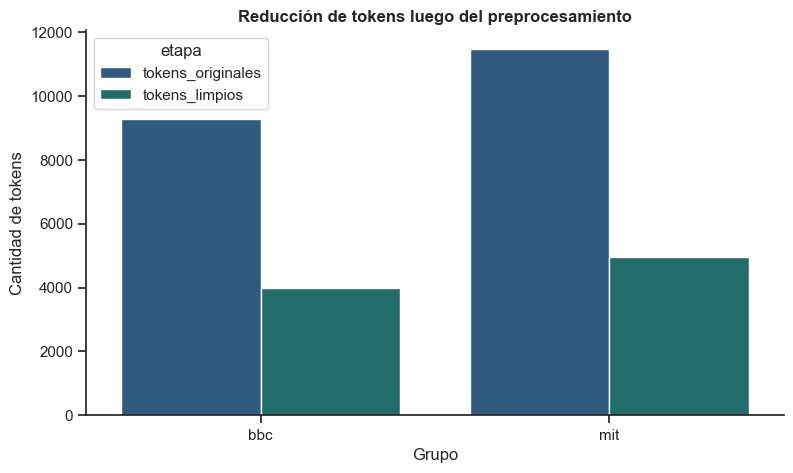

,grupo,tokens_originales,tokens_limpios,reduccion_porcentaje
0,bbc,9279,3981,57.1
1,mit,11489,4945,57.0


In [57]:
# Se aplica linea de código para calcular cuántos tokens conserva:
tokens_originales = [
    token.text.lower()
    for token in docs_base[0]
    if token.is_alpha
]

#tokens_limpios_prueba = texto_limpio_prueba.split()
tokens_limpios_prueba = texto_limpio_spacy.split()

print(f"Tokens alfabeticos originales: {len(tokens_originales)}")
print(f"Tokens luego de limpiar: {len(tokens_limpios_prueba)}")
print(f"Porcentaje conservado: {len(tokens_limpios_prueba) / len(tokens_originales) * 100:.1f}%")

# Aplicación de un gráfico de reducción de tokens por grupo: cuántas palabras alfabéticas había antes y cuántas quedan después de la limpieza.
registros_reduccion = []

for grupo, doc in zip(df[COLUMNA_GRUPO], docs_base):
    tokens_originales = [
        token.text.lower()
        for token in doc
        if token.is_alpha
    ]
    stopwords_base = set(stopwords_spacy)
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_base)
    tokens_limpios = texto_limpio.split()

    registros_reduccion.append({
        "grupo": grupo,
        "tokens_originales": len(tokens_originales),
        "tokens_limpios": len(tokens_limpios)
    })

tabla_reduccion = pd.DataFrame(registros_reduccion)

resumen_reduccion = (
    tabla_reduccion
    .groupby("grupo")
    .sum()
    .reset_index()
)

resumen_reduccion_largo = resumen_reduccion.melt(
    id_vars="grupo",
    value_vars=["tokens_originales", "tokens_limpios"],
    var_name="etapa",
    value_name="cantidad"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=resumen_reduccion_largo,
    x="grupo",
    y="cantidad",
    hue="etapa",
    palette=["#245a8d", "#157a76"]
)

plt.title("Reducción de tokens luego del preprocesamiento", fontweight="bold")
plt.xlabel("Grupo")
plt.ylabel("Cantidad de tokens")

sns.despine()
plt.show()

# NOTA: El gráfico muestra cuántos tokens alfabéticos había originalmente y cuántos quedan después de eliminar stopwords y aplicar lematización. 
# Esta reducción permite disminuir ruido y concentrar el análisis en términos de mayor contenido semántico. Si la reducción es muy desigual entre grupos, debe considerarse como un posible factor metodológico en la comparación.

# Para calcular el porcentaje de reducción por grupo, aplicamos ls siguintes líneas:
resumen_reduccion["reduccion_porcentaje"] = (
    1 - resumen_reduccion["tokens_limpios"] / resumen_reduccion["tokens_originales"]
) * 100

display(resumen_reduccion.round(1))

# En el grupo BBC se eliminó X% de tokens, mientras que en MIT se eliminó Y%. Esto indica cuánto impactó el preprocesamiento en cada subconjunto del corpus.


## 6. Ajuste humano del pipeline

Completen estas celdas. Para aprobar esta parte deben hacer al menos **dos ajustes**:

- **uno lexico**: stopwords propias y/o correcciones de lemas;
- **uno estructural**: `Matcher` y/o `EntityRuler`.

In [58]:
# 1. Borramos el viejo por si acaso
if "entity_ruler" in nlp.pipe_names:
    nlp.remove_pipe("entity_ruler")

# 2. Añadimos el nuevo CON la opción de sobreescritura
config = {"overwrite_ents": True}
ruler = nlp.add_pipe("entity_ruler", before="ner", config=config)

In [59]:
BASE_STOPWORDS = "spacy"  # opciones: "spacy" o "nltk"

STOPWORDS_EXTRA = {
    "año", "años", "vez", "veces", "nuevo", "nueva", "grandes", "gran",
    "parte", "dice", "dijo", "según", "además", "aunque", "sino",
    "todo", "toda", "todos", "puede", "hacer", "haciendo", "hecho",
    "hay", "ser", "sido", "estar", "uso", "tipo", "forma", "caso",
    "gente", "cosa", "cosas", "algo",
    "mucho", "mucha", "muchos", "muchas", "poco", "muy", "más",
    "menos", "mismo", "misma", "cada", "otro", "otra", "otros", "otras"
    "COSA", "PUNTO", "REALMENTE", "DEBER", "PACHOCKI", "ÉL", "EL", "cosa", "él", "el", "ella", "Ã©l", "ellos", "ellas", "elle",
      "mayoria", "pachockl", "pachocki", "simplemente", "pasar", "incluir", "realmente", "deber",
      "forma", "lugar", "puntos", "medida", "medidas", "momento", "semana", "mes", "meses", "semanas", "lugar", "lugares", "punto", "PUNTOS",
      "afirmar", "afirma", "victoria", "viktoria", "mayoria", "dejar"
}

STOPWORDS_EXCLUIR = {
    "riesgo"
}

CORRECCIONES_LEMAS = {
    "ias": "ia",
    "llms": "llm",
    "chatbots": "chatbot",
}

PATRONES_MATCHER = {
    "INTELIGENCIA_ARTIFICIAL": [[{"LOWER": "inteligencia"}, {"LOWER": "artificial"}]],
    "APRENDIZAJE_AUTOMATICO":  [[{"LOWER": "aprendizaje"}, {"LOWER": "automático"}]],
    "MODELO_LENGUAJE":         [[{"LOWER": "modelo"}, {"LOWER": "de"}, {"LOWER": "lenguaje"}]],
}

PATRONES_ENTIDADES = [
    {"label": "ORG",  "pattern": "ChatGPT"},
    {"label": "ORG",  "pattern": "Mythos"},
    {"label": "ORG",  "pattern": "Anthropic"},
    {"label": "ORG",  "pattern": "Amazon"},
    {"label": "ORG",  "pattern": "Facebook"},
    {"label": "ORG",  "pattern": "Niantic Spatial"},
    {"label": "ORG",  "pattern": "Google Deepmind"},
    {"label": "ORG",  "pattern": "OpenAI"},
    {"label": "ORG",  "pattern": "Anthropic"},
    {"label": "ORG",  "pattern": "MIT Technology Review"},
    {"label": "ORG",  "pattern": "BBC"},
    {"label": "MISC", "pattern": "ChatGPT"},
    {"label": "MISC", "pattern": "LLM"},
    {"label": "MISC", "pattern": "LLMs"},
    {"label": "PER",  "pattern": "Yann LeCun"},
    {"label": "MISC", "pattern": "Pokémon Go"},
  

]

# NOTA: Luego de comparar las listas de stopwords de spaCy y NLTK, se eligió spaCy como base por su mayor cobertura. 
# Sin embargo, se realizaron ajustes manuales para adaptar el pipeline al corpus. Estos ajustes incluyen la eliminación de términos muy frecuentes del dominio, correcciones de lemas y patrones estructurales 
# para detectar expresiones relevantes como "inteligencia artificial" o "modelo de lenguaje".

# NOTA: Estos ajustes son necesarios porque los modelos generales de PLN no siempre reconocen correctamente expresiones técnicas, siglas, productos o entidades recientes vinculadas con inteligencia artificial.

     

In [87]:
# Prueba rápida
doc_prueba = nlp("OpenAI presentó un nuevo modelo.")
for ent in doc_prueba.ents:
    print(f"Entidad: {ent.text} | Etiqueta: {ent.label_}")

Entidad: OpenAI | Etiqueta: ORG


c:\Users\vpena\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\spacy\pipeline\entityruler.py:365: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))


In [61]:
# Elegimos una lista base de stopwords.
if BASE_STOPWORDS == "spacy":
    stopwords_base = set(stopwords_spacy)
else:
    stopwords_base = set(stopwords_nltk)

# Sumamos palabras que queremos tratar como stopwords.
stopwords_ajustadas = set(stopwords_base)

for palabra in STOPWORDS_EXTRA:
    stopwords_ajustadas.add(palabra)

# Quitamos palabras que no queremos perder en el analisis.
for palabra in STOPWORDS_EXCLUIR:
    if palabra in stopwords_ajustadas:
        stopwords_ajustadas.remove(palabra)

print(f"Lista base elegida: {BASE_STOPWORDS}")
print(f"Stopwords ajustadas: {len(stopwords_ajustadas)}")

# NOTA: Se eligió una lista base de stopwords y se ajustó manualmente según las características del corpus. Esta decisión es metodológica: no existe una lista universal de palabras vacías. 
# Algunas palabras pueden ser irrelevantes en un corpus, pero significativas en otro.
# NOTA: Se eligió spaCy como lista base porque ofrece mayor cobertura morfológica que NLTK. 
# Esto ayuda a reducir formas funcionales que podrían permanecer en el corpus y afectar los rankings de frecuencia.
# Nota: Se agregaron términos propios del dominio que aparecen de forma muy frecuente y no necesariamente diferencian los grupos. 
# Esta decisión busca que los análisis posteriores destaquen vocabulario más específico.

Lista base elegida: spacy
Stopwords ajustadas: 565


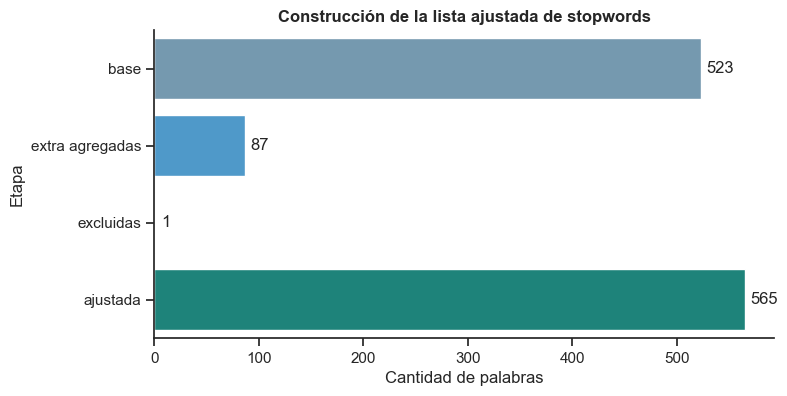

In [62]:
# Utilizamos el siguiente grafico para visualizar cómo cambia el tamaño de la lista antes y después del ajuste:
datos_stopwords = pd.DataFrame({
    "lista": ["base", "extra agregadas", "excluidas", "ajustada"],
    "cantidad": [
        len(stopwords_base),
        len(STOPWORDS_EXTRA),
        len(STOPWORDS_EXCLUIR),
        len(stopwords_ajustadas)
    ]
})

plt.figure(figsize=(8, 4))

sns.barplot(
    data=datos_stopwords,
    x="cantidad",
    y="lista",
    hue="lista",
    palette=["#6c9bb8", "#3b9edd", "#e07b54", "#0d9488"],
    legend=False
)

plt.title("Construcción de la lista ajustada de stopwords", fontweight="bold")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Etapa")

for contenedor in plt.gca().containers:
    plt.gca().bar_label(contenedor, padding=4)

sns.despine()
plt.show()

# NOTA: El gráfico muestra cómo se construyó la lista final de stopwords a partir de una lista base y ajustes manuales. 
# Esta visualización permite transparentar el impacto de las decisiones humanas en el preprocesamiento del corpus.

In [63]:
# Cargamos un pipeline nuevo para no mezclar este ajuste con el analisis anterior.
nlp_ajustado = spacy.load(MODELO_SPACY)
nlp_ajustado.vocab["él"].is_stop = True

# Marcamos como stopword cada palabra agregada a mano.
for palabra in STOPWORDS_EXTRA:
    palabra_normalizada = palabra.lower().strip()
    nlp_ajustado.vocab[palabra].is_stop = True

# Desmarcamos las palabras que queremos conservar.
for palabra in STOPWORDS_EXCLUIR:
    palabra_normalizada = palabra.lower().strip()
    nlp_ajustado.vocab[palabra].is_stop = False

print("Pipeline ajustado cargado.")
print(f"Stopwords extra marcadas: {sorted(STOPWORDS_EXTRA)}")
print(f"Stopwords excluidas: {sorted(STOPWORDS_EXCLUIR)}")

# NOTA: Se creó un pipeline ajustado para aplicar las decisiones manuales de preprocesamiento sin modificar el pipeline base. Esto permite distinguir entre el análisis automático inicial y el análisis adaptado al corpus. 
# En este pipeline se marcaron nuevas stopwords y se conservaron palabras que podían tener valor analítico.
# NOTA: Esta separación es importante porque permite mantener trazabilidad: primero se observa cómo trabaja el modelo base y luego se documenta qué modificaciones humanas se aplican.


Pipeline ajustado cargado.
Stopwords extra marcadas: ['DEBER', 'EL', 'PACHOCKI', 'PUNTO', 'PUNTOS', 'REALMENTE', 'además', 'afirma', 'afirmar', 'algo', 'aunque', 'año', 'años', 'cada', 'caso', 'cosa', 'cosas', 'deber', 'dejar', 'dice', 'dijo', 'el', 'ella', 'ellas', 'elle', 'ellos', 'estar', 'forma', 'gente', 'gran', 'grandes', 'hacer', 'haciendo', 'hay', 'hecho', 'incluir', 'lugar', 'lugares', 'mayoria', 'medida', 'medidas', 'menos', 'mes', 'meses', 'misma', 'mismo', 'momento', 'mucha', 'muchas', 'mucho', 'muchos', 'muy', 'más', 'nueva', 'nuevo', 'otra', 'otrasCOSA', 'otro', 'otros', 'pachocki', 'pachockl', 'parte', 'pasar', 'poco', 'puede', 'punto', 'puntos', 'realmente', 'según', 'semana', 'semanas', 'ser', 'sido', 'simplemente', 'sino', 'tipo', 'toda', 'todo', 'todos', 'uso', 'veces', 'vez', 'victoria', 'viktoria', 'Ã©l', 'ÉL', 'él']
Stopwords excluidas: ['riesgo']


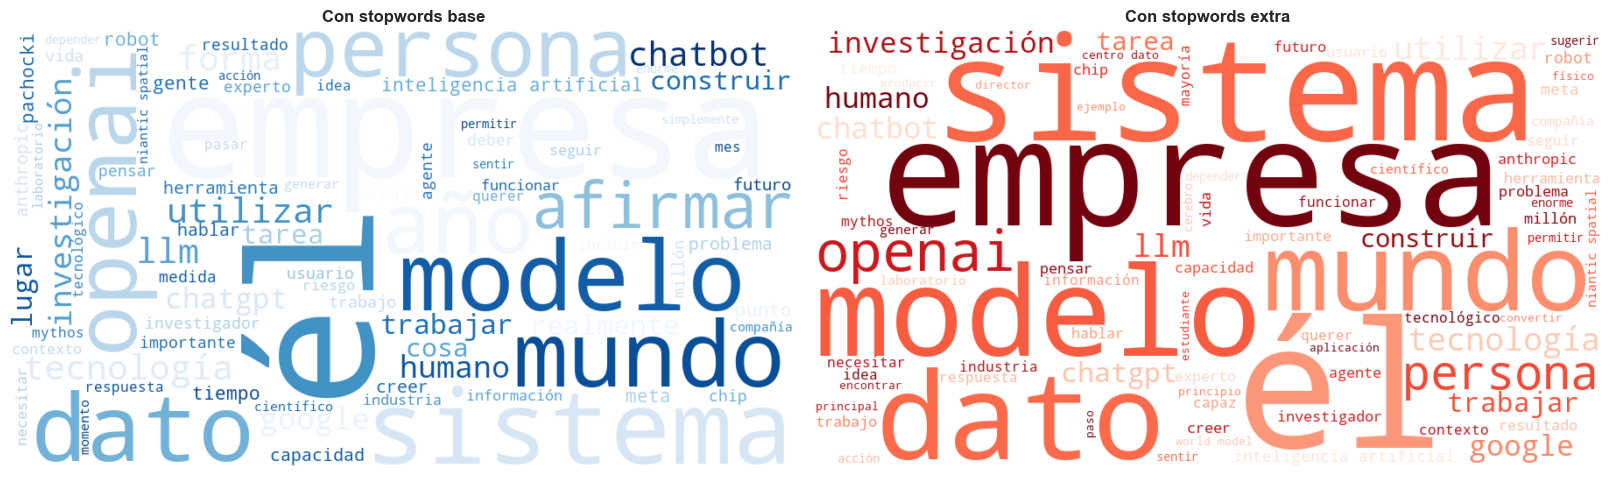

In [64]:
#extraaaa
# Lista base sin stopwords extra.
texto_con_base = []

for doc in docs_base:
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_base)
    texto_con_base.append(texto_limpio)

texto_con_base = " ".join(texto_con_base)

# Lista ajustada con stopwords extra incluidas.
texto_con_ajustadas = []

for doc in docs_base:
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_ajustadas)
    texto_con_ajustadas.append(texto_limpio)

texto_con_ajustadas = " ".join(texto_con_ajustadas)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud_base = WordCloud(
    width=900,
    height=500,
    background_color="white",
    colormap="Blues",
    max_words=80
).generate(texto_con_base)

wordcloud_ajustada = WordCloud(
    width=900,
    height=500,
    background_color="white",
    colormap="Reds",
    max_words=80
).generate(texto_con_ajustadas)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

axes[0].imshow(wordcloud_base, interpolation="bilinear")
axes[0].set_title("Con stopwords base", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(wordcloud_ajustada, interpolation="bilinear")
axes[1].set_title("Con stopwords extra", fontweight="bold")
axes[1].axis("off")

plt.show()

In [65]:
# 'EntityRuler' sirve para forzar entidades que el modelo no reconoce bien.
if PATRONES_ENTIDADES:
    ruler = nlp_ajustado.add_pipe("entity_ruler", config={"overwrite_ents": True}, before="ner")
    ruler.add_patterns(PATRONES_ENTIDADES)
    print("EntityRuler agregado.")
else:
    print("No se agregaron patrones de entidades.")

EntityRuler agregado.


In [66]:
# 'Matcher' sirve para detectar patrones de varias palabras.
matcher = Matcher(nlp_ajustado.vocab)

for nombre, patrones in PATRONES_MATCHER.items():
    matcher.add(nombre, patrones)

print("Matcher preparado.")

# Se incorporó un Matcher para detectar expresiones relevantes de varias palabras. Esta herramienta permite capturar conceptos que no deberían analizarse solo como términos aislados, como "inteligencia artificial" o "modelo de lenguaje". 
# De este modo, el análisis conserva unidades discursivas más cercanas al significado real del texto.

Matcher preparado.


In [67]:
def lema_ajustado(token):
    # Si la forma aparece en el diccionario manual, usamos esa correccion.
    forma = token.text.lower()

    if forma in CORRECCIONES_LEMAS:
        return CORRECCIONES_LEMAS[forma]

    return normalizar_lemma(token)

# Volvemos a procesar el corpus con el pipeline ajustado.
textos_corpus_ajustado = df[COLUMNA_TEXTO].tolist()
docs_ajustados = list(nlp_ajustado.pipe(textos_corpus_ajustado))

print(f"Documentos procesados con el pipeline ajustado: {len(docs_ajustados)}")

Documentos procesados con el pipeline ajustado: 12


In [68]:
registros_matcher = []
textos_modelo = []
entidades_ajustadas = []

for doc_id, doc in zip(df["id"], docs_ajustados):
    contenido = []

    for token in doc:
        if not token.is_alpha:
            continue

        forma = token.text.lower()
        lema = lema_ajustado(token)

        if forma in stopwords_ajustadas:
            continue

        if lema in stopwords_ajustadas:
            continue

        contenido.append(lema)

    texto_limpio = " ".join(contenido)
    textos_modelo.append(texto_limpio)

    lista_entidades = []
    for ent in doc.ents:
        lista_entidades.append((ent.text, ent.label_))
    entidades_ajustadas.append(lista_entidades)

    coincidencias = matcher(doc)
    for match_id, inicio, fin in coincidencias:
        patron = nlp_ajustado.vocab.strings[match_id]
        span = doc[inicio:fin].text
        registros_matcher.append({
            "id": doc_id,
            "patron": patron,
            "span": span,
        })

In [69]:
df["texto_modelo"] = textos_modelo
df["entidades_ajustadas"] = entidades_ajustadas

tokens_por_texto = df["texto_modelo"].str.split()
cantidad_tokens = tokens_por_texto.str.len()
df["num_tokens_modelo"] = cantidad_tokens

columnas_revision = ["titulo", COLUMNA_GRUPO, "texto_modelo", "num_tokens_modelo"]
display(df[columnas_revision].head(12))

,titulo,grupo_comparacion,texto_modelo,num_tokens_modelo
0,La IA necesita un sólido tejido de datos para aportar valor empresarial,mit,inteligencia artificial avanzar rápidamente ámbito empresarial experimentación cotidiano organización desplegar copiloto agente sistema predictivo finanza c...,655
1,Por qué nuestra opinión sobre la IA está tan dividida,mit,industria detener index stanford compendio anual resultado tendencia clave oportunidad tomar perspectiva maratón esprint cabo informe publicado repleto esta...,303
2,OpenAI está volcando todos sus esfuerzos en desarrollar un investigador completamente automatizado,mit,openai reorientar esfuerzo investigación volcar recurso desafío firma san francisco fijar objetivo construir denominar investigador sistema totalmente autom...,953
3,Cómo Pokémon Go dota a los robots de reparto de una visión del mundo de precisión milimétrica,mit,pokémon go éxito mundial realidad aumentado lanzado niantic empresa escindido google giro ra mastodóntico franquicia pokémon convertir rápidamente fenómeno ...,697
4,Los 14 términos de IA que marcaron 2025,mit,superinteligencia empezar entusiasmar él proponer nombre futuro ultrapotente tecnología traer consecuencia utópica distópica humanidad superinteligencia tér...,1011
5,"Yann LeCun: ""Los LLM manipulan muy bien el lenguaje, pero la parte realmente difícil es entender el mundo real""",mit,yann lecun ganador premio turing principal investigador inteligencia artificial tiempo figura mundo tecnológico creer actual obsesión industria modelo lengu...,1047
6,Por qué los chatbots de IA pueden estar volviéndote más tonto,bbc,investigador advertir modelo lenguaje asumir tarea cognitiva costo pagar externalización mental investigadora nataliya kosmyna buscar pasant notar carta pre...,804
7,"Mythos, el nuevo modelo de IA de Anthropic que preocupa a gobiernos y bancos por su gran potencia",bbc,mundo inteligencia artificial ascua afirmación empresa líder anthropic relación modelo claude mythos compañía asegurar descubrir herramienta superar humano ...,443
8,"Quiénes son los ""arquitectos de la IA"", elegidos Persona del Año por la revista Time",bbc,persona revista time cambio publicación reconocer arquitecto inteligencia artificial figura influyente director ejecutivo nvidia jensen huang director meta ...,347
9,La contradicción en el corazón de la burbuja de la IA (y el temor por los efectos económicos de un posible estallido),bbc,sundar pichai hermético ceo google invitar recorrido googleplex sede california sendero recorrer edificio esqueleto gigante dinosaurio cancha voleibol playa...,991


In [70]:
df_matcher = pd.DataFrame(registros_matcher)

if not df_matcher.empty:
    display(df_matcher.head(20))
else:
    print("No se registraron coincidencias de Matcher.")

,id,patron,span
0,1,INTELIGENCIA_ARTIFICIAL,inteligencia artificial
1,3,INTELIGENCIA_ARTIFICIAL,inteligencia artificial
2,5,INTELIGENCIA_ARTIFICIAL,inteligencia artificial
3,5,INTELIGENCIA_ARTIFICIAL,inteligencia artificial
4,6,INTELIGENCIA_ARTIFICIAL,inteligencia artificial
5,6,INTELIGENCIA_ARTIFICIAL,inteligencia artificial
6,7,INTELIGENCIA_ARTIFICIAL,inteligencia artificial
7,7,INTELIGENCIA_ARTIFICIAL,inteligencia artificial
8,7,INTELIGENCIA_ARTIFICIAL,inteligencia artificial
9,7,INTELIGENCIA_ARTIFICIAL,inteligencia artificial


Agreguen una celda Markdown nueva y expliquen en pocas lineas:

- que problema detectaron;
- que cambiaron;
- que efecto tuvo ese cambio en los resultados.

### Ajuste humano del pipeline

#### ¿Qué problema detectaron?
Se detectó que el procesamiento automático de `spaCy` no resolvía todos los casos de forma adecuada para este corpus. Algunas palabras poco informativas seguían apareciendo en los resultados, y ciertas entidades o expresiones propias del tema de inteligencia artificial podían quedar mal clasificadas o no ser reconocidas correctamente.
Por ejemplo, términos como IA, inteligencia artificial, ChatGPT, OpenAI o nombres de empresas tecnológicas pueden ser centrales para el análisis, pero el modelo puede clasificarlos de manera inconsistente o agruparlos bajo etiquetas demasiado generales como MISC

#### ¿Qué cambiaron?

Se realizaron ajustes manuales sobre el pipeline para adaptarlo mejor al corpus. Excluimos una palabra que nos pareció importante: "riesgo" porque pensamos que es central sobre el discurso de las consecuencias de la IA. También corregimos lo que serían los lemas de términos que son técnicos como  "llms" y "chatbots" y forzamos a que se reconozcan entidades como Anthropic con Entity ruler. Con el Matcher  unificamos la "inteligencia artificial" como una sola unidad en lugar de dos palabras sueltas.

#### ¿Qué efecto tuvo ese cambio en los resultados?

El ajuste permitió obtener una versión más limpia y analíticamente útil del corpus. El texto resultante muestra un vocabulario específico al dominio y a simple vista se observa la diferencia entre grupos: el MIT usa mayor cantidad de términos técnicos y  la BBC  usa términos relacionados al impacto humano y alerta.


## 7. Representaciones sparse

A partir de `texto_modelo`, comparen frecuencias, distintividad y asociaciones.

**Vocabulario de esta seccion**

- **vectorizador**: herramienta que convierte texto en numeros;
- **vocabulario**: conjunto de terminos que el vectorizador conserva;
- **matriz**: tabla numerica que representa los textos;
- **bigrama**: par de palabras consecutivas;
- **Bag of Words**: representacion basada en conteos;
- **TF-IDF**: representacion que pondera que tan distintivo es un termino;
- **fit**: paso en el que el vectorizador aprende el vocabulario;
- **transform**: paso en el que el vectorizador convierte textos en numeros;
- **min_df**: frecuencia minima por documento. Si sube, el modelo descarta terminos raros;
- **max_df**: frecuencia maxima permitida para conservar un termino. Si baja, el modelo descarta terminos demasiado comunes.

In [71]:
# Limpiar texto_modelo final, por seguridad
palabras_prohibidas = {"el", "él", "la", "lo", "los", "las", "ella", "ellos", "ellas", "si", "sí"}

df["texto_modelo"] = df["texto_modelo"].apply(
    lambda texto: " ".join(
        palabra for palabra in texto.split()
        if palabra not in palabras_prohibidas
    )
)

Antes de vectorizar, se aplicó una limpieza final sobre texto_modelo para eliminar pronombres y artículos que seguían apareciendo en los rankings, como “él”. Esto evita que términos poco informativos afecten las frecuencias y el TF-IDF.

In [72]:
## 7. Representaciones Sparse: BoW vs TF-IDF

# 1. Definición de parámetros
# ngram_range=(1, 2): extrae palabras sueltas y bigramas
params = {
    'min_df':1,
    'ngram_range': (1, 2), 
    'strip_accents': 'unicode'
}

# 2. Inicialización de vectorizadores
vectorizador_bow = CountVectorizer(**params)
vectorizador_tfidf = TfidfVectorizer(**params)

# 3. Ajuste (fit) y Transformación (transform)
# 'fit' aprende el vocabulario; 'transform' crea la matriz numérica
textos_input = df["texto_modelo"]

matriz_bow = vectorizador_bow.fit_transform(textos_input)
matriz_tfidf = vectorizador_tfidf.fit_transform(textos_input)

# 4. Conversión a DataFrame para análisis fácil
df_frecuencias = pd.DataFrame(
    matriz_bow.toarray(), 
    columns=vectorizador_bow.get_feature_names_out()
)
df_especificidad = pd.DataFrame(
    matriz_tfidf.toarray(), 
    columns=vectorizador_tfidf.get_feature_names_out()
)

# Añadimos la columna de grupo para agrupar los resultados
df_frecuencias[COLUMNA_GRUPO] = df[COLUMNA_GRUPO].values
df_especificidad[COLUMNA_GRUPO] = df[COLUMNA_GRUPO].values

print(f"Vocabulario aprendido: {len(vectorizador_bow.get_feature_names_out())} términos.")

Vocabulario aprendido: 10574 términos.


En este bloque se construyen representaciones numéricas del corpus a partir de la columna `texto_modelo`, que ya fue limpiada y ajustada en el punto 6.

Se aplican dos enfoques:
- Bag of Words (BoW): cuenta cuántas veces aparece cada término.
- TF-IDF: pondera qué tan distintivo es un término en cada documento.

Se configuran dos parámetros clave:
- `min_df=2`: elimina palabras que aparecen en un solo texto, reduciendo ruido.
- `ngram_range=(1,2)`: incluye tanto palabras individuales como combinaciones de dos palabras (bigramas), lo que permite capturar expresiones como "inteligencia artificial".

El modelo aprendio un vocabulario de 1217 términos, lo que indica una buena diversidad léxica luego del preprocesamiento.

Además, se agregan los grupos (BBC vs MIT) para poder comparar cómo varían las frecuencias y la relevancia de los términos entre ambos conjuntos de textos.

C:\Users\vpena\AppData\Local\Temp\ipykernel_67452\2505136751.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_w.values, y=top_w.index, ax=axes[i, 0], palette="Blues_d")
C:\Users\vpena\AppData\Local\Temp\ipykernel_67452\2505136751.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_t.values, y=top_t.index, ax=axes[i, 1], palette="Reds_d")
C:\Users\vpena\AppData\Local\Temp\ipykernel_67452\2505136751.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_w.values, y=top_w.index, ax=axes[i, 0], palette="Blues_d")
C:\Users\vp

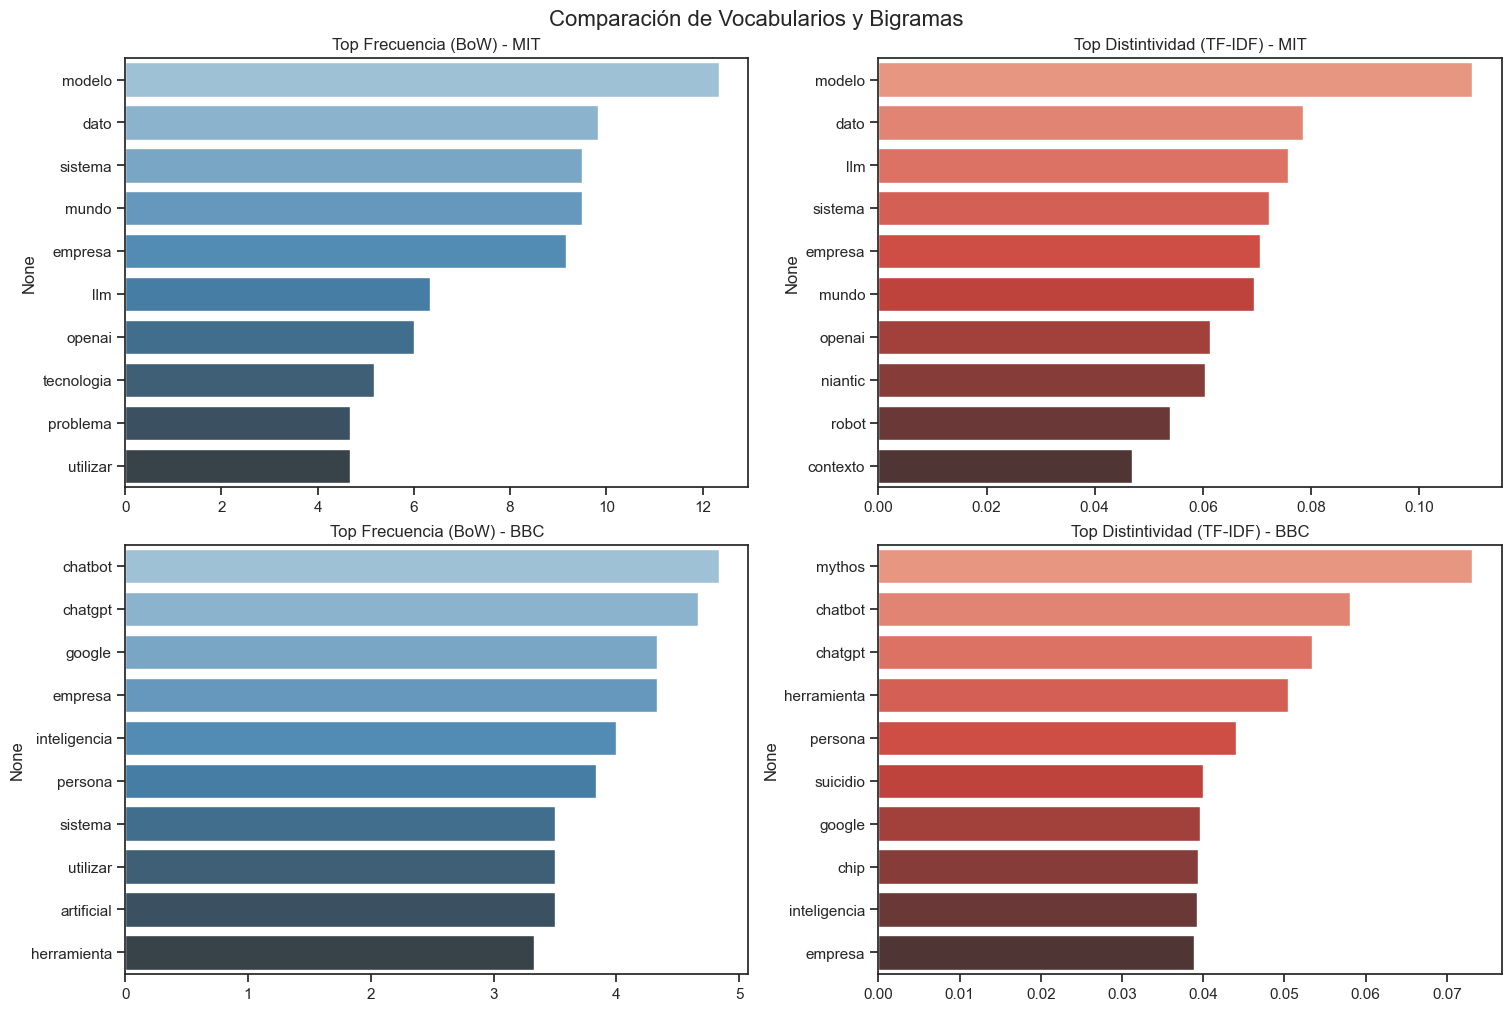

In [73]:
# 5. Obtención de términos destacados por grupo
def obtener_top_df(data_frame, grupo, top_n=10):
    subset = data_frame[data_frame[COLUMNA_GRUPO] == grupo].drop(columns=[COLUMNA_GRUPO])
    return subset.mean().sort_values(ascending=False).head(top_n)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

for i, grupo in enumerate(df[COLUMNA_GRUPO].unique()):
    # Gráfico de Frecuencia (BoW)
    top_w = obtener_top_df(df_frecuencias, grupo)
    sns.barplot(x=top_w.values, y=top_w.index, ax=axes[i, 0], palette="Blues_d")
    axes[i, 0].set_title(f"Top Frecuencia (BoW) - {grupo.upper()}")

    # Gráfico de Distintividad (TF-IDF)
    top_t = obtener_top_df(df_especificidad, grupo)
    sns.barplot(x=top_t.values, y=top_t.index, ax=axes[i, 1], palette="Reds_d")
    axes[i, 1].set_title(f"Top Distintividad (TF-IDF) - {grupo.upper()}")

plt.suptitle("Comparación de Vocabularios y Bigramas", fontsize=16)
plt.show()

En estos gráficos se comparan las palabras más frecuentes (BoW) y las más distintivas (TF-IDF) para cada grupo. Se puede ver que en BoW aparecen palabras que se repiten mucho como “empresa”, pero que no necesariamente diferencian los textos.

En cambio, en TF-IDF aparecen palabras más específicas como “llm”, “robot” o “herramienta”, que ayudan a entender mejor de qué trata cada grupo.

También se nota que MIT usa términos más técnicos, mientras que BBC tiene un lenguaje más general y orientado a aplicaciones.

In [74]:
top_terminos_modelo = obtener_top_terminos_por_grupo(df, "texto_modelo", top_n=TOP_N)

print("Terminos frecuentes por grupo")
display(top_terminos_modelo)

Terminos frecuentes por grupo


,grupo,termino,frecuencia
0,bbc,chatbot,29
1,bbc,chatgpt,28
2,bbc,google,26
3,bbc,empresa,26
4,bbc,inteligencia,24
5,bbc,persona,23
6,bbc,utilizar,21
7,bbc,artificial,21
8,bbc,sistema,21
9,bbc,modelo,20


A partir de los términos más frecuentes por grupo se observan diferencias en el vocabulario utilizado.

En el caso de BBC aparecen términos como “chatbot”, “chatgpt”, “google”, “persona” e “inteligencia”, lo que sugiere un enfoque más orientado al uso cotidiano y al impacto en las personas.

En cambio, en MIT predominan términos como “modelo”, “dato”, “sistema”, “tecnología” y “llm”, indicando un enfoque más técnico y centrado en el funcionamiento de los sistemas de inteligencia artificial.

In [75]:
def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    # Esta funcion convierte una matriz numerica en una tabla legible.
    # 'toarray' pasa de una matriz dispersa a una matriz comun.
    matriz_densa = matriz.toarray()
    tabla = pd.DataFrame(matriz_densa, columns=nombres_columnas, index=nombres_filas)
    return tabla

# 'CountVectorizer' cuenta ocurrencias de terminos o n-gramas.
# 'lowercase=False' significa que el vectorizador no cambiara mayusculas por minusculas.
# En este notebook preferimos controlar esa normalizacion antes.
usar_minusculas = False

# 'ngram_range=(2, 2)' significa que vamos a trabajar solo con bigramas.
rango_ngramas = (2, 2)

# 'min_df=1' significa que conservamos terminos que aparecen al menos en 1 documento.
frecuencia_minima_documento = 1

vectorizador_bigramas = CountVectorizer(
    lowercase=usar_minusculas,
    ngram_range=rango_ngramas,
    min_df=frecuencia_minima_documento,
)

# 'fit' aprende el vocabulario de bigramas a partir de los textos.
vectorizador_bigramas.fit(df["texto_modelo"])

# 'transform' convierte los textos en una matriz numerica usando ese vocabulario.
matriz_bigramas = vectorizador_bigramas.transform(df["texto_modelo"])

# 'get_feature_names_out' devuelve la lista de terminos aprendidos por el vectorizador.
nombres_bigramas = vectorizador_bigramas.get_feature_names_out()
ids_documentos = df["id"]

tabla_bigramas_docs = matriz_a_dataframe(matriz_bigramas, nombres_bigramas, ids_documentos)
display(tabla_bigramas_docs.head())

,abarcar amplio,abarcar infraestructura,abiertamente llm,abierto ajustar,abierto cerrado,abierto chino,abierto criticar,abierto entrenar,abierto igualar,abierto lamentablemente,...,único repositorio,útil comentar,útil conducción,útil créeme,útil especialmente,útil impresionante,útil mundo,útil necesitar,útil openai,útil servil
id,,,,,,,,,,,,,,,,,,,,,
1,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
5,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1


In [76]:
# Sumamos los bigramas dentro de cada grupo.
tabla_bigramas_con_grupo = tabla_bigramas_docs.copy()
tabla_bigramas_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

# 'sum' agrega los conteos de cada columna dentro de cada grupo.
bigramas_agrupados = tabla_bigramas_con_grupo.groupby("grupo").sum()

# '.T' transpone la tabla: filas pasan a columnas y columnas a filas.
bigramas_por_grupo = bigramas_agrupados.T

filas_bigramas = []

for grupo in bigramas_por_grupo.columns:
    serie_grupo = bigramas_por_grupo[grupo]
    # 'sort_values' ordena de mayor a menor.
    serie_ordenada = serie_grupo.sort_values(ascending=False)

    # 'head(TOP_N)' conserva solo los primeros N casos.
    top_grupo = serie_ordenada.head(TOP_N)

    for bigrama, frecuencia in top_grupo.items():
        filas_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(filas_bigramas)
display(top_bigramas)

,grupo,bigrama,frecuencia
0,bbc,inteligencia artificial,20
1,bbc,modelo lenguaje,6
2,bbc,salud mental,5
3,bbc,quitar vida,5
4,bbc,reino unido,5
5,bbc,utilizar herramienta,5
6,bbc,silicon valley,4
7,bbc,centro dato,4
8,bbc,ayuda profesional,4
9,bbc,pensamiento suicida,4


El análisis de bigramas permite identificar combinaciones de palabras que aparecen juntas con frecuencia, lo que aporta más contexto que analizar palabras individuales.

En el caso de BBC, aparecen expresiones como “inteligencia artificial”, "quitar vida", “salud mental”, “pensamiento suicida”, "deterioro cognitivo"  o “reino unido”, lo que sugiere un enfoque más orientado a temas sociales, impacto en personas y contexto real.

En cambio, en MIT predominan bigramas como “modelo razonamiento”, “entrenar modelo”, “resolver problema” o “cadena suministro”, indicando un enfoque más técnico y centrado en el desarrollo y funcionamiento de sistemas de inteligencia artificial.

Además, algunos bigramas como “centro dato” aparecen en ambos grupos, lo que muestra temas en común, pero con distinto peso.

In [77]:
# Bag of Words cuenta volumen.
usar_minusculas_bow = False

# 'min_df=1' conserva terminos que aparecen al menos en 1 documento.
min_df_bow = 1

# 'max_df=0.95' descarta terminos que aparecen en mas del 95% de los documentos.
# Sirve para quitar palabras demasiado comunes y poco distintivas.
max_df_bow = 0.95

vectorizador_bow = CountVectorizer(
    lowercase=usar_minusculas_bow,
    min_df=min_df_bow,
    max_df=max_df_bow,
)

# 'fit' aprende que terminos formaran parte del vocabulario.
vectorizador_bow.fit(df["texto_modelo"])

# 'transform' convierte los textos en conteos numericos.
matriz_bow = vectorizador_bow.transform(df["texto_modelo"])

vocabulario_bow = vectorizador_bow.get_feature_names_out()
tabla_bow_docs = matriz_a_dataframe(matriz_bow, vocabulario_bow, df["id"])

tabla_bow_con_grupo = tabla_bow_docs.copy()
tabla_bow_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

# 'groupby' agrupa filas que comparten el mismo valor de grupo.
agrupado_bow = tabla_bow_con_grupo.groupby("grupo")

# 'mean' calcula el promedio por columna dentro de cada grupo.
tabla_bow_grupos = agrupado_bow.mean()

display(tabla_bow_grupos.head())

,abarcar,abiertamente,abierto,abordar,aborden,abreviaturar,abril,abrir,abrumado,absolutamente,...,ébola,época,ética,éxito,índice,ír,últimamente,únicamente,único,útil
grupo,,,,,,,,,,,,,,,,,,,,,
bbc,0.000000,0.000000,0.166667,0.0,0.166667,0.000000,0.333333,0.166667,0.000000,0.166667,...,0.166667,0.5,0.333333,0.000000,0.166667,0.166667,0.000000,0.333333,0.333333,0.166667
mit,0.333333,0.166667,2.166667,1.0,0.000000,0.166667,0.166667,0.166667,0.166667,0.666667,...,0.000000,0.0,0.000000,0.833333,0.333333,0.166667,0.166667,0.000000,0.833333,1.333333


In [78]:
# TF-IDF no mide solo frecuencia. Mide que tan distintivo es un termino.
usar_minusculas_tfidf = False

# Igual que antes, 'min_df=1' conserva terminos presentes al menos en 1 documento.
min_df_tfidf = 1

# Igual que antes, 'max_df=0.95' descarta terminos demasiado comunes.
max_df_tfidf = 0.95

vectorizador_tfidf = TfidfVectorizer(
    lowercase=usar_minusculas_tfidf,
    min_df=min_df_tfidf,
    max_df=max_df_tfidf,
)

# 'fit' aprende el vocabulario y las ponderaciones necesarias.
vectorizador_tfidf.fit(df["texto_modelo"])

# 'transform' convierte los textos en una matriz numerica usando ese aprendizaje.
matriz_tfidf = vectorizador_tfidf.transform(df["texto_modelo"])

vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()
tabla_tfidf_docs = matriz_a_dataframe(matriz_tfidf, vocabulario_tfidf, df["id"])

tabla_tfidf_con_grupo = tabla_tfidf_docs.copy()
tabla_tfidf_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

agrupado_tfidf = tabla_tfidf_con_grupo.groupby("grupo")
tabla_tfidf_grupos = agrupado_tfidf.mean()

display(tabla_tfidf_grupos.head())

,abarcar,abiertamente,abierto,abordar,aborden,abreviaturar,abril,abrir,abrumado,absolutamente,...,ébola,época,ética,éxito,índice,ír,últimamente,únicamente,único,útil
grupo,,,,,,,,,,,,,,,,,,,,,
bbc,0.000000,0.000000,0.002951,0.000000,0.004334,0.000000,0.010669,0.005334,0.000000,0.002829,...,0.008926,0.014901,0.014288,0.000000,0.003617,0.003722,0.000000,0.00734,0.005202,0.002829
mit,0.007477,0.004087,0.041187,0.021496,0.000000,0.004649,0.003993,0.003993,0.010316,0.014368,...,0.000000,0.000000,0.000000,0.014378,0.017719,0.003388,0.004087,0.00000,0.020639,0.020609


In [79]:
def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    filas = []

    # 'iterrows' recorre la tabla fila por fila.
    for grupo, serie in tabla_matriz.iterrows():
        serie_positivos = serie[serie > 0]

        # Ordenamos de mayor a menor para ver primero los terminos mas fuertes.
        serie_ordenada = serie_positivos.sort_values(ascending=False)

        # 'head(top_n)' conserva los primeros N terminos.
        top = serie_ordenada.head(top_n)

        for termino, valor in top.items():
            filas.append({
                "grupo": grupo,
                "termino": termino,
                nombre_valor: round(float(valor), 4),
            })

    return pd.DataFrame(filas)

top_bow = extraer_top_por_grupo(tabla_bow_grupos, top_n=TOP_N, nombre_valor="frecuencia_media")
top_tfidf = extraer_top_por_grupo(tabla_tfidf_grupos, top_n=TOP_N, nombre_valor="tfidf_medio")

print("Top por grupo segun Bag of Words")
display(top_bow)

print("Top por grupo segun TF-IDF")
display(top_tfidf)

Top por grupo segun Bag of Words


,grupo,termino,frecuencia_media
0,bbc,chatbot,4.8333
1,bbc,chatgpt,4.6667
2,bbc,google,4.3333
3,bbc,empresa,4.3333
4,bbc,inteligencia,4.0000
5,bbc,persona,3.8333
6,bbc,sistema,3.5000
7,bbc,artificial,3.5000
8,bbc,herramienta,3.3333
9,bbc,modelo,3.3333


Top por grupo segun TF-IDF


,grupo,termino,tfidf_medio
0,bbc,mythos,0.0932
1,bbc,chatbot,0.0747
2,bbc,chatgpt,0.0680
3,bbc,herramienta,0.0645
4,bbc,persona,0.0594
5,bbc,portada,0.0536
6,bbc,inteligencia,0.0524
7,bbc,google,0.0518
8,bbc,empresa,0.0510
9,bbc,chip,0.0510


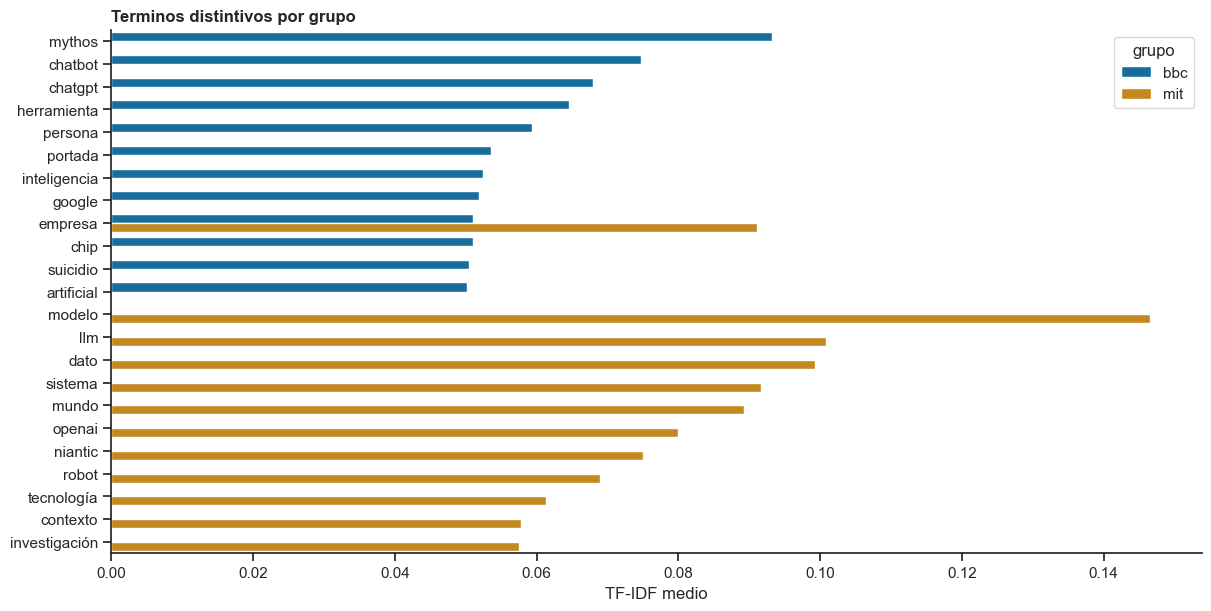

In [80]:
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

sns.barplot(
    data=top_tfidf,
    x="tfidf_medio",
    y="termino",
    hue="grupo",
    ax=ax,
)

ax.set_title("Terminos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("TF-IDF medio")
ax.set_ylabel("")

sns.despine(ax=ax)
plt.show()

Se comparan los términos más relevantes por grupo utilizando dos enfoques: frecuencia media (BoW) y peso distintivo TF-IDF.

En BoW se observan las palabras que más se repiten, como “chatbot”, “chatgpt” o “google” en BBC, y “modelo”, “dato” y “sistema” en MIT. Esto muestra qué términos son más comunes en cada grupo.

En cambio, TF-IDF resalta términos más específicos y distintivos. Por ejemplo, en BBC aparecen palabras como “mythos” o “viktoria”, que no son tan frecuentes pero sí más representativas de ciertos documentos. En MIT se mantienen términos técnicos como “modelo”, “dato” y “llm”, pero con un peso que refleja mejor su importancia relativa.

BoW permite ver qué palabras se repiten más, mientras que TF-IDF ayuda a identificar cuáles son más distintivas para diferenciar los contenidos. Esto permite complementar el análisis, combinando frecuencia y aporte dintintivo para entender mejor el contenido de cada grupo.

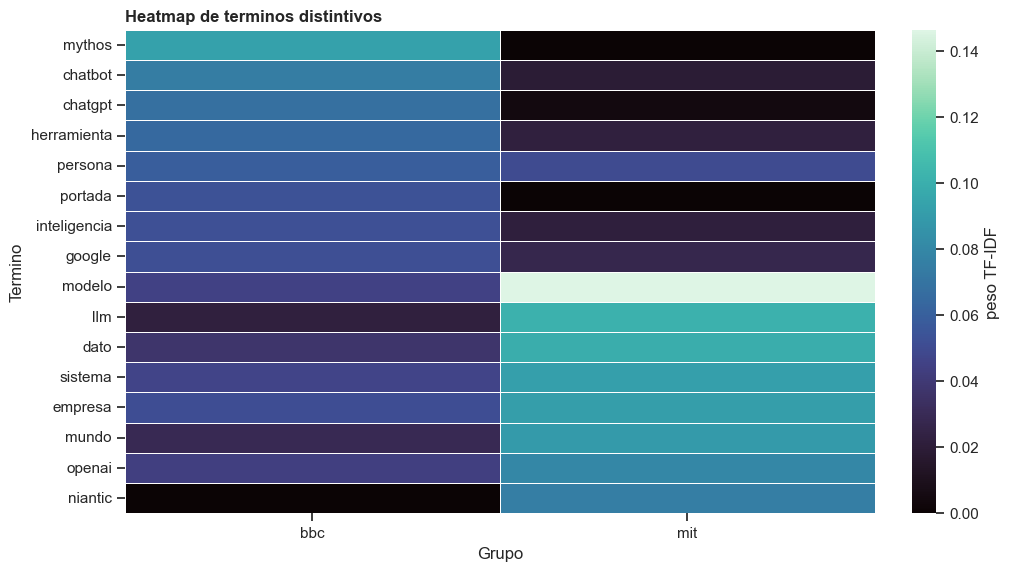

In [81]:
# Elegimos los primeros 8 terminos distintivos de cada grupo.
agrupado_top_tfidf = top_tfidf.groupby("grupo")
# 'head(8)' conserva los primeros 8 terminos de cada grupo.
top_ocho = agrupado_top_tfidf.head(8)
lista_terminos = top_ocho["termino"].tolist()

terminos_heatmap = []
for termino in lista_terminos:
    if termino not in terminos_heatmap:
        terminos_heatmap.append(termino)

# Volvemos a usar '.T' para que los terminos queden en el eje vertical.
matriz_heatmap = tabla_tfidf_grupos[terminos_heatmap].T

fig, ax = plt.subplots(figsize=(10, max(4, len(terminos_heatmap) * 0.35)), constrained_layout=True)

sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)

ax.set_title("Heatmap de terminos distintivos", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Termino")

plt.show()

In [82]:
## Análisis comparativo de Representaciones Sparse

# 1. Obtener los 15 términos principales por método y por grupo
top_n = 15

# Agregamos las puntuaciones para BoW (Suma de conteos)
bow_stats = df_frecuencias.groupby(COLUMNA_GRUPO).sum().T

# Agregamos las puntuaciones para TF-IDF (Promedio de importancia)
tfidf_stats = df_especificidad.groupby(COLUMNA_GRUPO).mean().T

# 2. Función para mostrar comparativa rápida
for grupo in df[COLUMNA_GRUPO].unique():
    print(f"\n--- ANÁLISIS DEL GRUPO: {grupo.upper()} ---")
    
    # Términos más frecuentes
    frecuentes = bow_stats[grupo].sort_values(ascending=False).head(top_n)
    
    # Términos más distintivos
    distintivos = tfidf_stats[grupo].sort_values(ascending=False).head(top_n)
    
    # Creamos un pequeño reporte de comparación
    comparativa = pd.DataFrame({
        "Top Frecuencia (BoW)": frecuentes.index,
        "Frec.": frecuentes.values.astype(int),
        "Top Distintividad (TF-IDF)": distintivos.index,
        "Peso": distintivos.values.round(4)
    })
    display(comparativa)


--- ANÁLISIS DEL GRUPO: MIT ---


,Top Frecuencia (BoW),Frec.,Top Distintividad (TF-IDF),Peso
0,modelo,74,modelo,0.1098
1,dato,59,dato,0.0786
2,sistema,57,llm,0.0758
3,mundo,57,sistema,0.0723
4,empresa,55,empresa,0.0706
5,llm,38,mundo,0.0694
6,openai,36,openai,0.0614
7,tecnologia,31,niantic,0.0604
8,problema,28,robot,0.0539
9,utilizar,28,contexto,0.0469



--- ANÁLISIS DEL GRUPO: BBC ---


,Top Frecuencia (BoW),Frec.,Top Distintividad (TF-IDF),Peso
0,chatbot,29,mythos,0.0731
1,chatgpt,28,chatbot,0.0581
2,google,26,chatgpt,0.0534
3,empresa,26,herramienta,0.0504
4,inteligencia,24,persona,0.0440
5,persona,23,suicidio,0.0400
6,sistema,21,google,0.0396
7,utilizar,21,chip,0.0393
8,artificial,21,inteligencia,0.0392
9,herramienta,20,empresa,0.0389


Agreguen una celda Markdown nueva y comparen:

- que aparece como frecuente en ambos grupos;
- que aparece como distintivo en `TF-IDF`;
- que cambia entre volumen y especificidad.

### Representaciones sparse: frecuencia, TF-IDF y especificidad

La diferencia entre volumen y especificidad es que el volumen (Bag of Words) mide cuántas veces aparece una palabra, mientras que la especificidad (TF-IDF) mide qué tan distintiva es esa palabra dentro de un grupo.

Cuando hablamos de TF-IDF, lo importante no es solo cuántas veces aparece una palabra, sino también en cuántos textos aparece de manera exclusiva o diferenciada. O sea, no alcanza con que una palabra sea muy repetida, sino que también tiene que ser más “única” dentro de un grupo.

Por ejemplo, en BBC aparece la palabra “mythos” como un término bastante distintivo. No es de las más frecuentes en general, pero aparece en pocos textos y de forma más concentrada, por eso el modelo la marca como representativa.

En cambio, palabras como “modelo” o “dato” aparecen muchas veces, pero están en muchos textos de ambos grupos. Entonces, aunque son frecuentes (como muestra Bag of Words), no sirven tanto para diferenciar, por eso en TF-IDF pierden importancia.

Otro caso es “llm” en MIT. No es la palabra que más se repite, pero sí es muy característica del tipo de contenido técnico de ese grupo, por eso TF-IDF la destaca más.

Además, “llm” significa “Large Language Model”, o sea modelos de lenguaje grandes. Que aparezca en MIT tiene sentido porque ese grupo usa un vocabulario más técnico relacionado con inteligencia artificial.

En el Heatmap se evidencia que el medio BBC tiene una frecuencia de términos más homogénea, mientras que el medio BBC tiene un uso de vocabulario más específico, lo que es coherente con sus perfiles (generalista y técnico).

En resumen, el volumen muestra qué palabras se repiten más, mientras que la especificidad muestra cuáles son más propias de cada grupo y ayudan a diferenciarlos mejor

## 8. Del patrón al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complica.

En este paso se toman los términos más distintivos según TF-IDF y se buscan en los textos originales para ver cómo se usan en contexto. Esto permite validar el análisis previo y entender mejor el significado real de esos términos en cada grupo.

In [83]:
# Tomamos los 2 terminos mas distintivos de cada grupo.
agrupado_terminos = top_tfidf.groupby("grupo")
# 'head(2)' conserva los primeros 2 casos de cada grupo.
terminos_para_volver = agrupado_terminos.head(4)
# 'reset_index' recompone el indice para que la tabla quede limpia.
terminos_para_volver = terminos_para_volver.reset_index(drop=True)
display(terminos_para_volver)

,grupo,termino,tfidf_medio
0,bbc,mythos,0.0932
1,bbc,chatbot,0.0747
2,bbc,chatgpt,0.0680
3,bbc,herramienta,0.0645
4,mit,modelo,0.1465
5,mit,llm,0.1008
6,mit,dato,0.0992
7,mit,sistema,0.0917


In [84]:
def extraer_fragmentos(dataframe, grupo, termino, ventana=160, max_fragmentos=2):
    registros = []

    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto_original = getattr(fila, COLUMNA_TEXTO)
        doc = nlp_ajustado(texto_original)

        for token in doc:
            coincide_lema = lema_ajustado(token) == termino
            coincide_forma = token.text.lower() == termino

            if coincide_lema or coincide_forma:
                inicio = max(0, token.idx - ventana)
                fin = min(len(texto_original), token.idx + len(token.text) + ventana)

                fragmento = texto_original[inicio:fin].strip()

                if inicio > 0:
                    fragmento = "..." + fragmento

                if fin < len(texto_original):
                    fragmento = fragmento + "..."

                registros.append({
                    "grupo": grupo,
                    "termino": termino,
                    "titulo": fila.titulo,
                    "fragmento": fragmento,
                })

                break

        if len(registros) >= max_fragmentos:
            break

    return registros

In [85]:
registros_fragmentos = []

for fila in terminos_para_volver.itertuples(index=False):
    grupo = fila.grupo
    termino = fila.termino

    fragmentos_grupo = extraer_fragmentos(
        df,
        grupo,
        termino,
        ventana=VENTANA_FRAGMENTO,
        max_fragmentos=2,
    )

    registros_fragmentos.extend(fragmentos_grupo)

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)

,grupo,termino,titulo,fragmento
0,bbc,mythos,"Mythos, el nuevo modelo de IA de Anthropic que preocupa a gobiernos y bancos por su gran potencia","...de la inteligencia artificial (IA) ha estado en ascuas tras las afirmaciones realizadas por la empresa líder Anthropic en relación con su nuevo modelo, C..."
1,bbc,chatbot,Por qué los chatbots de IA pueden estar volviéndote más tonto,...con su trabajo.\nLe resultó evidente que los candidatos estaban utilizando grandes modelos de lenguaje (LLM) -una forma de inteligencia artificial que im...
2,bbc,chatbot,"Quiénes son los ""arquitectos de la IA"", elegidos Persona del Año por la revista Time","...miento de ChatGPT por parte de OpenAI a finales de 2022, que continúa a un ritmo acelerado.\nEl director de la empresa, Sam Altman, declaró en septiembre..."
3,bbc,chatgpt,Por qué los chatbots de IA pueden estar volviéndote más tonto,....\nLe resultó evidente que los candidatos estaban utilizando grandes modelos de lenguaje (LLM) -una forma de inteligencia artificial que impulsa a chatbo...
4,bbc,chatgpt,"Mythos, el nuevo modelo de IA de Anthropic que preocupa a gobiernos y bancos por su gran potencia","...llado como parte de su sistema de IA más amplio llamado Claude. Este sistema engloba el asistente de IA de la compañía y su familia de modelos, compitien..."
5,bbc,herramienta,Por qué los chatbots de IA pueden estar volviéndote más tonto,...efecto corrosivo en nuestras capacidades mentales. Las consecuencias podrían ser alarmantes e incluso contribuir al deterioro cognitivo.\nEs bien sabido ...
6,bbc,herramienta,"Mythos, el nuevo modelo de IA de Anthropic que preocupa a gobiernos y bancos por su gran potencia","...as tras las afirmaciones realizadas por la empresa líder Anthropic en relación con su nuevo modelo, Claude Mythos.\nLa compañía asegura haber descubierto..."
7,mit,modelo,La IA necesita un sólido tejido de datos para aportar valor empresarial,"...a medida que la IA se integra en los flujos de trabajo centrales, los líderes empresariales están descubriendo que el mayor obstáculo no es el rendimient..."
8,mit,modelo,Por qué nuestra opinión sobre la IA está tan dividida,"...na fiebre del oro. La IA es una burbuja. La IA está quitando tu trabajo. La IA ni siquiera sabe leer un reloj."" (El informe de Stanford señala que el pri..."
9,mit,llm,Por qué nuestra opinión sobre la IA está tan dividida,"...icación o para otros trabajos técnicos están experimentando esta tecnología en su máximo esplendor. Fuera de esos casos de uso, la situación es más dispa..."


Agreguen una celda Markdown nueva y expliquen:

- como aparece en contexto al menos un termino distintivo de cada grupo;
- que cambia cuando vuelven al fragmento;
- que no habrian visto si se quedaban solo con las tablas.

En esta parte se muestran fragmentos reales de los textos donde aparecen los términos más distintivos de cada grupo. Esto permite pasar del análisis numérico (TF-IDF) a ver cómo se usan realmente esas palabras en contexto.

Por ejemplo, en BBC el término “chatbot” aparece en frases relacionadas con el uso cotidiano de la inteligencia artificial y su impacto en las personas. También “mythos” aparece en un contexto más informativo o periodístico. Este caso es interesante para analizar porque aunque pareciera un término sólo de interés técnico (es la última versión de Claude de Anthropic) el impacto social que tuvo el anuncio de su capacidad de detectar bugs de seguridad y el que no se abriera al público masivo inicialmente generó una gran inquietud social.

En cambio, en MIT términos como “modelo” y “dato” se usan en contextos más técnicos, hablando del funcionamiento de la IA, su rendimiento o su aplicación en empresas.

Al volver al fragmento, cambia la interpretación porque ya no vemos solo la palabra aislada, sino cómo se usa dentro de una idea completa. Esto ayuda a entender mejor el significado real y el enfoque del texto.

Además, hay cosas que no se podrían ver solo con las tablas, como el tono del texto, el contexto en el que aparece la palabra o el sentido específico que tiene en cada caso.

Esto confirma lo que se había visto antes con TF-IDF: que BBC tiene un enfoque más general o social, de interés público, mientras que MIT utiliza un lenguaje más técnico y está más orientado al contexto empresarial.

En resumen, estos fragmentos ayudan a validar que los términos identificados como importantes realmente representan el tipo de contenido de cada grupo.

## 9. Cierre metodológico

Agreguen una celda Markdown nueva y respondan, de forma breve:

1. Que hallazgo creen que si pueden defender con evidencia.
2. Que habria salido mal si confiaban ciegamente en la primera salida de la maquina.
3. Que no se puede afirmar solo con estas representaciones.

## 9. Cierre metodológico

**1. Hallazgo principal:**
Se observa una diferencia en cómo cada medio aborda la IA. En los textos del MIT aparece un vocabulario más técnico y corporativo, mientras que en la BBC aparece más vinculada a temáticas humanas. Esto se puede comprobar tanto con las frecuencias como con TF-IDF y los fragmentos de texto.

**2. Importancia del ajuste humano:**
Si se confiara ciegamente en la primera salida de la máquina, podrían aparecer errores en la interpretación, como considerar importantes palabras que en realidad son ruido (por ejemplo stopwords mal filtradas como “el”). También se podría asumir que las palabras más frecuentes son las más relevantes, cuando en realidad no siempre diferencian entre grupos.
Con la intervención sobre el corpus utilizando las diferentes técnicas pudimos filtrar ruido y encontrar términos más representativos de cada posición

**3. Limitaciones:**
No se puede afirmar una postura categórica de la línea editorial de cada medio usando sólo 12 textos, tal como se comentó al principio. Además, las diferencias encontradas tampoco son muy extremas en frecuencia y distintividad. 
Solo con estas representaciones no se puede afirmar completamente el significado o la intención de los textos. Por ejemplo, no se puede entender el tono, la opinión o el contexto completo solo con frecuencias o TF-IDF. Por eso es necesario complementar con la lectura de fragmentos reales.

## Rubrica

| Criterio | Peso |
|---|---:|
| Construccion y justificacion del corpus | 30% |
| Inspeccion y ajuste del pipeline con spaCy | 25% |
| Comparacion de stopwords y decisiones de preprocesamiento | 15% |
| Analisis comparativo con evidencia | 20% |
| Claridad, limites del metodo y reproducibilidad | 10% |

## Checklist final

- El corpus tiene 12 textos y 6 por grupo.
- La columna `grupo_comparacion` esta completa.
- Respondieron las preguntas metodologicas.
- Compararon stopwords de `spaCy` y `NLTK`.
- Hicieron al menos dos ajustes humanos del pipeline.
- Compararon `Bag of Words`, `TF-IDF` y bigramas.
- Incluyeron al menos dos visualizaciones analiticas legibles.
- Volvieron a fragmentos concretos del corpus.
- Cerraron con una conclusion interpretativa y metodologica.
- El notebook corre de principio a fin.